In [19]:
import sys
import math
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

possible_roots = [
    Path.cwd(),                                      # current folder
    Path.home() / "PycharmProjects" / "GOOD",       # your Mac
    Path.home() / "GOOD_MODEL",                     # supercomputer home
    Path("/ocean/projects/ele250005p/GOOD_MODEL"),  # PSC project folder
]

PROJECT_ROOT = next(
    (path for path in possible_roots if (path / "good").exists()),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError("GOOD project folder was not found.")

OUTPUT_ROOT = PROJECT_ROOT / "Output"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)

from good.Visualization.rps_cost_plot import *


PROJECT_ROOT: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL
OUTPUT_ROOT: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL/Output


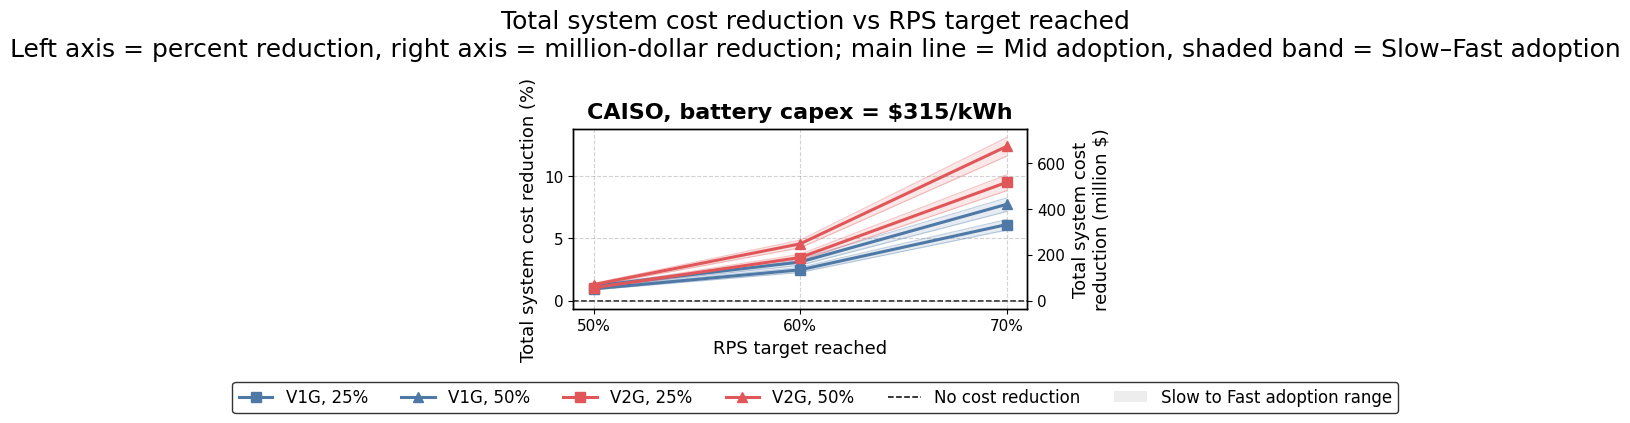

In [2]:
df_delta_all, fig, axes = (
    plot_total_cost_delta_vs_rps_regions_by_battery(
        output_root=OUTPUT_ROOT,
        regions=(
            "CAISO",
            # "ERCOT",
            # "FRCC",
            # "ISO-NE",
            # "MAPP",
            # "MISO",
            # "NWPP",
            # "NYISO",
            # "PJM",
            # "RMRG",
            # "SERC-E",
            # "SERC-N",
            # "SERC-SE",
            # "SPP",
            # "SRSG",
        ),
        year=2030,
        adoption_levels=(
            "slow",
            "mid",
            "fast",
        ),
        main_adoption_level="Mid",
        band_adoption_levels=(
            "Slow",
            "Fast",
        ),
        batt_order=(315,),
        # =================================================
        # Baseline charging scenario
        # =================================================
        baseline_scenario_label_by_region={
            "CAISO": "midnight",
            "ERCOT": "arrive",
            "FRCC": "arrive",
            "ISO-NE": "arrive",
            "MAPP": "arrive",
            "MISO": "arrive",
            "NWPP": "arrive",
            "NYISO": "delay",
            "PJM": "arrive",
            "RMRG": "arrive",
            "SERC-E": "arrive",
            "SERC-N": "arrive",
            "SERC-SE": "arrive",
            "SPP": "arrive",
            "SRSG": "arrive",
        },
        # =================================================
        # Program charging scenario
        # =================================================
        program_scenario_label_by_region = {
            "CAISO": "delay",
            "ERCOT": "midnight",
            "FRCC": "delay",
            "ISO-NE": "delay",
            "MAPP": "delay",
            "MISO": "delay",
            "NWPP": "delay",
            "NYISO": "delay",
            "PJM": "delay",
            "RMRG": "delay",
            "SERC-E": "delay",
            "SERC-N": "midnight",
            "SERC-SE": "midnight",
            "SPP": "midnight",
            "SRSG": "delay",
        },
        # =================================================
        # RPS order
        # =================================================
        rps_order_by_region={
            "CAISO": [50, 60, 70],
            "ERCOT": [0, 50, 60],
            "FRCC": [0, 50, 60],
            "NYISO": [60, 70, 80],
            "ISO-NE": [-10, 0, 10],
            "MAPP": [-10, 0, 10],
            "MISO": [-10, 0, 10],
            "NWPP": [-10, 0, 10],
            "PJM": [-10, 0, 10],
            "RMRG": [-10, 0, 10],
            "SERC-E": [-10, 0, 10],
            "SERC-N": [-10, 0, 10],
            "SERC-SE": [-10, 0, 10],
            "SPP": [-10, 0, 10],
            "SRSG": [-10, 0, 10],
        },
        selected_participation=(
            "25%",
            "50%",
        ),
        # =================================================
        # Panel titles
        # =================================================
        panel_title_by_region={
            "CAISO": "CAISO",
            "ERCOT": "ERCOT",
            "FRCC": "FRCC",
            "ISO-NE": "ISO-NE",
            "MAPP": "MAPP",
            "MISO": "MISO",
            "NWPP": "NWPP",
            "NYISO": "NYISO",
            "PJM": "PJM",
            "RMRG": "RMRG",
            "SERC-E": "SERC-E",
            "SERC-N": "SERC-N",
            "SERC-SE": "SERC-SE",
            "SPP": "SPP",
            "SRSG": "SRSG",
        },
        delta_metric="reduction_million",
        show_adoption_band=True,
        font_size=12,
        save_path=(
            PROJECT_ROOT
            / "figures"
            / (
                "cost_reduction_vs_rps_all_regions_"
                "bcapex315_adoption_band_6x3.png"
            )
        ),
    )
)
plt.show()
plt.close(fig)

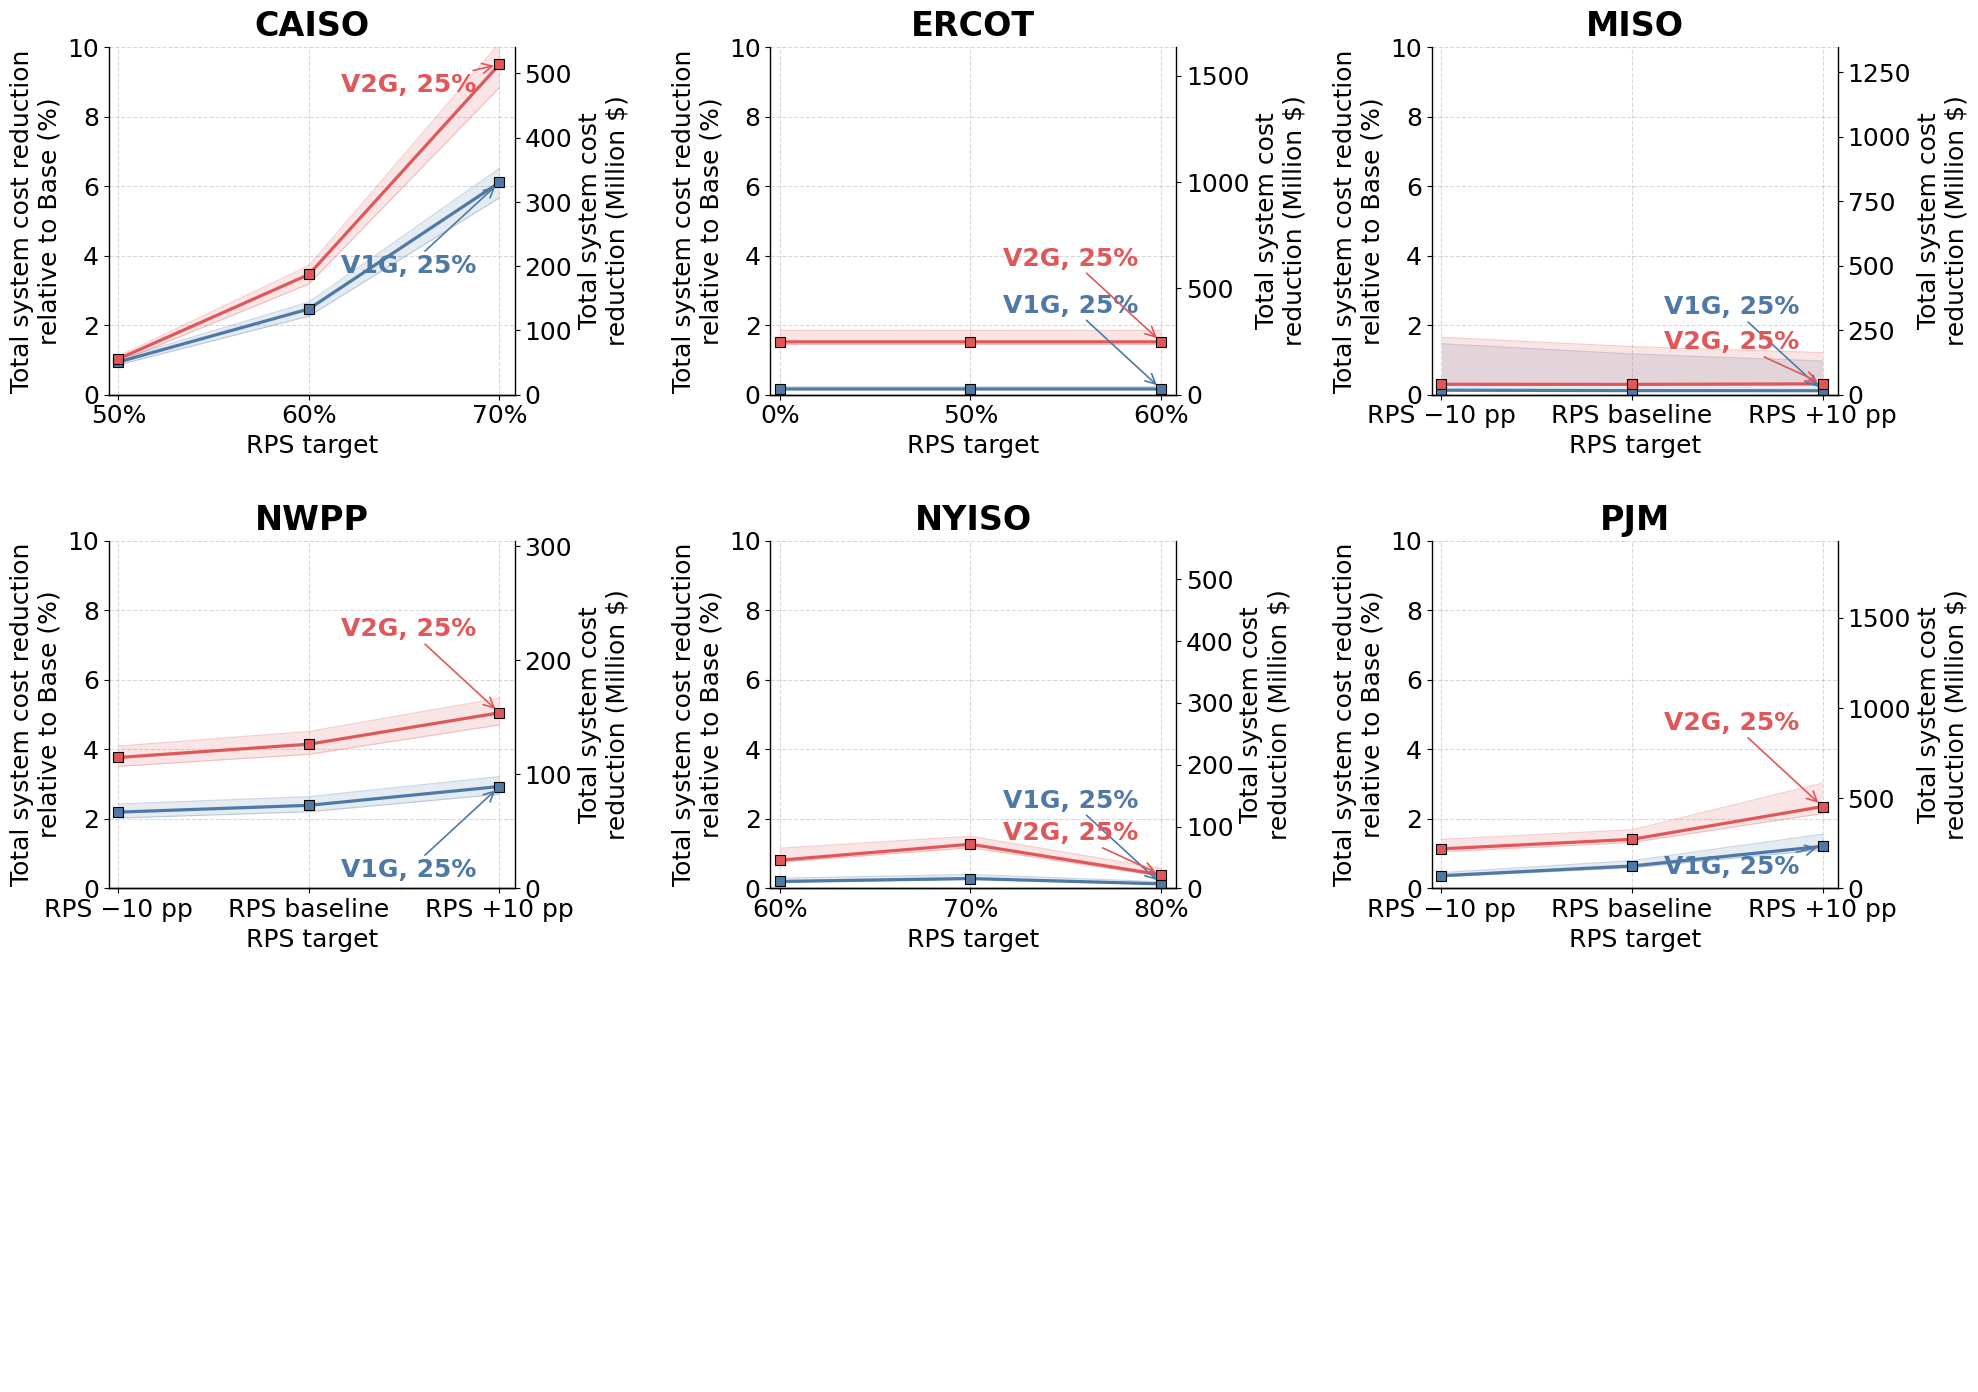

In [3]:
df_delta_dual, fig, axes = (
    plot_total_cost_delta_vs_rps_regions_2x3_dual_axis(
        output_root=OUTPUT_ROOT,
        regions=(
            "CAISO",
            "ERCOT",
             "MISO",
             "NWPP",
            # "FRCC",
            "NYISO",
            "PJM",
            # "MAPP"
            # "RMRG",
            # "SERC-E",
            # "SERC-N",
            # "SERC-SE",
            # "SPP",
            # "SRSG",
        ),
        year=2030,
        adoption_levels=(
            "slow",
            "mid",
            "fast",
        ),
        main_adoption_level="Mid",
        band_adoption_levels=(
            "Slow",
            "Fast",
        ),
        batt_order=(
            315,
        ),
        # =================================================
        # Baseline charging scenario
        # =================================================
        baseline_scenario_label_by_region={
            "CAISO": "midnight",
            "ERCOT": "arrive",
            "FRCC": "arrive",
            "ISO-NE": "arrive",
            "MAPP": "arrive",
            "MISO": "arrive",
            "NWPP": "arrive",
            "NYISO": "flex",
            "PJM": "arrive",
            "RMRG": "arrive",
            "SERC-E": "arrive",
            "SERC-N": "arrive",
            "SERC-SE": "arrive",
            "SPP": "arrive",
            "SRSG": "arrive",
        },
        # =================================================
        # Program charging scenario
        # =================================================
        program_scenario_label_by_region = {
            "CAISO": "delay",
            "ERCOT": "midnight",
            "FRCC": "delay",
            "ISO-NE": "delay",
            "MAPP": "delay",
            "MISO": "midnight",
            "NWPP": "delay",
            "NYISO": "flex",
            "PJM": "delay",
            "RMRG": "delay",
            "SERC-E": "delay",
            "SERC-N": "midnight",
            "SERC-SE": "midnight",
            "SPP": "midnight",
            "SRSG": "delay",
        },
        # =================================================
        # RPS order
        # =================================================
        rps_order_by_region={
            "CAISO": [50, 60, 70],
            "ERCOT": [0, 50, 60],
            "FRCC": [0, 50, 60],
            "ISO-NE": [-10, 0, 10],
            "MAPP": [-10, 0, 10],
            "MISO": [-10, 0, 10],
            "NWPP": [-10, 0, 10],
            "NYISO": [60, 70, 80],
            "PJM": [-10, 0, 10],
            "RMRG": [-10, 0, 10],
            "SERC-E": [-10, 0, 10],
            "SERC-N": [-10, 0, 10],
            "SERC-SE": [-10, 0, 10],
            "SPP": [-10, 0, 10],
            "SRSG": [-10, 0, 10],
        },
        selected_groups=(
            "V1G",
            "V2G",
        ),
        selected_participation=(
            "25%",
            # "50%",
        ),
        # =================================================
        # Panel titles
        # =================================================
        panel_title_by_region={
            "CAISO": "CAISO",
            "ERCOT": "ERCOT",
            "FRCC": "FRCC",
            "ISO-NE": "ISO-NE",
            "MAPP": "MAPP",
            "MISO": "MISO",
            "NWPP": "NWPP",
            "NYISO": "NYISO",
            "PJM": "PJM",
            "RMRG": "RMRG",
            "SERC-E": "SERC-E",
            "SERC-N": "SERC-N",
            "SERC-SE": "SERC-SE",
            "SPP": "SPP",
            "SRSG": "SRSG",
        },
        figure_title="",
        show_second_y_axis=True,
        show_adoption_band=True,
        show_endpoint_labels=True,
        same_y_scale=False,
        symmetric_y_axis=False,
        font_size=18,
        figure_title_fontsize=24,
        panel_title_fontsize=24,
        axis_label_fontsize=18,
        tick_label_fontsize=18,
        legend_fontsize=20,
        common_ymin_value=0,
        common_ymax_value=10,
        save_path=(
            PROJECT_ROOT
            / "figures"
            / (
                "cost_reduction_vs_rps_all_regions_"
                "bcapex315_dual_axis_5x3.png"
            )
        ),
    )
)

plt.show()
plt.close(fig)

In [67]:
# =========================================================
# R1: Value of 1 kWh of driver-provided EV flexibility vs RPS
# =========================================================
# Basic helpers
# =========================================================
REGION_ALIASES = {
    "CAISO": "CAISO",
    "CAISO": "CAISO",

    "NYISO": "NYISO",
    "NYISO": "NYISO",

    "ERCOT": "ERCOT",
    "ERCOT": "ERCOT",

    "FRCC": "FRCC",
    "FRCC": "FRCC",

    "PJM": "PJM",
}
REGION_DISPLAY_NAMES = {
    "CAISO": "CAISO",
    "NYISO": "NYISO",
    "ERCOT": "ERCOT",
    "FRCC": "FRCC",
    "PJM": "PJM",
}
GROUP_ORDER = ["Base only", "V1G", "V2G"]
GROUP_COLORS = {
    "Base only": "black",
    "V1G": "#4E79A7",   # blue
    "V2G": "#E15759",   # old V1G+V2G red
}
MARKER_MAP = {
    "0%": "o",
    "10%": "D",
    "25%": "s",
    "50%": "^",
}
EV_ADOPTION_BY_STATE = {

    "CA": {
        # 2025 registered EV stock, BEV + PHEV + FCEV
        # Auto Innovators Q4 2025 exact value
        (2025, "slow"): 2268646,
        (2025, "mid"): 2268646,
        (2025, "fast"): 2268646,

        (2030, "slow"): 5100000,
        (2030, "mid"): 6100000,
        (2030, "fast"): 7200000,

        (2035, "slow"): 11900000,
        (2035, "mid"): 12600000,
        (2035, "fast"): 14200000,
    },

    "TX": {
        # 2025 registered EV stock, estimated from Auto Innovators Q4 2025 state share
        (2025, "slow"): 466000,
        (2025, "mid"): 466000,
        (2025, "fast"): 466000,

        (2030, "slow"): 1500000,
        (2030, "mid"): 2200000,
        (2030, "fast"): 3500000,

        (2035, "slow"): 4500000,
        (2035, "mid"): 7200000,
        (2035, "fast"): 10400000,
    },

    "NY": {
        # 2025 registered EV stock, estimated from Auto Innovators Q4 2025 state share
        (2025, "slow"): 324000,
        (2025, "mid"): 324000,
        (2025, "fast"): 324000,

        (2030, "slow"): 1590000,
        (2030, "mid"): 2300000,
        (2030, "fast"): 3100000,

        (2035, "slow"): 4000000,
        (2035, "mid"): 6100000,
        (2035, "fast"): 9200000,
    },

    "FL": {
        # 2025 registered EV stock, estimated from Auto Innovators Q4 2025 state share
        (2025, "slow"): 530000,
        (2025, "mid"): 530000,
        (2025, "fast"): 530000,

        (2030, "slow"): 1800000,
        (2030, "mid"): 2700000,
        (2030, "fast"): 4000000,

        (2035, "slow"): 5000000,
        (2035, "mid"): 7800000,
        (2035, "fast"): 11000000,
    },

    "DE": {
        # 2025 registered EV stock, estimated from Auto Innovators Q4 2025 state share
        (2025, "slow"): 22000,
        (2025, "mid"): 22000,
        (2025, "fast"): 22000,

        (2030, "slow"): 150000,
        (2030, "mid"): 205000,
        (2030, "fast"): 250000,

        (2035, "slow"): 260000,
        (2035, "mid"): 340000,
        (2035, "fast"): 430000,
    },

    "DC": {
        # 2025 registered EV stock, BEV + PHEV + FCEV
        # Auto Innovators Q4 2025 exact value
        (2025, "slow"): 17134,
        (2025, "mid"): 17134,
        (2025, "fast"): 17134,

        (2030, "slow"): 70000,
        (2030, "mid"): 90000,
        (2030, "fast"): 110000,

        (2035, "slow"): 110000,
        (2035, "mid"): 150000,
        (2035, "fast"): 190000,
    },

    "IL": {
        # 2025 registered EV stock, estimated from Auto Innovators Q4 2025 state share
        (2025, "slow"): 212000,
        (2025, "mid"): 212000,
        (2025, "fast"): 212000,

        (2030, "slow"): 750000,
        (2030, "mid"): 1000000,
        (2030, "fast"): 1250000,

        (2035, "slow"): 1600000,
        (2035, "mid"): 2300000,
        (2035, "fast"): 3200000,
    },

    "IN": {
        # 2025 registered EV stock, estimated from Auto Innovators Q4 2025 state share
        (2025, "slow"): 64000,
        (2025, "mid"): 64000,
        (2025, "fast"): 64000,

        (2030, "slow"): 350000,
        (2030, "mid"): 577000,
        (2030, "fast"): 750000,

        (2035, "slow"): 700000,
        (2035, "mid"): 1155000,
        (2035, "fast"): 1500000,
    },

    "KY": {
        # 2025 registered EV stock, estimated from Auto Innovators Q4 2025 state share
        (2025, "slow"): 28000,
        (2025, "mid"): 28000,
        (2025, "fast"): 28000,

        (2030, "slow"): 235000,
        (2030, "mid"): 390000,
        (2030, "fast"): 500000,

        (2035, "slow"): 470000,
        (2035, "mid"): 780000,
        (2035, "fast"): 1050000,
    },

    "MD": {
        # 2025 registered EV stock, estimated from Auto Innovators Q4 2025 state share
        (2025, "slow"): 159000,
        (2025, "mid"): 159000,
        (2025, "fast"): 159000,

        (2030, "slow"): 850000,
        (2030, "mid"): 1100000,
        (2030, "fast"): 1300000,

        (2035, "slow"): 1600000,
        (2035, "mid"): 2200000,
        (2035, "fast"): 2800000,
    },

    "MI": {
        # 2025 registered EV stock, estimated from Auto Innovators Q4 2025 state share
        (2025, "slow"): 138000,
        (2025, "mid"): 138000,
        (2025, "fast"): 138000,

        (2030, "slow"): 1200000,
        (2030, "mid"): 2000000,
        (2030, "fast"): 2400000,

        (2035, "slow"): 2000000,
        (2035, "mid"): 3000000,
        (2035, "fast"): 4000000,
    },

    "NJ": {
        # 2025 registered EV stock, BEV + PHEV + FCEV
        # Auto Innovators Q4 2025 exact top-10 value
        (2025, "slow"): 260872,
        (2025, "mid"): 260872,
        (2025, "fast"): 260872,

        (2030, "slow"): 782536,
        (2030, "mid"): 894000,
        (2030, "fast"): 1004573,

        (2035, "slow"): 1425514,
        (2035, "mid"): 2000000,
        (2035, "fast"): 2373196,
    },

    "NC": {
        # 2025 registered EV stock, estimated from Auto Innovators Q4 2025 state share
        (2025, "slow"): 156000,
        (2025, "mid"): 156000,
        (2025, "fast"): 156000,

        (2030, "slow"): 800000,
        (2030, "mid"): 1250000,
        (2030, "fast"): 1500000,

        (2035, "slow"): 1600000,
        (2035, "mid"): 2300000,
        (2035, "fast"): 3000000,
    },

    "OH": {
        # 2025 registered EV stock, estimated from Auto Innovators Q4 2025 state share
        (2025, "slow"): 129000,
        (2025, "mid"): 129000,
        (2025, "fast"): 129000,

        (2030, "slow"): 873000,
        (2030, "mid"): 1309000,
        (2030, "fast"): 1855000,

        (2035, "slow"): 1745000,
        (2035, "mid"): 2836000,
        (2035, "fast"): 3709000,
    },

    "PA": {
        # 2025 registered EV stock, estimated from Auto Innovators Q4 2025 state share
        (2025, "slow"): 172000,
        (2025, "mid"): 172000,
        (2025, "fast"): 172000,

        # NOTE: your original PA values have slow > mid.
        # That will make a negative lower error bar unless you fix it.
        (2030, "slow"): 1078000,
        (2030, "mid"): 1053000,
        (2030, "fast"): 1155000,

        (2035, "slow"): 2386000,
        (2035, "mid"): 2270000,
        (2035, "fast"): 2760000,
    },

    "TN": {
        # 2025 registered EV stock, estimated from Auto Innovators Q4 2025 state share
        (2025, "slow"): 73000,
        (2025, "mid"): 73000,
        (2025, "fast"): 73000,

        (2030, "slow"): 250000,
        (2030, "mid"): 350000,
        (2030, "fast"): 500000,

        (2035, "slow"): 500000,
        (2035, "mid"): 750000,
        (2035, "fast"): 1000000,
    },

    "VA": {
        # 2025 registered EV stock, estimated from Auto Innovators Q4 2025 state share
        (2025, "slow"): 163000,
        (2025, "mid"): 163000,
        (2025, "fast"): 163000,

        (2030, "slow"): 900000,
        (2030, "mid"): 1300000,
        (2030, "fast"): 1800000,

        (2035, "slow"): 1600000,
        (2035, "mid"): 2400000,
        (2035, "fast"): 3100000,
    },

    "WV": {
        # 2025 registered EV stock, estimated from Auto Innovators Q4 2025 state share
        (2025, "slow"): 7000,
        (2025, "mid"): 7000,
        (2025, "fast"): 7000,

        (2030, "slow"): 40000,
        (2030, "mid"): 70000,
        (2030, "fast"): 120000,

        (2035, "slow"): 120000,
        (2035, "mid"): 200000,
        (2035, "fast"): 350000,
    },
}
# =========================================================
# Build region-level EV adoption dataframe from state inputs
# =========================================================
GOOD_REGION_STATE_MAP = {
    "CAISO": ["CA"],
    "ERCOT": ["TX"],
    "NYISO": ["NY"],
    "FRCC": ["FL"],

    # For now, this sums the PJM-related states.
    # Later, if you want a more precise PJM value, replace this with
    # state-to-IPM weighted allocation for partial states like NC and VA.
    "PJM": [
        "DE",
        "DC",
        "IL",
        "IN",
        "KY",
        "MD",
        "MI",
        "NJ",
        "NC",
        "OH",
        "PA",
        "TN",
        "VA",
        "WV",
    ],
}
# =========================================================
# Weighted region-level EV adoption for R1 denominator
# =========================================================
# Use your real project path if this is not in /mnt/data.
STATE_IPM_WEIGHT_FILE = PROJECT_ROOT / "Examples" / "state_ipm_vehicle_weights.csv"
MODEL_REGION_IPM_NODES = {
    "CAISO": [
        "WEC_BANC",
        "WEC_CALN",
        "WEC_LADW",
        "WEC_SDGE",
        "WECC_IID",
        "WECC_SCE",
    ],

    "NYISO": [
        "NY_Z_A",
        "NY_Z_B",
        "NY_Z_D",
        "NY_Z_F",
        "NY_Z_J",
        "NY_Z_K",
        "NY_Z_C&E",
        "NY_Z_G-I",
    ],

    "ERCOT": [
        "ERC_REST",
        "ERC_WEST",
        "ERC_PHDL",
    ],

    "FRCC": [
        "FRCC",
    ],

    "PJM": [
        "PJM_AP",
        "PJM_ATSI",
        "PJM_COMD",
        "PJM_Dom",
        "PJM_EMAC",
        "PJM_PENE",
        "PJM_SMAC",
        "PJM_WMAC",
        "PJM_West",
    ],
}
RPS_ORDER_BY_REGION = {
    "CAISO": [50, 60, 70],
    "NYISO": [60, 70, 80],
    "ERCOT": [0, 50, 60],
    "FRCC": [0, 50, 60],
    "PJM": [-10, 0, 10],
}
BASELINE_SCENARIO_LABEL_BY_REGION = {
    "CAISO": "midnight",
    "NYISO": "midnight",
    "ERCOT": "arrive",
    "FRCC": "arrive",
    "PJM": "arrive",
}
PROGRAM_SCENARIO_LABEL_BY_REGION = {
    "CAISO": "delay",
    "NYISO": "delay",
    "ERCOT": "midnight",
    "FRCC": "delay",
    "PJM": "delay",
}
BAND_PROGRAM_SCENARIO_LABELS_BY_REGION = {
    "CAISO": [
        "arrive",
        "midnight",
        "flex",
        "delay",
    ],

    "NYISO": [
        "arrive",
        "midnight",
        "flex",
        "delay",
    ],

    "ERCOT": [
        "arrive",
        "midnight",
        "flex",
        "delay",
    ],

    "FRCC": [
        "arrive",
        "midnight",
        "flex",
        "delay",
    ],

    "PJM": [
        "arrive",
        "midnight",
        "flex",
        "delay",
    ],
}


In [68]:
ev_adoption_df, ev_adoption_detail_df = build_weighted_ev_adoption_df_from_state_dict(
    ev_adoption_by_state=EV_ADOPTION_BY_STATE,
    state_ipm_weight_file=STATE_IPM_WEIGHT_FILE,
    model_region_ipm_nodes=MODEL_REGION_IPM_NODES,
    years=(2025,2030, 2035),
    adoption_levels=("slow", "mid", "fast"),
)


Main scenario changes across RPS:
region group participation  rps rps_display_label program_scenario_label  value_per_available_kwh_year
  FRCC   V1G           25%    0                0%               midnight                      0.010272
  FRCC   V1G           25%   50               50%                  delay                      2.220049
  FRCC   V1G           25%   60               60%                  delay                      2.594571
  FRCC   V1G           50%    0                0%               midnight                      0.009772
  FRCC   V1G           50%   50               50%                  delay                      1.359021
  FRCC   V1G           50%   60               60%                  delay                      1.594708
  FRCC   V2G           25%    0                0%               midnight                      0.020545
  FRCC   V2G           25%   50               50%                  delay                      4.754348
  FRCC   V2G           25%   60       

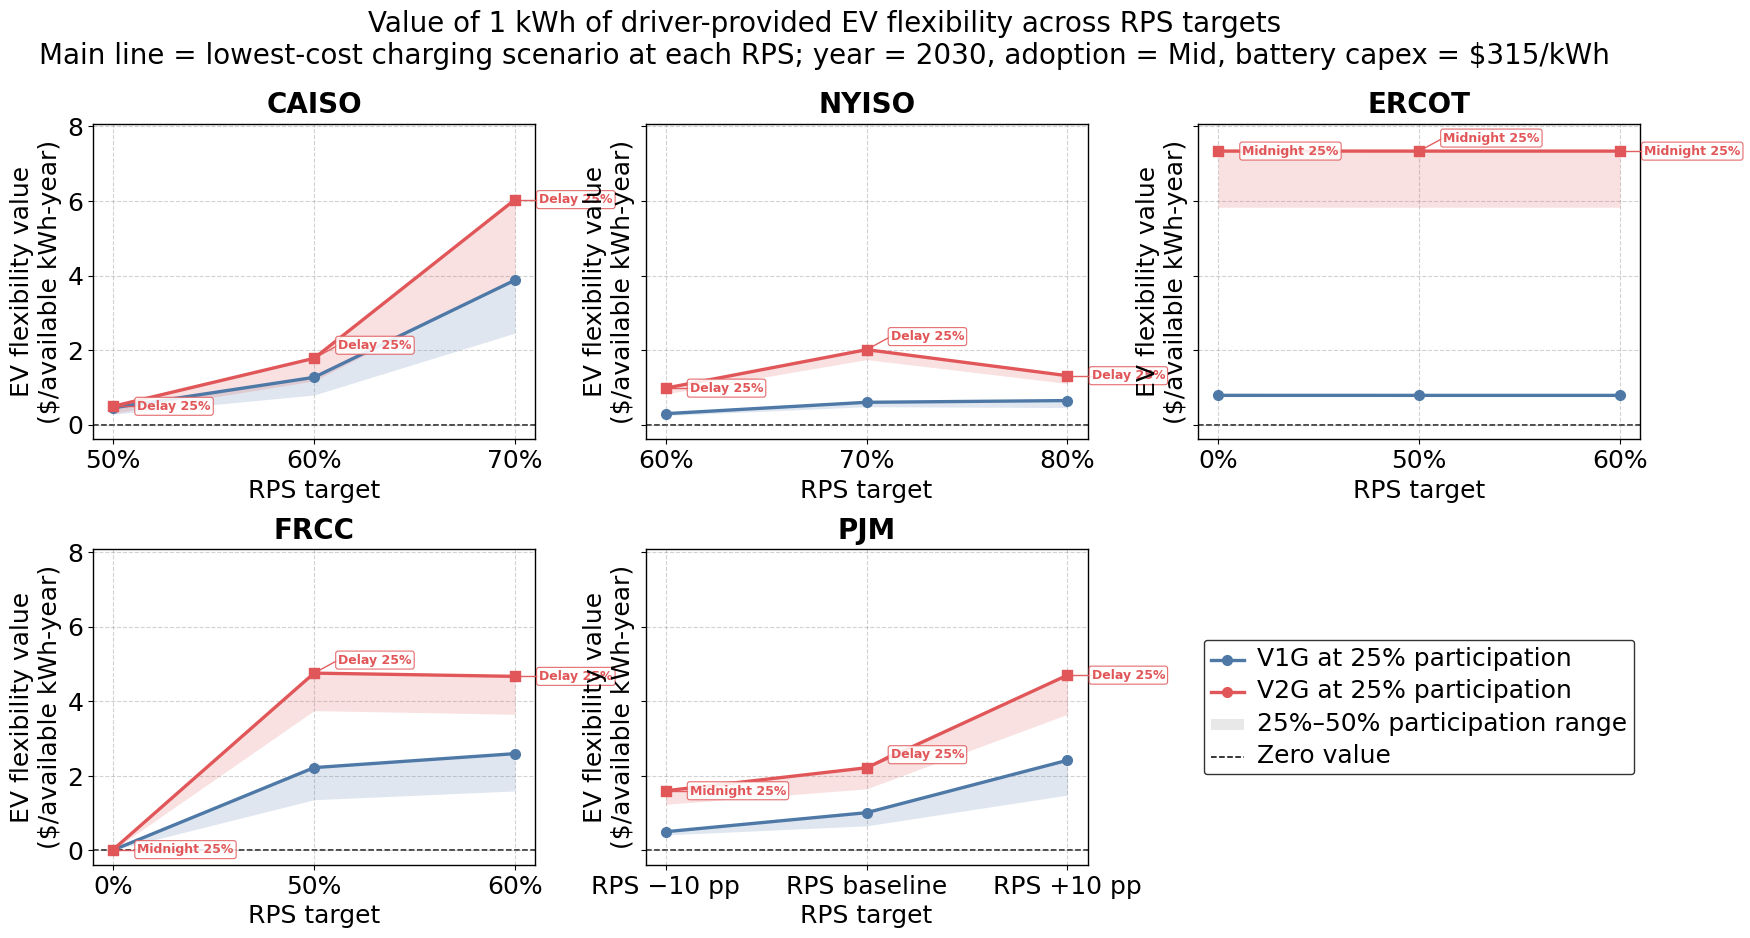

In [69]:
output_path = (
           PROJECT_ROOT
        / "figures"
    / "r1_value_per_kwh_best_charging_scenario.png"
)

r1_main_df, r1_band_df, r1_all_scenarios_df, fig, axes = (
    plot_r1_value_vs_rps_from_outputs_with_program_band(
        output_root=OUTPUT_ROOT,
        regions=(
            "CAISO",
            "NYISO",
            "ERCOT",
            "FRCC",
            "PJM",
        ),
        year=2030,
        adoption_level="mid",
        batt_capex=315,

        # Fixed regional reference charging scenario
        baseline_scenario_label_by_region=(
            BASELINE_SCENARIO_LABEL_BY_REGION
        ),

        # Still required by the existing function, but the main line
        # is replaced by the best scenario under upper_band mode.
        main_program_scenario_label_by_region=(
            PROGRAM_SCENARIO_LABEL_BY_REGION
        ),

        # These are now the candidate charging scenarios
        # from which the best one is selected.
        band_program_scenario_labels_by_region=(
            BAND_PROGRAM_SCENARIO_LABELS_BY_REGION
        ),

        ev_adoption_df=ev_adoption_df,
        rps_order_by_region=RPS_ORDER_BY_REGION,

        selected_groups=("V1G", "V2G"),
        selected_participation=("25%", "50%"),

        usable_battery_kwh=70.0,
        availability_fraction=1,

        model_days_per_run=360,
        annualize_model_period=True,

        sharey=True,

        # Select the best charging scenario at every RPS
        main_program_mode="upper_band",

        # New option that must be added to the function
        
        show_participation_band=True,
        base_participation="25%",
        upper_participation="50%",
        font_size=18,
        figure_title_fontsize=20,
        panel_title_fontsize=20,
        axis_label_fontsize=18,
        tick_label_fontsize=18,
        legend_fontsize=18,
        legend_title_fontsize=24,

        # Label the scenario selected for the main V2G 25% line
        show_main_scenario_change_labels=True,
        scenario_change_label_group="V2G",
        scenario_change_label_participation="25%",

        scenario_change_label_regions=(
            "CAISO",
            "NYISO",
            "ERCOT",
            "FRCC",
            "PJM",
        ),

        scenario_change_label_rps_by_region={
            "CAISO": [50, 60, 70],
            "NYISO": [60, 70, 80],
            "ERCOT": [0, 50, 60],
            "FRCC": [0, 50, 60],
            "PJM": [-10, 0, 10],
        },

        scenario_change_label_show_tag=False,
        scenario_change_label_fontsize=9.0,
        scenario_change_label_x_offset=0.12,

        figure_title=(
            "Value of 1 kWh of driver-provided EV flexibility "
            "across RPS targets\n"
            "Main line = lowest-cost charging scenario at each RPS; "
            "year = 2030, adoption = Mid, "
            "battery capex = $315/kWh"
        ),

        save_path=output_path,
    )
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

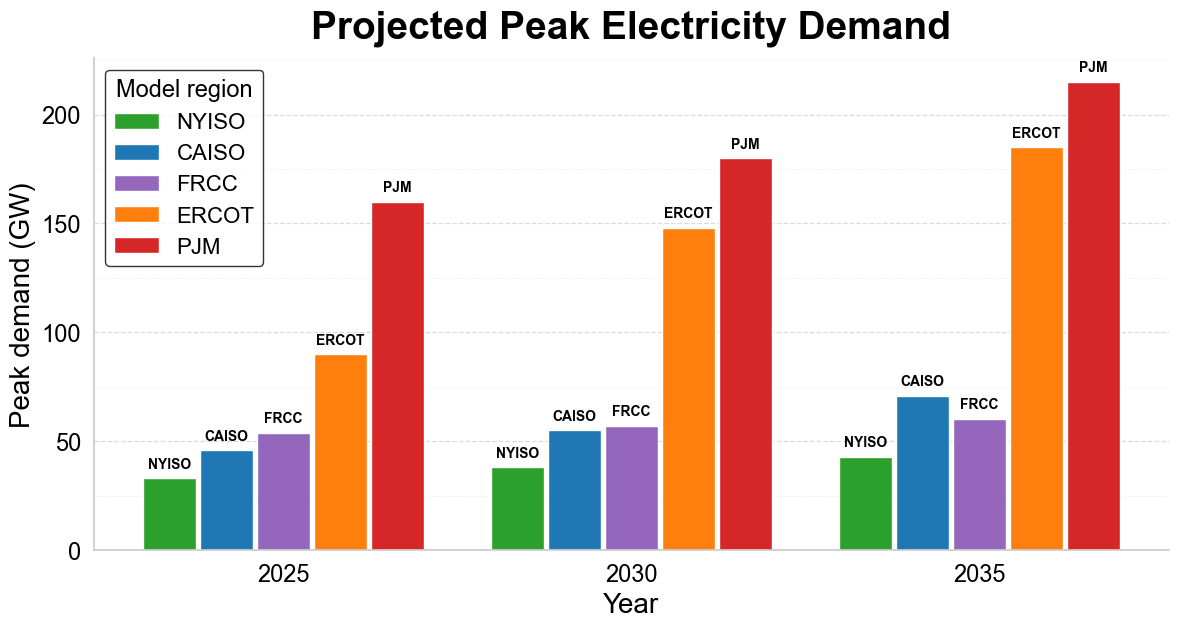

In [7]:
# =========================================================
# Peak demand assumptions
# Unit: GW
# =========================================================
demand = {
    "CA": {
        2025: 46,
        2030: 55,
        2035: 71,
    },

    "TX": {
        2025: 90,
        2030: 148,
        2035: 185,
    },

    "NY": {
        2025: 33,
        2030: 38,
        2035: 43,
    },

    # Replace these with your final Florida / FRCC peak demand values.

    "FL": {
         2025: 53.9,
        2030: 57.1,
        2035: 60.3,
    },


    # Replace these with your final PJM peak demand values.
    "PJM": {
         2025: 160,
        2030: 180,
        2035: 215,
    },
}
peak_demand_df = plot_peak_demand_bar_clean(
    demand,
    save_path="peak_demand_bar_model_regions.png",
    title="Projected Peak Electricity Demand",
    figsize=(12, 6.5),
    title_fontsize=28,
    axis_label_fontsize=20,
    tick_fontsize=17,
    legend_fontsize=16,
    legend_title_fontsize=17,
    show_bar_labels=True,
)

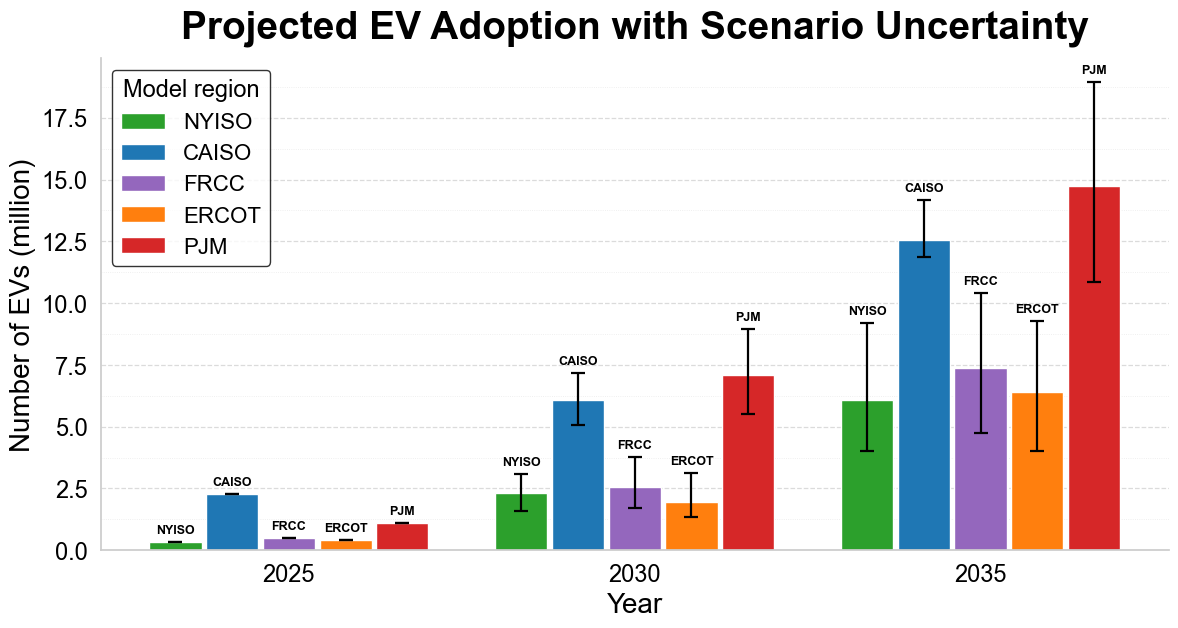

In [8]:
# =========================================================
# Plot EV adoption uncertainty by model region
# Uses weighted regional EV adoption from ev_adoption_df
# =========================================================

operator_label_map = {
    "CA": "CAISO",
    "TX": "ERCOT",
    "NY": "NYISO",
    "FL": "FRCC",
    "PJM": "PJM",
}




ev_adoption_plot_df = plot_ev_adoption_bar_clean(
    ev_adoption_df=ev_adoption_df,
    save_path="ev_adoption_bar_model_regions.png",
    title="Projected EV Adoption with Scenario Uncertainty",
    title_fontsize=28,
    axis_label_fontsize=20,
    tick_fontsize=17,
    legend_fontsize=16,
    legend_title_fontsize=17,
    show_bar_labels=True,
)

In [11]:
"""Map the least-cost charging strategy for GOOD/IPM model regions.

This file is designed to be placed in rps_cost_plot.py after the existing
``normalize_region`` and ``load_region_total_costs`` helpers.
"""


IPM_NODES_BY_MODEL_REGION = {
    "CAISO": [
        "WEC_CALN",
        "WEC_LADW",
        "WEC_SDGE",
        "WECC_SCE",
    ],
    "ERCOT": [
        "ERC_PHDL",
        "ERC_REST",
        "ERC_WEST",
    ],
    "FRCC": [
        "FRCC",
    ],
    "ISO-NE": [
        "NENG_CT",
        "NENGREST",
        "NENG_ME",
    ],
    "MAPP": [
        "MIS_MAPP",
    ],
    "MISO": [
        "MIS_IL",
        "MIS_INKY",
        "MIS_IA",
        "MIS_MIDA",
        "MIS_LMI",
        "MIS_MO",
        "MIS_WUMS",
        "MIS_MNWI",
        "MIS_WOTA",
        "MIS_AMSO",
        "MIS_AR",
        "MIS_MS",
        "MIS_LA",
    ],
    "NWPP": [
        "WECC_MT",
        "WEC_BANC",
        "WECC_ID",
        "WECC_NNV",
        "WECC_SNV",
        "WECC_UT",
        "WECC_PNW",
    ],
    "NYISO": [
        "NY_Z_A",
        "NY_Z_B",
        "NY_Z_C&E",
        "NY_Z_D",
        "NY_Z_F",
        "NY_Z_G-I",
        "NY_Z_J",
        "NY_Z_K",
    ],
    "PJM": [
        "PJM_AP",
        "PJM_ATSI",
        "PJM_COMD",
        "PJM_Dom",
        "PJM_EMAC",
        "PJM_PENE",
        "PJM_SMAC",
        "PJM_WMAC",
        "PJM_West",
    ],
    "RMRG": [
        "WECC_CO",
        "WECC_WY",
    ],
    "SERC-E": [
        "S_VACA",
    ],
    "SERC-N": [
        "S_C_KY",
        "S_D_AECI",
        "S_C_TVA",
    ],
    "SERC-SE": [
        "S_SOU",
    ],
    "SPP": [
        "SPP_NEBR",
        "SPP_N",
        "SPP_WEST",
        "SPP_SPS",
        "SPP_WAUE",
    ],
    "SRSG": [
        "WECC_AZ",
        "WECC_NM",
        "WECC_IID",
    ],
}


DEFAULT_BASE_RPS_BY_REGION = {
    "CAISO": 60,
    "ERCOT": 50,
    "FRCC": 50,
    "NYISO": 70,
    "ISO-NE": 0,
    "MAPP": 0,
    "MISO": 0,
    "NWPP": 0,
    "PJM": 0,
    "RMRG": 0,
    "SERC-E": 0,
    "SERC-N": 0,
    "SERC-SE": 0,
    "SPP": 0,
    "SRSG": 0,
}


DEFAULT_CHARGING_SCENARIO_COLORS = {
    "arrive": "#4E79A7",
    "delay": "#F28E2B",
    "flex": "#59A14F",
    "midnight": "#B07AA1",
}


DEFAULT_CHARGING_SCENARIO_NAMES = {
    "arrive": "Arrival",
    "delay": "Delay",
    "flex": "Flex",
    "midnight": "Midnight",
}


DEFAULT_IPM_SHAPEFILE_NODE_ALIASES = {
    "MIS_MS": "MIS_D_MS",
}


def find_ipm_shapefile(shp_folder):
    """Return a shapefile from either a .shp path or a folder."""

    from pathlib import Path

    shp_folder = Path(shp_folder)

    if shp_folder.is_file() and shp_folder.suffix.lower() == ".shp":
        return shp_folder

    if not shp_folder.exists():
        raise FileNotFoundError(
            f"IPM shapefile path does not exist: {shp_folder}"
        )

    shp_files = sorted(shp_folder.glob("*.shp"))

    if not shp_files:
        raise FileNotFoundError(
            f"No .shp file was found in: {shp_folder}"
        )

    return shp_files[0]


def _normalize_map_region_dictionary(input_map, regions, map_name):
    """Normalize a region-keyed mapping with the project's normalizer."""

    if input_map is None:
        raise ValueError(f"{map_name} cannot be None.")

    normalized = {
        normalize_region(key): value
        for key, value in input_map.items()
    }

    missing = [
        region
        for region in regions
        if region not in normalized
    ]

    if missing:
        raise ValueError(
            f"Missing {map_name} values for: {missing}"
        )

    return normalized


def _select_one_result_per_charging_case(
    df,
    duplicate_strategy="min_scenario_id",
):
    """Remove duplicated folders without selecting duplicates by cost."""

    import pandas as pd

    key_columns = [
        "region",
        "scenario_label",
        "group",
        "participation",
        "rps_plot_value",
        "batt_capex_num",
    ]

    available_keys = [
        column
        for column in key_columns
        if column in df.columns
    ]

    if duplicate_strategy == "error":
        duplicate_mask = df.duplicated(
            subset=available_keys,
            keep=False,
        )

        if duplicate_mask.any():
            raise ValueError(
                "Duplicate total-cost cases were found:\n"
                + df.loc[
                    duplicate_mask,
                    available_keys
                    + ["scenario_id", "folder", "file_path"],
                ].to_string(index=False)
            )

        return df.reset_index(drop=True)

    if duplicate_strategy not in {
        "min_scenario_id",
        "max_scenario_id",
    }:
        raise ValueError(
            "duplicate_strategy must be 'min_scenario_id', "
            "'max_scenario_id', or 'error'."
        )

    ascending = duplicate_strategy == "min_scenario_id"

    sort_columns = available_keys.copy()

    if "scenario_id" in df.columns:
        sort_columns.append("scenario_id")

    if "folder" in df.columns:
        sort_columns.append("folder")

    ordered = df.sort_values(
        sort_columns,
        ascending=[True] * len(available_keys)
        + [ascending] * (len(sort_columns) - len(available_keys)),
        kind="stable",
    )

    return (
        ordered
        .drop_duplicates(
            subset=available_keys,
            keep="first",
        )
        .reset_index(drop=True)
    )


def load_region_map_costs_from_summaries(
    output_root,
    region,
    year=2030,
    adoption_level="mid",
    batt_capex=315,
    scenario_labels=(
        "arrive",
        "delay",
        "flex",
        "midnight",
    ),
    model_days_per_run=360,
):
    """Read only the master all_scenarios_summary.csv files."""

    import re
    from pathlib import Path

    import pandas as pd

    region_code = normalize_region(region)
    region_dir = Path(output_root) / region_code

    if not region_dir.exists():
        raise FileNotFoundError(
            f"Region output folder does not exist: {region_dir}"
        )

    required_columns = {
        "scenario_id",
        "tag",
        "group",
        "rps_ratio",
        "v1g_share",
        "v2g_share",
        "batt_capex_label",
        "objective_value",
        "adoption_level",
        "charging_scenario",
    }

    records = []
    missing_files = []

    for scenario_label in scenario_labels:
        scenario_label = str(scenario_label).strip().lower()

        expected_dir = region_dir / (
            f"scenario_results_{year}_{adoption_level}_"
            f"{region_code}_{scenario_label}"
        )

        summary_path = expected_dir / "all_scenarios_summary.csv"

        # Support an older folder name if the canonical path is absent.
        if not summary_path.exists():
            candidates = sorted(
                region_dir.glob(
                    f"scenario_results_{year}_{adoption_level}_*"
                    f"_{scenario_label}/all_scenarios_summary.csv"
                )
            )

            if candidates:
                summary_path = candidates[0]
            else:
                missing_files.append(str(summary_path))
                continue

        summary = pd.read_csv(summary_path)

        missing_columns = sorted(
            required_columns - set(summary.columns)
        )

        if missing_columns:
            raise ValueError(
                f"Missing columns in {summary_path}: "
                f"{missing_columns}"
            )

        for row in summary.itertuples(index=False):
            tag = str(row.tag)
            tag_lower = tag.lower()

            day_match = re.search(
                r"(?:^|_)d(\d+)(?:_|$)",
                tag_lower,
            )
            model_days = (
                int(day_match.group(1))
                if day_match
                else None
            )

            if model_days_per_run is not None:
                if model_days != int(model_days_per_run):
                    continue

            capex_match = re.search(
                r"bcapex(\d+)",
                tag_lower,
            )
            capex_num = (
                int(capex_match.group(1))
                if capex_match
                else None
            )

            if batt_capex is not None:
                if capex_num != int(batt_capex):
                    continue

            if re.search(r"rps[_-]?minus[_-]?10", tag_lower):
                rps_value = -10
            elif re.search(r"rps[_-]?base", tag_lower):
                rps_value = 0
            elif re.search(r"rps[_-]?plus[_-]?10", tag_lower):
                rps_value = 10
            else:
                rps_match = re.search(
                    r"rps([+-]?\d+)(?=_|$)",
                    tag_lower,
                )
                rps_value = (
                    int(rps_match.group(1))
                    if rps_match
                    else None
                )

            if rps_value is None:
                continue

            v1g_share = float(row.v1g_share)
            v2g_share = float(row.v2g_share)

            # Exclude old mixed V1G + V2G cases.
            if v1g_share > 0 and v2g_share > 0:
                continue

            if v1g_share > 0:
                group = "V1G"
                participation = f"{int(round(v1g_share * 100))}%"
            elif v2g_share > 0:
                group = "V2G"
                participation = f"{int(round(v2g_share * 100))}%"
            else:
                group = "Base only"
                participation = "0%"

            objective_value = pd.to_numeric(
                row.objective_value,
                errors="coerce",
            )

            if pd.isna(objective_value):
                continue

            records.append({
                "region": region_code,
                "year": int(year),
                "adoption": str(row.adoption_level).capitalize(),
                "scenario_label": scenario_label,
                "scenario_id": int(row.scenario_id),
                "scenario_tag": tag,
                "objective_value": float(objective_value),
                "objective_value_mil": float(objective_value) / 1e6,
                "file_path": str(summary_path),
                "folder": tag,
                "model_days_in_folder": model_days,
                "v1g_share": v1g_share,
                "v2g_share": v2g_share,
                "participation": participation,
                "group": group,
                "rps_case": str(rps_value),
                "rps_ratio": row.rps_ratio,
                "rps_percent": rps_value,
                "rps_plot_value": rps_value,
                "rps_display_label": (
                    "Base"
                    if rps_value == 0
                    else str(rps_value)
                ),
                "batt_capex_num": capex_num,
                "batt_capex_label": str(row.batt_capex_label),
            })

    if missing_files:
        raise FileNotFoundError(
            "Missing all_scenarios_summary.csv files:\n"
            + "\n".join(missing_files)
        )

    if not records:
        raise ValueError(
            f"No matching summary rows found for {region_code}. "
            f"Check adoption={adoption_level}, "
            f"batt_capex={batt_capex}, and "
            f"model_days_per_run={model_days_per_run}."
        )

    return pd.DataFrame.from_records(records)


def compute_best_charging_scenario_by_region(
    output_root,
    regions,
    year=2030,
    adoption_level="mid",
    batt_capex=315,
    selected_group="V2G",
    selected_participation=("25%", "50%"),
    charging_scenarios=(
        "arrive",
        "delay",
        "flex",
        "midnight",
    ),
    rps_by_region=None,
    model_days_per_run=360,
    duplicate_strategy="min_scenario_id",
    strict_scenario_check=True,
    cache_path=None,
    refresh_cache=False,
    summary_read_workers=15,
):
    """Find the least-cost charging strategy for three map cases.

    The returned cases are Base only, selected_group 25%, and selected_group
    50% by default. Set selected_group to either ``V1G`` or ``V2G``.
    """

    from concurrent.futures import ThreadPoolExecutor
    from pathlib import Path
    from time import perf_counter

    import numpy as np
    import pandas as pd

    selected_group = str(selected_group).strip().upper()

    if selected_group not in {"V1G", "V2G"}:
        raise ValueError(
            "selected_group must be either 'V1G' or 'V2G'."
        )

    region_codes = [
        normalize_region(region)
        for region in regions
    ]

    if len(region_codes) != len(set(region_codes)):
        raise ValueError(
            "regions contains duplicates after normalization: "
            f"{region_codes}"
        )

    charging_scenarios = tuple(
        str(scenario).strip().lower()
        for scenario in charging_scenarios
    )

    allowed_scenarios = set(
        DEFAULT_CHARGING_SCENARIO_COLORS
    )

    unknown_scenarios = sorted(
        set(charging_scenarios)
        - allowed_scenarios
    )

    if unknown_scenarios:
        raise ValueError(
            "Unknown charging scenarios: "
            f"{unknown_scenarios}. "
            f"Allowed values are: {sorted(allowed_scenarios)}"
        )

    if rps_by_region is None:
        rps_by_region = DEFAULT_BASE_RPS_BY_REGION

    rps_map = _normalize_map_region_dictionary(
        rps_by_region,
        region_codes,
        "rps_by_region",
    )

    selected_participation = tuple(
        str(value)
        for value in selected_participation
    )

    map_cases = [
        {
            "map_case": "Base only",
            "group": "Base only",
            "participation": "0%",
        }
    ]

    map_cases.extend(
        {
            "map_case": f"{selected_group} {participation}",
            "group": selected_group,
            "participation": participation,
        }
        for participation in selected_participation
    )

    cache_metadata = {
        "regions": tuple(region_codes),
        "year": int(year),
        "adoption_level": str(adoption_level).lower(),
        "batt_capex": int(batt_capex),
        "selected_group": selected_group,
        "selected_participation": tuple(selected_participation),
        "charging_scenarios": tuple(charging_scenarios),
        "rps_by_region": {
            region: float(rps_map[region])
            for region in region_codes
        },
        "model_days_per_run": (
            None
            if model_days_per_run is None
            else int(model_days_per_run)
        ),
        "duplicate_strategy": duplicate_strategy,
        "strict_scenario_check": bool(strict_scenario_check),
    }

    if cache_path is not None:
        cache_path = Path(cache_path)

        if cache_path.exists() and not refresh_cache:
            cached = pd.read_pickle(cache_path)

            if cached.get("metadata") == cache_metadata:
                print(f"Loaded charging-map cache: {cache_path}")
                return (
                    cached["best_df"].copy(),
                    cached["comparison_df"].copy(),
                )

            print(
                "Charging-map cache settings changed. "
                "Rebuilding the cache."
            )

    def load_one_region(region):
        try:
            region_df = load_region_map_costs_from_summaries(
                output_root=output_root,
                region=region,
                year=year,
                adoption_level=adoption_level,
                batt_capex=batt_capex,
                scenario_labels=charging_scenarios,
                model_days_per_run=model_days_per_run,
            )
        except Exception as exc:
            raise RuntimeError(
                f"Could not load total-cost data for {region}: {exc}"
            ) from exc

        region_df = region_df.copy()
        region_df["region"] = region
        return region_df

    read_start = perf_counter()
    worker_count = max(
        1,
        min(int(summary_read_workers), len(region_codes)),
    )

    with ThreadPoolExecutor(
        max_workers=worker_count
    ) as executor:
        loaded_frames = list(
            executor.map(load_one_region, region_codes)
        )

    print(
        f"Read {len(region_codes) * len(charging_scenarios)} "
        "master summary files in "
        f"{perf_counter() - read_start:.2f} seconds."
    )

    loaded_frames = [
        frame.dropna(axis=1, how="all")
        for frame in loaded_frames
        if frame is not None and not frame.empty
    ]

    if not loaded_frames:
        raise ValueError(
            "No nonempty regional summary data were loaded."
        )

    all_costs = pd.concat(
        loaded_frames,
        ignore_index=True,
    )

    all_costs["scenario_label"] = (
        all_costs["scenario_label"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    all_costs["rps_plot_value"] = pd.to_numeric(
        all_costs["rps_plot_value"],
        errors="coerce",
    )

    all_costs["objective_value"] = pd.to_numeric(
        all_costs["objective_value"],
        errors="coerce",
    )

    all_costs = _select_one_result_per_charging_case(
        all_costs,
        duplicate_strategy=duplicate_strategy,
    )

    best_records = []
    comparison_frames = []
    missing_messages = []

    for region in region_codes:
        target_rps = float(rps_map[region])

        region_rps = all_costs[
            (all_costs["region"] == region)
            & np.isclose(
                all_costs["rps_plot_value"],
                target_rps,
                rtol=0.0,
                atol=1e-9,
            )
        ].copy()

        for map_case in map_cases:
            comparison = region_rps[
                (region_rps["group"] == map_case["group"])
                & (
                    region_rps["participation"]
                    == map_case["participation"]
                )
                & region_rps["scenario_label"].isin(
                    charging_scenarios
                )
            ].copy()

            available_scenarios = set(
                comparison["scenario_label"]
            )

            missing_scenarios = [
                scenario
                for scenario in charging_scenarios
                if scenario not in available_scenarios
            ]

            if missing_scenarios:
                missing_messages.append(
                    f"{region}, {map_case['map_case']}, "
                    f"RPS={target_rps:g}: missing {missing_scenarios}"
                )

                if strict_scenario_check:
                    continue

            comparison = comparison.dropna(
                subset=["objective_value"]
            )

            if comparison.empty:
                missing_messages.append(
                    f"{region}, {map_case['map_case']}, "
                    f"RPS={target_rps:g}: no valid costs"
                )
                continue

            scenario_rank = {
                scenario: rank
                for rank, scenario in enumerate(
                    charging_scenarios
                )
            }

            comparison["scenario_rank"] = (
                comparison["scenario_label"]
                .map(scenario_rank)
            )

            comparison = comparison.sort_values(
                ["objective_value", "scenario_rank"],
                kind="stable",
            )

            comparison["map_case"] = map_case["map_case"]
            comparison["target_rps"] = target_rps
            comparison_frames.append(comparison)

            best = comparison.iloc[0]

            best_records.append({
                "region": region,
                "map_case": map_case["map_case"],
                "group": map_case["group"],
                "participation": map_case["participation"],
                "target_rps": target_rps,
                "best_scenario": best["scenario_label"],
                "best_scenario_display": (
                    DEFAULT_CHARGING_SCENARIO_NAMES.get(
                        best["scenario_label"],
                        str(best["scenario_label"]).title(),
                    )
                ),
                "objective_value": float(best["objective_value"]),
                "objective_value_mil": (
                    float(best["objective_value"])
                    / 1e6
                ),
                "scenario_id": best.get("scenario_id"),
                "folder": best.get("folder"),
                "file_path": best.get("file_path"),
            })

    if missing_messages and strict_scenario_check:
        raise ValueError(
            "The map comparison is incomplete. Each region and map "
            "case must contain all requested charging scenarios:\n"
            + "\n".join(missing_messages)
        )

    if missing_messages and not strict_scenario_check:
        print("\nWARNING: incomplete charging-scenario comparisons")
        print("\n".join(missing_messages))

    best_df = pd.DataFrame(best_records)

    if comparison_frames:
        comparison_df = pd.concat(
            comparison_frames,
            ignore_index=True,
        )
    else:
        comparison_df = pd.DataFrame()

    if cache_path is not None:
        cache_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        pd.to_pickle(
            {
                "metadata": cache_metadata,
                "best_df": best_df,
                "comparison_df": comparison_df,
            },
            cache_path,
        )

        print(f"Saved charging-map cache: {cache_path}")

    return best_df, comparison_df


def plot_best_charging_scenario_ipm_maps(
    output_root,
    shp_folder=None,
    region_col="IPM_Region",
    regions=tuple(IPM_NODES_BY_MODEL_REGION),
    year=2030,
    adoption_level="mid",
    batt_capex=315,
    selected_group="V2G",
    selected_participation=("25%", "50%"),
    charging_scenarios=(
        "arrive",
        "delay",
        "flex",
        "midnight",
    ),
    rps_by_region=None,
    model_days_per_run=360,
    region_nodes_by_model_region=None,
    ipm_node_aliases=None,
    scenario_colors=None,
    duplicate_strategy="min_scenario_id",
    strict_scenario_check=True,
    ipm_gdf=None,
    projection="EPSG:5070",
    figsize=(24, 8),
    default_color="#EEEEEE",
    missing_color="#BDBDBD",
    edgecolor="white",
    linewidth=0.35,
    outer_boundary_color="#333333",
    outer_boundary_linewidth=0.8,
    background_color="white",
    font_color="black",
    figure_title=None,
    figure_title_fontsize=19,
    panel_title_fontsize=16,
    region_label_fontsize=7,
    label_model_regions=True,
    include_scenario_in_label=True,
    legend=True,
    legend_ncol=4,
    legend_fontsize=11,
    cache_path=None,
    refresh_cache=False,
    summary_read_workers=15,
    save_path=None,
    show=False,
):
    """Draw Base-only, 25%, and 50% least-cost strategy maps in one row."""

    from pathlib import Path
    from time import perf_counter

    import geopandas as gpd
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    from matplotlib.patches import Patch

    selected_group = str(selected_group).strip().upper()
    region_codes = [
        normalize_region(region)
        for region in regions
    ]

    if region_nodes_by_model_region is None:
        region_nodes_by_model_region = IPM_NODES_BY_MODEL_REGION

    if ipm_node_aliases is None:
        ipm_node_aliases = DEFAULT_IPM_SHAPEFILE_NODE_ALIASES

    node_map = _normalize_map_region_dictionary(
        region_nodes_by_model_region,
        region_codes,
        "region_nodes_by_model_region",
    )

    if scenario_colors is None:
        scenario_colors = DEFAULT_CHARGING_SCENARIO_COLORS.copy()
    else:
        scenario_colors = {
            str(key).strip().lower(): value
            for key, value in scenario_colors.items()
        }

    missing_color_keys = sorted(
        set(charging_scenarios)
        - set(scenario_colors)
    )

    if missing_color_keys:
        raise ValueError(
            "scenario_colors is missing: "
            f"{missing_color_keys}"
        )

    cost_start = perf_counter()

    best_df, comparison_df = (
        compute_best_charging_scenario_by_region(
            output_root=output_root,
            regions=region_codes,
            year=year,
            adoption_level=adoption_level,
            batt_capex=batt_capex,
            selected_group=selected_group,
            selected_participation=selected_participation,
            charging_scenarios=charging_scenarios,
            rps_by_region=rps_by_region,
            model_days_per_run=model_days_per_run,
            duplicate_strategy=duplicate_strategy,
            strict_scenario_check=strict_scenario_check,
            cache_path=cache_path,
            refresh_cache=refresh_cache,
            summary_read_workers=summary_read_workers,
        )
    )

    print(
        "Cost-data stage: "
        f"{perf_counter() - cost_start:.2f} seconds"
    )

    if ipm_gdf is None:
        if shp_folder is None:
            raise ValueError(
                "Provide either shp_folder or ipm_gdf."
            )

        shape_start = perf_counter()
        shp_path = find_ipm_shapefile(shp_folder)
        map_gdf = gpd.read_file(shp_path)
        print(f"Loaded IPM shapefile: {shp_path}")
        print(
            "Shapefile read stage: "
            f"{perf_counter() - shape_start:.2f} seconds"
        )
    else:
        map_gdf = ipm_gdf.copy()

    if region_col not in map_gdf.columns:
        raise ValueError(
            f"region_col='{region_col}' was not found. "
            f"Available columns: {list(map_gdf.columns)}"
        )

    if map_gdf.crs is None:
        raise ValueError(
            "The IPM GeoDataFrame has no CRS. Assign its original CRS "
            "before plotting."
        )

    map_gdf = map_gdf.to_crs(projection)
    map_gdf[region_col] = (
        map_gdf[region_col]
        .astype(str)
        .str.strip()
    )

    ipm_to_model_region = {}

    for model_region, ipm_nodes in node_map.items():
        for ipm_node in ipm_nodes:
            shapefile_node = ipm_node_aliases.get(
                ipm_node,
                ipm_node,
            )

            if shapefile_node in ipm_to_model_region:
                raise ValueError(
                    f"IPM node {shapefile_node} is assigned to both "
                    f"{ipm_to_model_region[shapefile_node]} and "
                    f"{model_region}."
                )

            ipm_to_model_region[shapefile_node] = model_region

    available_ipm_nodes = set(map_gdf[region_col])
    missing_ipm_nodes = sorted(
        set(ipm_to_model_region)
        - available_ipm_nodes
    )

    if missing_ipm_nodes:
        print("\nWARNING: IPM nodes not found in the shapefile:")
        print(missing_ipm_nodes)

    map_gdf["model_region"] = (
        map_gdf[region_col]
        .map(ipm_to_model_region)
    )

    # Dissolve modeled territories once. The old code repeated this
    # expensive geometry operation twice for every panel.
    modeled_geometry = map_gdf[
        map_gdf["model_region"].notna()
    ][["model_region", "geometry"]].dissolve(
        by="model_region"
    )

    modeled_geometry["label_point"] = (
        modeled_geometry.geometry.representative_point()
    )

    map_cases = ["Base only"] + [
        f"{selected_group} {participation}"
        for participation in selected_participation
    ]

    n_panels = len(map_cases)

    fig, axes = plt.subplots(
        1,
        n_panels,
        figsize=figsize,
        squeeze=False,
        facecolor=background_color,
    )

    axes = np.asarray(axes).reshape(-1)
    mapped_frames = []

    x_min, y_min, x_max, y_max = map_gdf.total_bounds

    panel_title_map = {
        "Base only": "Base only",
        **{
            f"{selected_group} {participation}": (
                f"{selected_group}, {participation} participation"
            )
            for participation in selected_participation
        },
    }

    render_start = perf_counter()

    for ax, map_case in zip(axes, map_cases):
        panel_best = best_df[
            best_df["map_case"] == map_case
        ][
            [
                "region",
                "best_scenario",
                "best_scenario_display",
                "objective_value_mil",
                "target_rps",
            ]
        ].copy()

        panel_gdf = map_gdf.merge(
            panel_best,
            how="left",
            left_on="model_region",
            right_on="region",
        )

        panel_gdf["plot_color"] = default_color

        selected_territory = panel_gdf["model_region"].notna()
        missing_result = (
            selected_territory
            & panel_gdf["best_scenario"].isna()
        )

        panel_gdf.loc[
            missing_result,
            "plot_color",
        ] = missing_color

        for scenario, color in scenario_colors.items():
            panel_gdf.loc[
                panel_gdf["best_scenario"] == scenario,
                "plot_color",
            ] = color

        panel_gdf.plot(
            ax=ax,
            color=panel_gdf["plot_color"],
            edgecolor=edgecolor,
            linewidth=linewidth,
        )

        if not modeled_geometry.empty:
            modeled_geometry.boundary.plot(
                ax=ax,
                color=outer_boundary_color,
                linewidth=outer_boundary_linewidth,
            )

        if label_model_regions and not modeled_geometry.empty:
            label_gdf = modeled_geometry.join(
                panel_best.set_index("region")[[
                    "best_scenario_display"
                ]],
                how="left",
            )

            for model_region, row in label_gdf.iterrows():
                label = model_region

                if (
                    include_scenario_in_label
                    and pd.notna(row.get("best_scenario_display"))
                ):
                    label += (
                        "\n"
                        + str(row["best_scenario_display"])
                    )

                point = row["label_point"]

                ax.text(
                    point.x,
                    point.y,
                    label,
                    fontsize=region_label_fontsize,
                    color=font_color,
                    ha="center",
                    va="center",
                    fontweight="bold",
                )

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_aspect("equal")
        ax.set_facecolor(background_color)
        ax.set_title(
            panel_title_map[map_case],
            fontsize=panel_title_fontsize,
            fontweight="bold",
            color=font_color,
            pad=10,
        )
        ax.axis("off")

        panel_gdf["map_case"] = map_case
        mapped_frames.append(panel_gdf)

    print(
        "Map rendering stage: "
        f"{perf_counter() - render_start:.2f} seconds"
    )

    if figure_title is None:
        figure_title = (
            "Lowest-cost EV charging strategy by IPM region\n"
            f"{year}, {adoption_level.capitalize()} adoption, "
            f"battery capex = ${batt_capex}/kWh"
        )

    if figure_title:
        fig.suptitle(
            figure_title,
            fontsize=figure_title_fontsize,
            fontweight="bold",
            color=font_color,
            y=0.98,
        )

    if legend:
        legend_handles = [
            Patch(
                facecolor=scenario_colors[scenario],
                edgecolor=outer_boundary_color,
                label=DEFAULT_CHARGING_SCENARIO_NAMES.get(
                    scenario,
                    scenario.title(),
                ),
            )
            for scenario in charging_scenarios
        ]

        legend_handles.extend([
            Patch(
                facecolor=missing_color,
                edgecolor=outer_boundary_color,
                label="Selected region, no result",
            ),
            Patch(
                facecolor=default_color,
                edgecolor=outer_boundary_color,
                label="Outside modeled regions",
            ),
        ])

        fig.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.015),
            ncol=int(legend_ncol),
            frameon=True,
            fontsize=legend_fontsize,
        )

    fig.subplots_adjust(
        left=0.01,
        right=0.99,
        top=0.86,
        bottom=0.13,
        wspace=0.02,
    )

    if save_path is not None:
        save_start = perf_counter()
        save_path = Path(save_path)
        save_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            facecolor=background_color,
        )

        print(f"\nSaved map figure: {save_path}")
        print(
            "Figure save stage: "
            f"{perf_counter() - save_start:.2f} seconds"
        )

    mapped_gdf = pd.concat(
        mapped_frames,
        ignore_index=True,
    )

    if show:
        plt.show()

    return (
        best_df.reset_index(drop=True),
        comparison_df.reset_index(drop=True),
        fig,
        axes,
        mapped_gdf,
    )


Charging-map cache settings changed. Rebuilding the cache.
Read 60 master summary files in 1.36 seconds.
Saved charging-map cache: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL/plot_cache/best_charging_scenario_2030_mid_bcapex315_V2G.pkl
Cost-data stage: 1.45 seconds
Loaded IPM shapefile: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL/plot_cache/shapefiles/IPM_Regions_201770405.shp
Shapefile read stage: 0.92 seconds
Map rendering stage: 8.88 seconds

Saved map figure: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL/figures/best_charging_scenario_base_V2G25_V2G50_IPM_map.png
Figure save stage: 3.35 seconds


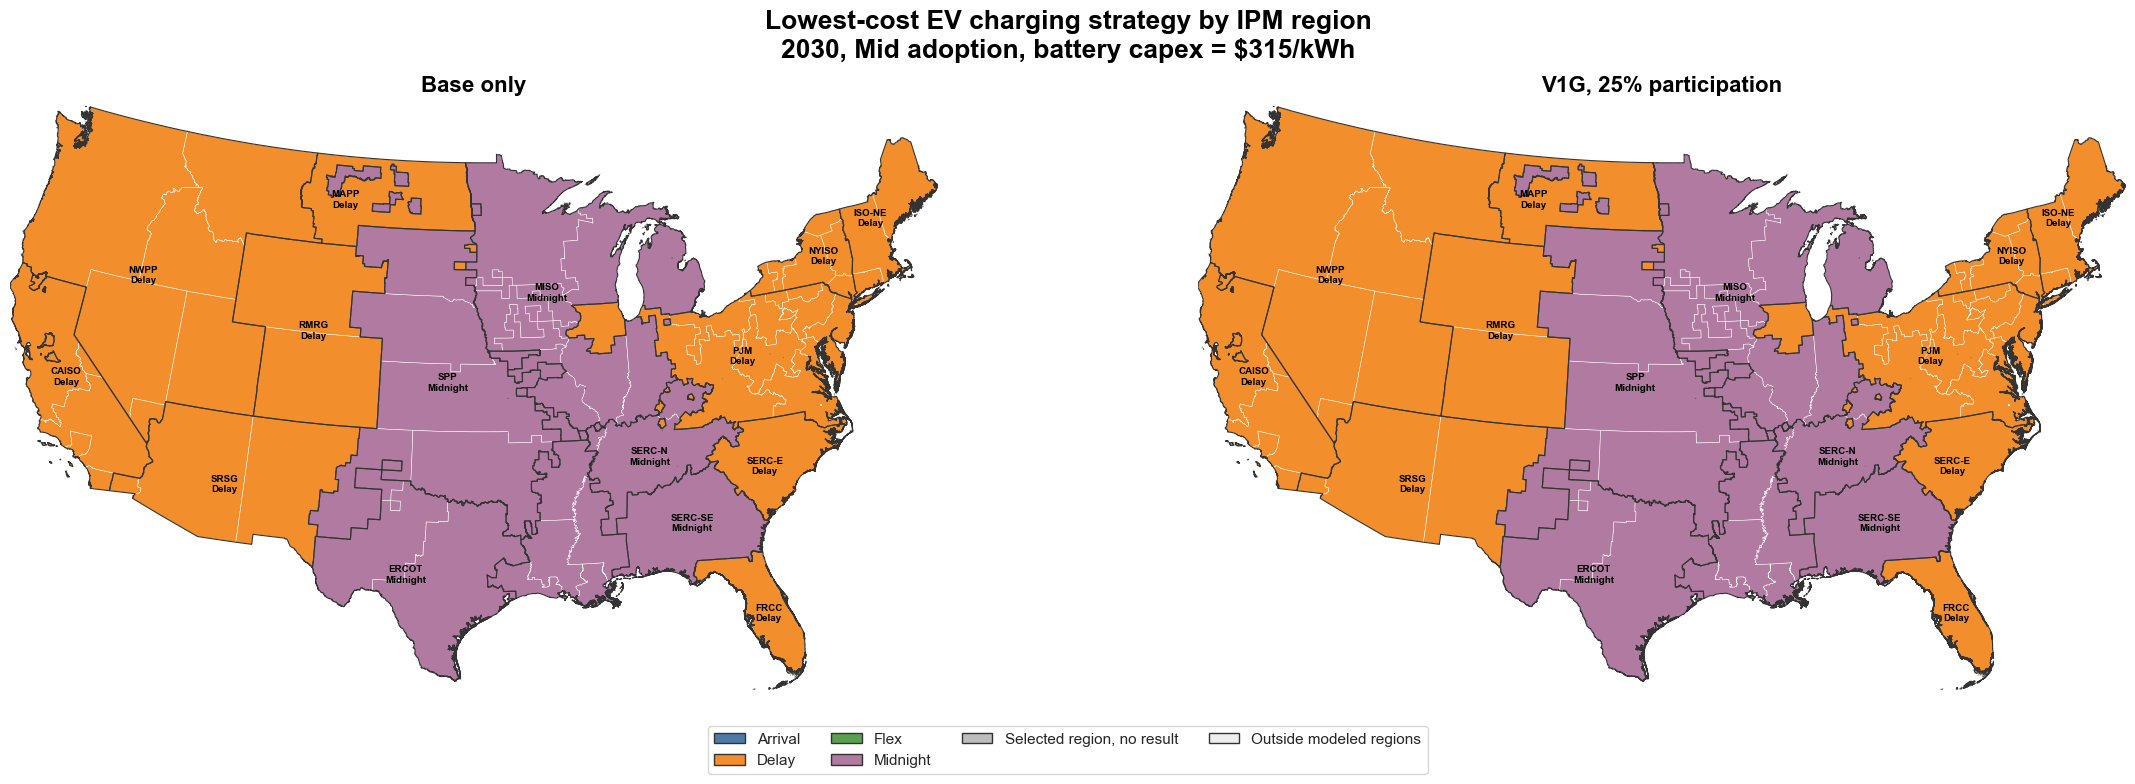

In [14]:
# =========================================================
# Regions included in the maps
# =========================================================
regions_to_map = (
    "CAISO",
    "ERCOT",
    "FRCC",
    "ISO-NE",
    "MAPP",
    "MISO",
    "NWPP",
    "NYISO",
    "PJM",
    "RMRG",
    "SERC-E",
    "SERC-N",
    "SERC-SE",
    "SPP",
    "SRSG",
)
# =========================================================
# RPS case represented on the maps
#
# Middle/base RPS case for each region
# =========================================================
map_rps_by_region = {
    "CAISO": 60,
    "NYISO": 70,
    "ERCOT": 50,
    "FRCC": 50,
    "ISO-NE": 0,
    "MAPP": 0,
    "MISO": 0,
    "NWPP": 0,
    "PJM": 0,
    "RMRG": 0,
    "SERC-E": 0,
    "SERC-N": 0,
    "SERC-SE": 0,
    "SPP": 0,
    "SRSG": 0,
}
# =========================================================
# Charging-scenario colors
# =========================================================
charging_scenario_colors = {
    "arrive": "#4E79A7",    # Blue
    "delay": "#F28E2B",     # Orange
    "flex": "#59A14F",      # Green
    "midnight": "#B07AA1",  # Purple
}
# =========================================================
# Generate the three maps
# =========================================================
(   df_best_charging,
    df_charging_comparison,
    fig,
    axes,
    ipm_map_gdf,
) = plot_best_charging_scenario_ipm_maps(
    output_root=OUTPUT_ROOT,
    shp_folder=(
    PROJECT_ROOT
    / "plot_cache" / "shapefiles"
    / "IPM_Regions_201770405.shp"
    ),
    region_col="IPM_Region",
    regions=regions_to_map,
    year=2030,
    adoption_level="mid",
    batt_capex=315,
    # Change to "V1G" to produce:
    # Base only | V1G 25% | V1G 50%
    selected_group="V1G",
    selected_participation=(
        "25%",
        # "50%",
    ),
    charging_scenarios=(
        "arrive",
        "delay",
        "flex",
        "midnight",
    ),
    rps_by_region=map_rps_by_region,
    # Your annual result folders use d360.
    model_days_per_run=360,
    scenario_colors=charging_scenario_colors,
    strict_scenario_check=True,
    duplicate_strategy="min_scenario_id",
    figsize=(24, 8),
    default_color="#EEEEEE",
    missing_color="#BDBDBD",
    edgecolor="white",
    linewidth=0.35,
    outer_boundary_color="#333333",
    outer_boundary_linewidth=0.8,
    label_model_regions=True,
    include_scenario_in_label=True,
    region_label_fontsize=7,
    legend=True,
    legend_ncol=4,
    legend_fontsize=11,
    cache_path=(
        PROJECT_ROOT
        / "plot_cache"
        / "best_charging_scenario_"
          "2030_mid_bcapex315_V2G.pkl"
    ),
    refresh_cache=False,
    summary_read_workers=15,
    save_path=(
        PROJECT_ROOT
        / "figures"
        / "best_charging_scenario_"
          "base_V2G25_V2G50_IPM_map.png"
    ),
    show=True,
)

plt.close(fig)

In [15]:
"""Plot least-cost EV charging scenarios in a 3 x 3 IPM map grid.

Rows are EV adoption levels (Slow, Mid, Fast). Columns are each region's
low, reference, and high RPS cases. Each map colors every modeled region by
the least-cost charging scenario among arrive, delay, flex, and midnight.

The selected technology case is explicit and never mixed:

* selected_group="Base only", selected_participation=None
* selected_group="V1G", selected_participation="25%" or "50%"
* selected_group="V2G", selected_participation="25%" or "50%"
"""

from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from time import perf_counter
import re

import numpy as np
import pandas as pd


REGION_ALIASES = {
    "CA": "CAISO",
    "CAISO": "CAISO",
    "TX": "ERCOT",
    "ERCOT": "ERCOT",
    "FL": "FRCC",
    "FRCC": "FRCC",
    "NY": "NYISO",
    "NYISO": "NYISO",
    "ISO-NE": "ISO-NE",
    "ISO_NE": "ISO-NE",
    "ISONE": "ISO-NE",
    "MAPP": "MAPP",
    "MISO": "MISO",
    "NWPP": "NWPP",
    "PJM": "PJM",
    "RMRG": "RMRG",
    "SERC-E": "SERC-E",
    "SERC_E": "SERC-E",
    "SERC-N": "SERC-N",
    "SERC_N": "SERC-N",
    "SERC-SE": "SERC-SE",
    "SERC_SE": "SERC-SE",
    "SPP": "SPP",
    "SRSG": "SRSG",
}


IPM_NODES_BY_MODEL_REGION = {
    "CAISO": ["WEC_CALN", "WEC_LADW", "WEC_SDGE", "WECC_SCE"],
    "ERCOT": ["ERC_PHDL", "ERC_REST", "ERC_WEST"],
    "FRCC": ["FRCC"],
    "ISO-NE": ["NENG_CT", "NENGREST", "NENG_ME"],
    "MAPP": ["MIS_MAPP"],
    "MISO": [
        "MIS_IL", "MIS_INKY", "MIS_IA", "MIS_MIDA", "MIS_LMI",
        "MIS_MO", "MIS_WUMS", "MIS_MNWI", "MIS_WOTA", "MIS_AMSO",
        "MIS_AR", "MIS_MS", "MIS_LA",
    ],
    "NWPP": [
        "WECC_MT", "WEC_BANC", "WECC_ID", "WECC_NNV", "WECC_SNV",
        "WECC_UT", "WECC_PNW",
    ],
    "NYISO": [
        "NY_Z_A", "NY_Z_B", "NY_Z_C&E", "NY_Z_D", "NY_Z_F",
        "NY_Z_G-I", "NY_Z_J", "NY_Z_K",
    ],
    "PJM": [
        "PJM_AP", "PJM_ATSI", "PJM_COMD", "PJM_Dom", "PJM_EMAC",
        "PJM_PENE", "PJM_SMAC", "PJM_WMAC", "PJM_West",
    ],
    "RMRG": ["WECC_CO", "WECC_WY"],
    "SERC-E": ["S_VACA"],
    "SERC-N": ["S_C_KY", "S_D_AECI", "S_C_TVA"],
    "SERC-SE": ["S_SOU"],
    "SPP": ["SPP_NEBR", "SPP_N", "SPP_WEST", "SPP_SPS", "SPP_WAUE"],
    "SRSG": ["WECC_AZ", "WECC_NM", "WECC_IID"],
}


DEFAULT_RPS_ORDER_BY_REGION = {
    "CAISO": [50, 60, 70],
    "NYISO": [60, 70, 80],
    "ERCOT": [0, 50, 60],
    "FRCC": [0, 50, 60],
    "ISO-NE": [-10, 0, 10],
    "MAPP": [-10, 0, 10],
    "MISO": [-10, 0, 10],
    "NWPP": [-10, 0, 10],
    "PJM": [-10, 0, 10],
    "RMRG": [-10, 0, 10],
    "SERC-E": [-10, 0, 10],
    "SERC-N": [-10, 0, 10],
    "SERC-SE": [-10, 0, 10],
    "SPP": [-10, 0, 10],
    "SRSG": [-10, 0, 10],
}


DEFAULT_CHARGING_SCENARIO_COLORS = {
    "arrive": "#4E79A7",
    "delay": "#F28E2B",
    "flex": "#59A14F",
    "midnight": "#B07AA1",
}

DEFAULT_CHARGING_SCENARIO_NAMES = {
    "arrive": "Arrival",
    "delay": "Delay",
    "flex": "Flex",
    "midnight": "Midnight",
}

# Your GOOD graph uses MIS_MS; the IPM shapefile uses MIS_D_MS.
DEFAULT_IPM_SHAPEFILE_NODE_ALIASES = {"MIS_MS": "MIS_D_MS"}


def normalize_region(region):
    """Normalize state-style aliases to output-folder/model-region names."""
    key = str(region).strip().upper()
    if key not in REGION_ALIASES:
        raise ValueError(
            f"Unknown region {region!r}. Allowed values: {sorted(REGION_ALIASES)}"
        )
    return REGION_ALIASES[key]


def _normalize_participation(value):
    """Return participation as '25%' style text."""
    if value is None:
        return None
    if isinstance(value, str):
        text = value.strip()
        number = float(text[:-1]) if text.endswith("%") else float(text)
    else:
        number = float(value)
        if 0 < number <= 1:
            number *= 100
    return f"{number:g}%"


def _normalize_selected_case(selected_group, selected_participation):
    text = str(selected_group).strip().upper().replace("_", " ")
    if text in {"BASE", "BASE ONLY", "BASEONLY"}:
        if selected_participation not in {None, 0, 0.0, "0", "0%"}:
            raise ValueError(
                "Base only must use selected_participation=None (or 0%)."
            )
        return "Base only", "0%"
    if text not in {"V1G", "V2G"}:
        raise ValueError("selected_group must be 'Base only', 'V1G', or 'V2G'.")
    participation = _normalize_participation(selected_participation)
    if participation is None:
        raise ValueError(f"{text} requires selected_participation, e.g. '25%'.")
    return text, participation


def find_ipm_shapefile(shp_folder):
    """Return a shapefile from either a .shp path or a folder."""
    path = Path(shp_folder)
    if path.is_file() and path.suffix.lower() == ".shp":
        return path
    if not path.exists():
        raise FileNotFoundError(f"IPM shapefile path does not exist: {path}")
    files = sorted(path.glob("*.shp"))
    if not files:
        raise FileNotFoundError(f"No .shp file was found in: {path}")
    return files[0]


def _normalize_region_map(mapping, regions, name, require_three=False):
    if mapping is None:
        raise ValueError(f"{name} cannot be None.")
    result = {normalize_region(key): value for key, value in mapping.items()}
    missing = [region for region in regions if region not in result]
    if missing:
        raise ValueError(f"Missing {name} values for: {missing}")
    if require_three:
        invalid = {
            region: result[region]
            for region in regions
            if len(result[region]) != 3
        }
        if invalid:
            raise ValueError(f"Every {name} entry must contain 3 values: {invalid}")
        result = {
            region: [float(value) for value in result[region]]
            for region in regions
        }
    return result


def _parse_rps_value(tag):
    tag = str(tag).lower()
    if re.search(r"rps[_-]?minus[_-]?10", tag):
        return -10
    if re.search(r"rps[_-]?base", tag):
        return 0
    if re.search(r"rps[_-]?plus[_-]?10", tag):
        return 10
    match = re.search(r"rps([+-]?\d+)(?=_|$)", tag)
    return int(match.group(1)) if match else None


def load_one_master_summary(
    output_root,
    region,
    adoption_level,
    charging_scenario,
    year=2030,
    batt_capex=315,
    model_days_per_run=360,
):
    """Load and normalize one all_scenarios_summary.csv efficiently."""
    region = normalize_region(region)
    adoption = str(adoption_level).strip().lower()
    charging = str(charging_scenario).strip().lower()
    region_dir = Path(output_root) / region
    expected = region_dir / (
        f"scenario_results_{year}_{adoption}_{region}_{charging}"
    ) / "all_scenarios_summary.csv"

    if not expected.exists():
        candidates = sorted(region_dir.glob(
            f"scenario_results_{year}_{adoption}_*_{charging}/"
            "all_scenarios_summary.csv"
        ))
        if not candidates:
            raise FileNotFoundError(f"Missing master summary: {expected}")
        expected = candidates[0]

    wanted = {
        "scenario_id", "tag", "group", "rps_ratio", "v1g_share",
        "v2g_share", "batt_capex_label", "objective_value",
        "adoption_level", "charging_scenario",
    }
    df = pd.read_csv(expected, usecols=lambda column: column in wanted)
    required = {
        "scenario_id", "tag", "v1g_share", "v2g_share",
        "objective_value", "adoption_level",
    }
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f"Missing columns in {expected}: {missing}")

    df = df.copy()
    df["model_days"] = df["tag"].astype(str).str.extract(
        r"(?:^|_)d(\d+)(?:_|$)", expand=False
    )
    df["model_days"] = pd.to_numeric(df["model_days"], errors="coerce")
    df["batt_capex_num"] = df["tag"].astype(str).str.extract(
        r"bcapex(\d+)", expand=False
    )
    df["batt_capex_num"] = pd.to_numeric(df["batt_capex_num"], errors="coerce")
    df["rps_plot_value"] = df["tag"].map(_parse_rps_value)
    df["v1g_share"] = pd.to_numeric(df["v1g_share"], errors="coerce").fillna(0)
    df["v2g_share"] = pd.to_numeric(df["v2g_share"], errors="coerce").fillna(0)
    df["objective_value"] = pd.to_numeric(df["objective_value"], errors="coerce")

    if model_days_per_run is not None:
        df = df[df["model_days"] == int(model_days_per_run)]
    if batt_capex is not None:
        df = df[df["batt_capex_num"] == int(batt_capex)]

    # Old mixed V1G+V2G rows must never enter the comparison.
    df = df[~((df["v1g_share"] > 0) & (df["v2g_share"] > 0))].copy()
    df["group"] = np.select(
        [df["v1g_share"] > 0, df["v2g_share"] > 0],
        ["V1G", "V2G"],
        default="Base only",
    )
    share = np.where(
        df["v1g_share"] > 0, df["v1g_share"],
        np.where(df["v2g_share"] > 0, df["v2g_share"], 0),
    )
    df["participation"] = [f"{100 * float(value):g}%" for value in share]
    df["region"] = region
    df["adoption"] = adoption
    df["scenario_label"] = charging
    df["file_path"] = str(expected)
    df["objective_value_mil"] = df["objective_value"] / 1e6
    return df.dropna(subset=["rps_plot_value", "objective_value"])


def _drop_duplicate_cases(df, duplicate_strategy="min_scenario_id"):
    """Keep one physical result per case; adoption is deliberately a key."""
    keys = [
        "region", "adoption", "scenario_label", "group", "participation",
        "rps_plot_value", "batt_capex_num",
    ]
    if duplicate_strategy == "error":
        duplicated = df.duplicated(keys, keep=False)
        if duplicated.any():
            raise ValueError(
                "Duplicate cases found:\n"
                + df.loc[duplicated, keys + ["scenario_id", "file_path"]]
                .to_string(index=False)
            )
        return df.reset_index(drop=True)
    if duplicate_strategy not in {"min_scenario_id", "max_scenario_id"}:
        raise ValueError(
            "duplicate_strategy must be 'min_scenario_id', "
            "'max_scenario_id', or 'error'."
        )
    ascending = duplicate_strategy == "min_scenario_id"
    ordered = df.sort_values(
        keys + ["scenario_id", "file_path"],
        ascending=[True] * len(keys) + [ascending, ascending],
        kind="stable",
    )
    return ordered.drop_duplicates(keys, keep="first").reset_index(drop=True)


def compute_best_charging_scenario_grid(
    output_root,
    regions=tuple(IPM_NODES_BY_MODEL_REGION),
    year=2030,
    adoption_levels=("slow", "mid", "fast"),
    batt_capex=315,
    selected_group="V1G",
    selected_participation="25%",
    charging_scenarios=("arrive", "delay", "flex", "midnight"),
    rps_order_by_region=None,
    rps_level_names=("Low RPS", "Reference RPS", "High RPS"),
    model_days_per_run=360,
    duplicate_strategy="min_scenario_id",
    strict_scenario_check=True,
    cache_path=None,
    refresh_cache=False,
    summary_read_workers=15,
):
    """Return the least-cost charging scenario for every 3 x 3 map cell."""
    regions = tuple(normalize_region(region) for region in regions)
    if len(regions) != len(set(regions)):
        raise ValueError(f"Duplicate regions after normalization: {regions}")
    adoption_levels = tuple(str(value).strip().lower() for value in adoption_levels)
    if len(adoption_levels) != 3:
        raise ValueError("adoption_levels must contain exactly 3 rows.")
    charging_scenarios = tuple(
        str(value).strip().lower() for value in charging_scenarios
    )
    if len(set(charging_scenarios)) != len(charging_scenarios):
        raise ValueError("charging_scenarios contains duplicates.")
    unknown = sorted(set(charging_scenarios) - set(DEFAULT_CHARGING_SCENARIO_COLORS))
    if unknown:
        raise ValueError(f"Unknown charging scenarios: {unknown}")
    group, participation = _normalize_selected_case(
        selected_group, selected_participation
    )
    if len(rps_level_names) != 3:
        raise ValueError("rps_level_names must contain exactly 3 column names.")
    rps_order_by_region = _normalize_region_map(
        rps_order_by_region or DEFAULT_RPS_ORDER_BY_REGION,
        regions,
        "rps_order_by_region",
        require_three=True,
    )

    metadata = {
        "regions": regions,
        "year": int(year),
        "adoption_levels": adoption_levels,
        "batt_capex": int(batt_capex),
        "selected_group": group,
        "selected_participation": participation,
        "charging_scenarios": charging_scenarios,
        "rps_order_by_region": rps_order_by_region,
        "rps_level_names": tuple(rps_level_names),
        "model_days_per_run": model_days_per_run,
        "duplicate_strategy": duplicate_strategy,
        "strict_scenario_check": bool(strict_scenario_check),
    }
    cache_path = Path(cache_path) if cache_path is not None else None
    if cache_path is not None and cache_path.exists() and not refresh_cache:
        cached = pd.read_pickle(cache_path)
        if cached.get("metadata") == metadata:
            print(f"Loaded charging-grid cache: {cache_path}")
            return cached["best_df"].copy(), cached["comparison_df"].copy()
        print("Charging-grid cache settings changed; rebuilding it.")

    tasks = [
        (region, adoption, scenario)
        for region in regions
        for adoption in adoption_levels
        for scenario in charging_scenarios
    ]

    def read_task(task):
        region, adoption, scenario = task
        try:
            return load_one_master_summary(
                output_root=output_root,
                region=region,
                adoption_level=adoption,
                charging_scenario=scenario,
                year=year,
                batt_capex=batt_capex,
                model_days_per_run=model_days_per_run,
            )
        except Exception as exc:
            raise RuntimeError(
                f"Could not load {region}, {adoption}, {scenario}: {exc}"
            ) from exc

    started = perf_counter()
    workers = max(1, min(int(summary_read_workers), len(tasks)))
    with ThreadPoolExecutor(max_workers=workers) as executor:
        frames = list(executor.map(read_task, tasks))
    frames = [frame.dropna(axis=1, how="all") for frame in frames if not frame.empty]
    if not frames:
        raise ValueError("No matching master-summary data were loaded.")
    costs = pd.concat(frames, ignore_index=True)
    costs = _drop_duplicate_cases(costs, duplicate_strategy)
    print(f"Read {len(tasks)} master summary files in {perf_counter()-started:.2f} s.")

    # This filter is the firewall that prevents Base/V1G/V2G mixing.
    costs = costs[
        (costs["group"] == group)
        & (costs["participation"] == participation)
    ].copy()
    if costs.empty:
        raise ValueError(f"No data found for {group}, {participation}.")

    rank = {scenario: index for index, scenario in enumerate(charging_scenarios)}
    best_records = []
    comparison_frames = []
    missing = []

    for region in regions:
        for adoption in adoption_levels:
            regional = costs[
                (costs["region"] == region) & (costs["adoption"] == adoption)
            ]
            for column_index, (level_name, target_rps) in enumerate(
                zip(rps_level_names, rps_order_by_region[region])
            ):
                comparison = regional[np.isclose(
                    regional["rps_plot_value"].astype(float),
                    float(target_rps), rtol=0.0, atol=1e-9,
                )].copy()
                available = set(comparison["scenario_label"])
                missing_scenarios = [
                    value for value in charging_scenarios if value not in available
                ]
                if missing_scenarios:
                    missing.append(
                        f"{region}, {adoption}, {level_name} "
                        f"(RPS={target_rps:g}): missing {missing_scenarios}"
                    )
                    if strict_scenario_check:
                        continue
                if comparison.empty:
                    continue
                comparison["scenario_rank"] = comparison["scenario_label"].map(rank)
                comparison["rps_level"] = level_name
                comparison["rps_column"] = column_index
                comparison["target_rps"] = target_rps
                comparison = comparison.sort_values(
                    ["objective_value", "scenario_rank"], kind="stable"
                )
                comparison_frames.append(comparison)
                best = comparison.iloc[0]
                best_records.append({
                    "region": region,
                    "adoption": adoption,
                    "rps_level": level_name,
                    "rps_column": column_index,
                    "target_rps": target_rps,
                    "selected_group": group,
                    "participation": participation,
                    "best_scenario": best["scenario_label"],
                    "best_scenario_display": DEFAULT_CHARGING_SCENARIO_NAMES[
                        best["scenario_label"]
                    ],
                    "objective_value": float(best["objective_value"]),
                    "objective_value_mil": float(best["objective_value"]) / 1e6,
                    "scenario_id": int(best["scenario_id"]),
                    "scenario_tag": best["tag"],
                    "file_path": best["file_path"],
                })

    if missing and strict_scenario_check:
        raise ValueError(
            "Incomplete comparisons; every cell needs all requested charging "
            "scenarios:\n" + "\n".join(missing)
        )
    if missing:
        print("WARNING: incomplete comparisons:\n" + "\n".join(missing))

    best_df = pd.DataFrame(best_records)
    comparison_df = (
        pd.concat(comparison_frames, ignore_index=True)
        if comparison_frames else pd.DataFrame()
    )
    if cache_path is not None:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        pd.to_pickle(
            {"metadata": metadata, "best_df": best_df,
             "comparison_df": comparison_df},
            cache_path,
        )
        print(f"Saved charging-grid cache: {cache_path}")
    return best_df, comparison_df


def plot_best_charging_scenario_ipm_grid(
    output_root,
    shp_folder=None,
    region_col="IPM_Region",
    regions=tuple(IPM_NODES_BY_MODEL_REGION),
    year=2030,
    adoption_levels=("slow", "mid", "fast"),
    batt_capex=315,
    selected_group="V2G",
    selected_participation="25%",
    charging_scenarios=("arrive", "delay", "flex", "midnight"),
    rps_order_by_region=None,
    rps_level_names=("Low RPS", "Reference RPS", "High RPS"),
    model_days_per_run=360,
    region_nodes_by_model_region=None,
    ipm_node_aliases=None,
    scenario_colors=None,
    duplicate_strategy="min_scenario_id",
    strict_scenario_check=True,
    ipm_gdf=None,
    projection="EPSG:5070",
    figsize=(24, 18),
    default_color="#EEEEEE",
    missing_color="#BDBDBD",
    edgecolor="white",
    linewidth=0.30,
    outer_boundary_color="#333333",
    outer_boundary_linewidth=0.70,
    background_color="white",
    font_color="black",
    figure_title=None,
    figure_title_fontsize=20,
    panel_title_fontsize=17,
    row_label_fontsize=17,
    region_label_fontsize=6,
    label_model_regions=True,
    include_scenario_in_label=True,
    legend=True,
    legend_ncol=6,
    legend_fontsize=11,
    cache_path=None,
    refresh_cache=False,
    summary_read_workers=15,
    save_path=None,
    save_dpi=300,
    show=False,
):
    """Draw a 3-row adoption by 3-column RPS least-cost scenario map."""
    import geopandas as gpd
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    regions = tuple(normalize_region(region) for region in regions)
    adoption_levels = tuple(str(value).strip().lower() for value in adoption_levels)
    group, participation = _normalize_selected_case(
        selected_group, selected_participation
    )
    node_map = _normalize_region_map(
        region_nodes_by_model_region or IPM_NODES_BY_MODEL_REGION,
        regions,
        "region_nodes_by_model_region",
    )
    aliases = ipm_node_aliases or DEFAULT_IPM_SHAPEFILE_NODE_ALIASES
    colors = {
        str(key).strip().lower(): value
        for key, value in (
            scenario_colors or DEFAULT_CHARGING_SCENARIO_COLORS
        ).items()
    }
    missing_colors = sorted(set(charging_scenarios) - set(colors))
    if missing_colors:
        raise ValueError(f"scenario_colors is missing: {missing_colors}")

    best_df, comparison_df = compute_best_charging_scenario_grid(
        output_root=output_root,
        regions=regions,
        year=year,
        adoption_levels=adoption_levels,
        batt_capex=batt_capex,
        selected_group=group,
        selected_participation=participation,
        charging_scenarios=charging_scenarios,
        rps_order_by_region=rps_order_by_region,
        rps_level_names=rps_level_names,
        model_days_per_run=model_days_per_run,
        duplicate_strategy=duplicate_strategy,
        strict_scenario_check=strict_scenario_check,
        cache_path=cache_path,
        refresh_cache=refresh_cache,
        summary_read_workers=summary_read_workers,
    )

    if ipm_gdf is None:
        if shp_folder is None:
            raise ValueError("Provide either shp_folder or ipm_gdf.")
        shp_path = find_ipm_shapefile(shp_folder)
        map_gdf = gpd.read_file(shp_path)
        print(f"Loaded IPM shapefile: {shp_path}")
    else:
        map_gdf = ipm_gdf.copy()
    if region_col not in map_gdf.columns:
        raise ValueError(
            f"region_col={region_col!r} was not found. "
            f"Available columns: {list(map_gdf.columns)}"
        )
    if map_gdf.crs is None:
        raise ValueError("The IPM GeoDataFrame has no CRS.")

    map_gdf = map_gdf.to_crs(projection)
    map_gdf[region_col] = map_gdf[region_col].astype(str).str.strip()
    ipm_to_model = {}
    for model_region, nodes in node_map.items():
        for node in nodes:
            shape_node = aliases.get(node, node)
            if shape_node in ipm_to_model:
                raise ValueError(
                    f"IPM node {shape_node} belongs to both "
                    f"{ipm_to_model[shape_node]} and {model_region}."
                )
            ipm_to_model[shape_node] = model_region
    missing_nodes = sorted(set(ipm_to_model) - set(map_gdf[region_col]))
    if missing_nodes:
        print("WARNING: IPM nodes not found in shapefile:\n" + str(missing_nodes))
    map_gdf["model_region"] = map_gdf[region_col].map(ipm_to_model)

    modeled_geometry = map_gdf.loc[
        map_gdf["model_region"].notna(), ["model_region", "geometry"]
    ].dissolve(by="model_region")
    modeled_geometry["label_point"] = (
        modeled_geometry.geometry.representative_point()
    )
    x_min, y_min, x_max, y_max = map_gdf.total_bounds
    fig, axes = plt.subplots(
        3, 3, figsize=figsize, squeeze=False, facecolor=background_color
    )
    mapped_frames = []
    render_started = perf_counter()

    for row, adoption in enumerate(adoption_levels):
        for column, level_name in enumerate(rps_level_names):
            ax = axes[row, column]
            panel_best = best_df[
                (best_df["adoption"] == adoption)
                & (best_df["rps_column"] == column)
            ][[
                "region", "best_scenario", "best_scenario_display",
                "objective_value_mil", "target_rps",
            ]].copy()
            panel = map_gdf.merge(
                panel_best, how="left", left_on="model_region", right_on="region"
            )
            panel["plot_color"] = default_color
            selected = panel["model_region"].notna()
            panel.loc[selected & panel["best_scenario"].isna(), "plot_color"] = (
                missing_color
            )
            for scenario, color in colors.items():
                panel.loc[panel["best_scenario"] == scenario, "plot_color"] = color
            panel.plot(
                ax=ax, color=panel["plot_color"], edgecolor=edgecolor,
                linewidth=linewidth,
            )
            if not modeled_geometry.empty:
                modeled_geometry.boundary.plot(
                    ax=ax, color=outer_boundary_color,
                    linewidth=outer_boundary_linewidth,
                )
            if label_model_regions and not modeled_geometry.empty:
                labels = modeled_geometry.join(
                    panel_best.set_index("region")[
                        ["best_scenario_display", "target_rps"]
                    ],
                    how="left",
                )
                for model_region, item in labels.iterrows():
                    text = model_region
                    if include_scenario_in_label and pd.notna(
                        item.get("best_scenario_display")
                    ):
                        text += "\n" + str(item["best_scenario_display"])
                    point = item["label_point"]
                    ax.text(
                        point.x, point.y, text,
                        fontsize=region_label_fontsize, color=font_color,
                        ha="center", va="center", fontweight="bold",
                    )
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
            ax.set_aspect("equal")
            ax.set_facecolor(background_color)
            ax.axis("off")
            if row == 0:
                ax.set_title(
                    level_name, fontsize=panel_title_fontsize,
                    fontweight="bold", color=font_color, pad=9,
                )
            if column == 0:
                ax.text(
                    -0.025, 0.5, adoption.capitalize(), transform=ax.transAxes,
                    rotation=90, ha="right", va="center",
                    fontsize=row_label_fontsize, fontweight="bold",
                    color=font_color,
                )
            panel["adoption"] = adoption
            panel["rps_level"] = level_name
            panel["rps_column"] = column
            mapped_frames.append(panel)

    print(f"Rendered 9 map panels in {perf_counter()-render_started:.2f} s.")
    case_label = group if group == "Base only" else f"{group}, {participation}"
    if figure_title is None:
        figure_title = (
            "Lowest-cost EV charging strategy by IPM region\n"
            f"{case_label}; {year}; battery capex = ${batt_capex}/kWh"
        )
    if figure_title:
        fig.suptitle(
            figure_title, fontsize=figure_title_fontsize,
            fontweight="bold", color=font_color, y=0.985,
        )
    if legend:
        handles = [
            Patch(
                facecolor=colors[scenario], edgecolor=outer_boundary_color,
                label=DEFAULT_CHARGING_SCENARIO_NAMES.get(
                    scenario, scenario.title()
                ),
            )
            for scenario in charging_scenarios
        ]
        handles += [
            Patch(
                facecolor=missing_color, edgecolor=outer_boundary_color,
                label="Modeled region, no result",
            ),
            Patch(
                facecolor=default_color, edgecolor=outer_boundary_color,
                label="Outside modeled regions",
            ),
        ]
        fig.legend(
            handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.012),
            ncol=int(legend_ncol), frameon=True, fontsize=legend_fontsize,
        )
    fig.subplots_adjust(
        left=0.035, right=0.99, top=0.92, bottom=0.075,
        wspace=0.015, hspace=0.035,
    )
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            save_path, dpi=save_dpi, bbox_inches="tight",
            facecolor=background_color,
        )
        print(f"Saved map figure: {save_path}")
    mapped_gdf = pd.concat(mapped_frames, ignore_index=True)
    if show:
        plt.show()
    return (
        best_df.reset_index(drop=True),
        comparison_df.reset_index(drop=True),
        fig,
        axes,
        mapped_gdf,
    )

Loaded charging-grid cache: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL/plot_cache/best_charging_grid_2030_bcapex315_V2G25.pkl
Loaded IPM shapefile: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL/plot_cache/shapefiles/IPM_Regions_201770405.shp
Rendered 9 map panels in 128.60 s.
Saved map figure: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL/figures/best_charging_grid_3x3_2030_V2G25.png


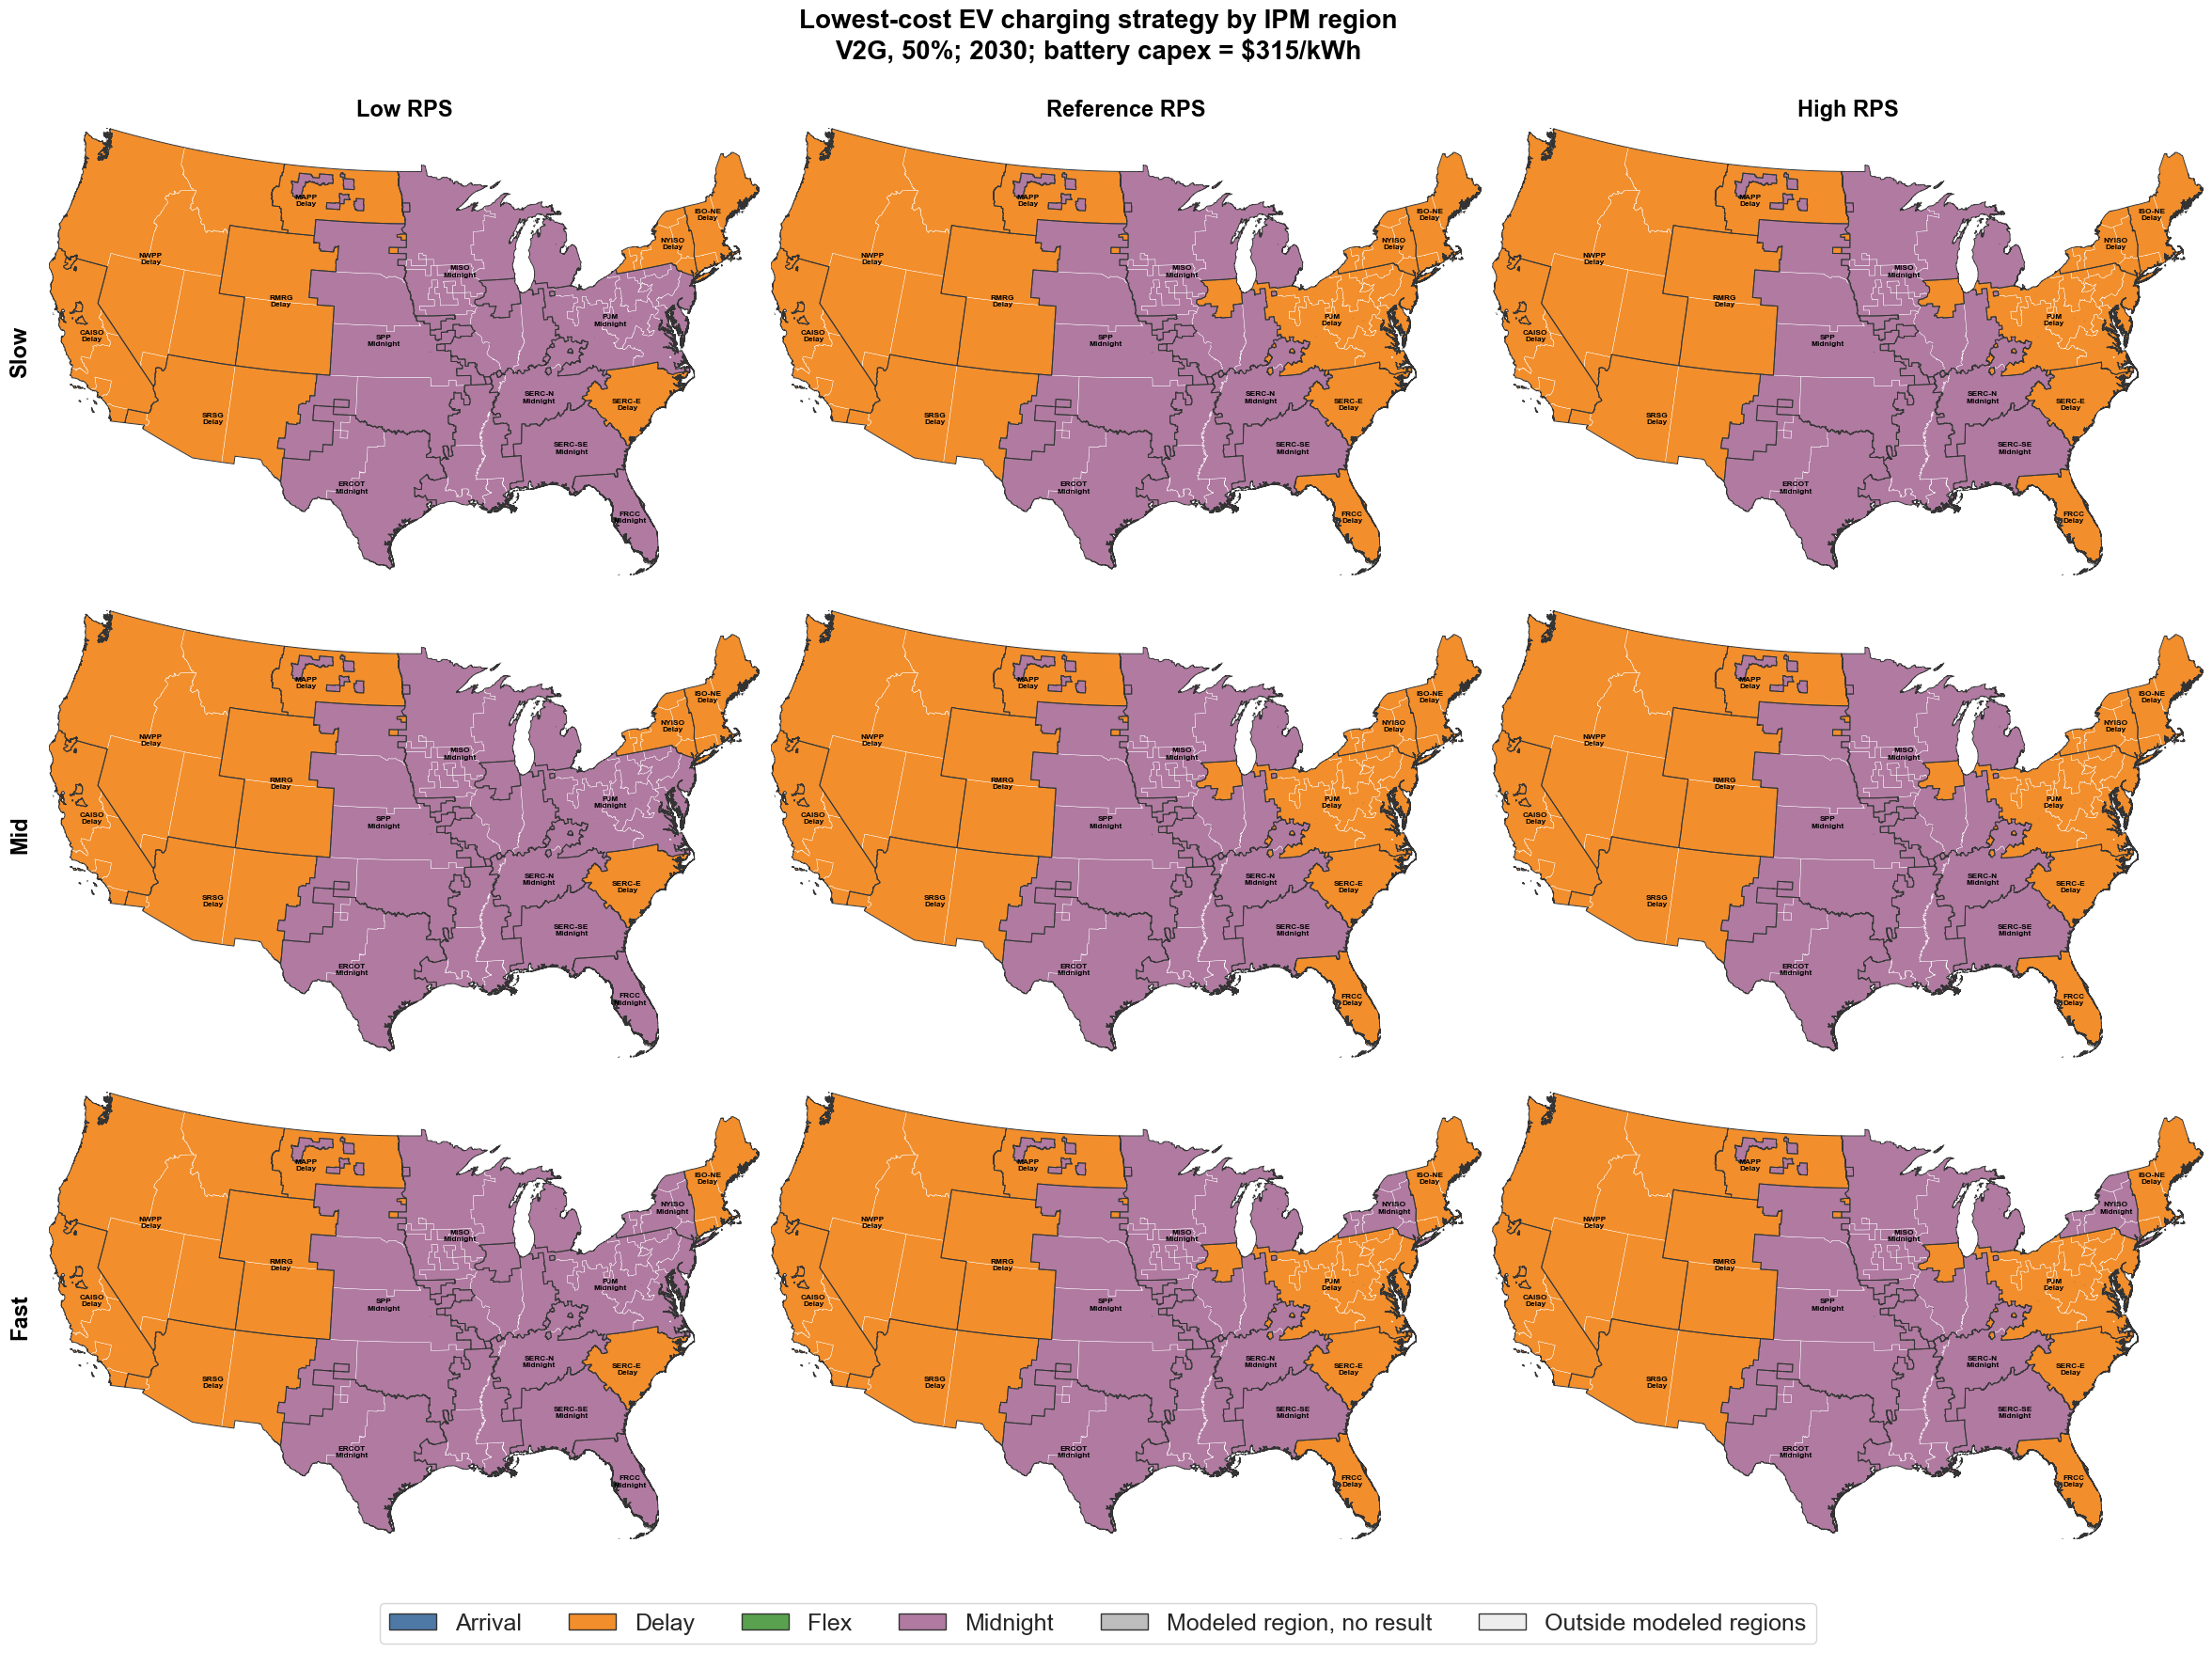

In [22]:
(   df_best,
    df_comparison,
    fig,
    axes,
    ipm_map_gdf,
) = plot_best_charging_scenario_ipm_grid(
    output_root=OUTPUT_ROOT,
    shp_folder=(
        PROJECT_ROOT
        / "plot_cache"
        / "shapefiles"
        / "IPM_Regions_201770405.shp"
    ),
    region_col="IPM_Region",
    regions=(
        "CAISO",
        "ERCOT",
        "FRCC",
        "ISO-NE",
        "MAPP",
        "MISO",
        "NWPP",
        "NYISO",
        "PJM",
        "RMRG",
        "SERC-E",
        "SERC-N",
        "SERC-SE",
        "SPP",
        "SRSG",
    ),
    year=2030,
    adoption_levels=(
        "slow",
        "mid",
        "fast",
    ),
    batt_capex=315,
    # =====================================================
    # Select exactly one case
    # =====================================================
    selected_group="V2G",
    selected_participation="50%",
    charging_scenarios=(
        "arrive",
        "delay",
        "flex",
        "midnight",
    ),
    rps_order_by_region=DEFAULT_RPS_ORDER_BY_REGION,
    rps_level_names=(
        "Low RPS",
        "Reference RPS",
        "High RPS",
    ),
    model_days_per_run=360,
    strict_scenario_check=True,
    duplicate_strategy="min_scenario_id",
    cache_path=(
        PROJECT_ROOT
        / "plot_cache"
        / "best_charging_grid_2030_bcapex315_V2G25.pkl"
    ),
    # True after changing model results; otherwise False.
    refresh_cache=False,
    legend_ncol=6,
    legend_fontsize=18,
    summary_read_workers=15,
    figsize=(24, 18),
    label_model_regions=True,
    include_scenario_in_label=True,
    save_path=(
        PROJECT_ROOT
        / "figures"
        / "best_charging_grid_3x3_2030_V2G25.png"
    ),
    show=True,
)

plt.close(fig)

Charging-grid cache settings changed; rebuilding it.
Read 180 master summary files in 3.12 s.
Saved charging-grid cache: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL/plot_cache/best_charging_grid_2030_bcapex315_V2G25.pkl
Loaded IPM shapefile: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL/plot_cache/shapefiles/IPM_Regions_201770405.shp
Rendered 9 map panels in 125.08 s.
Saved map figure: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL/figures/best_charging_grid_3x3_2030_V2G25.png


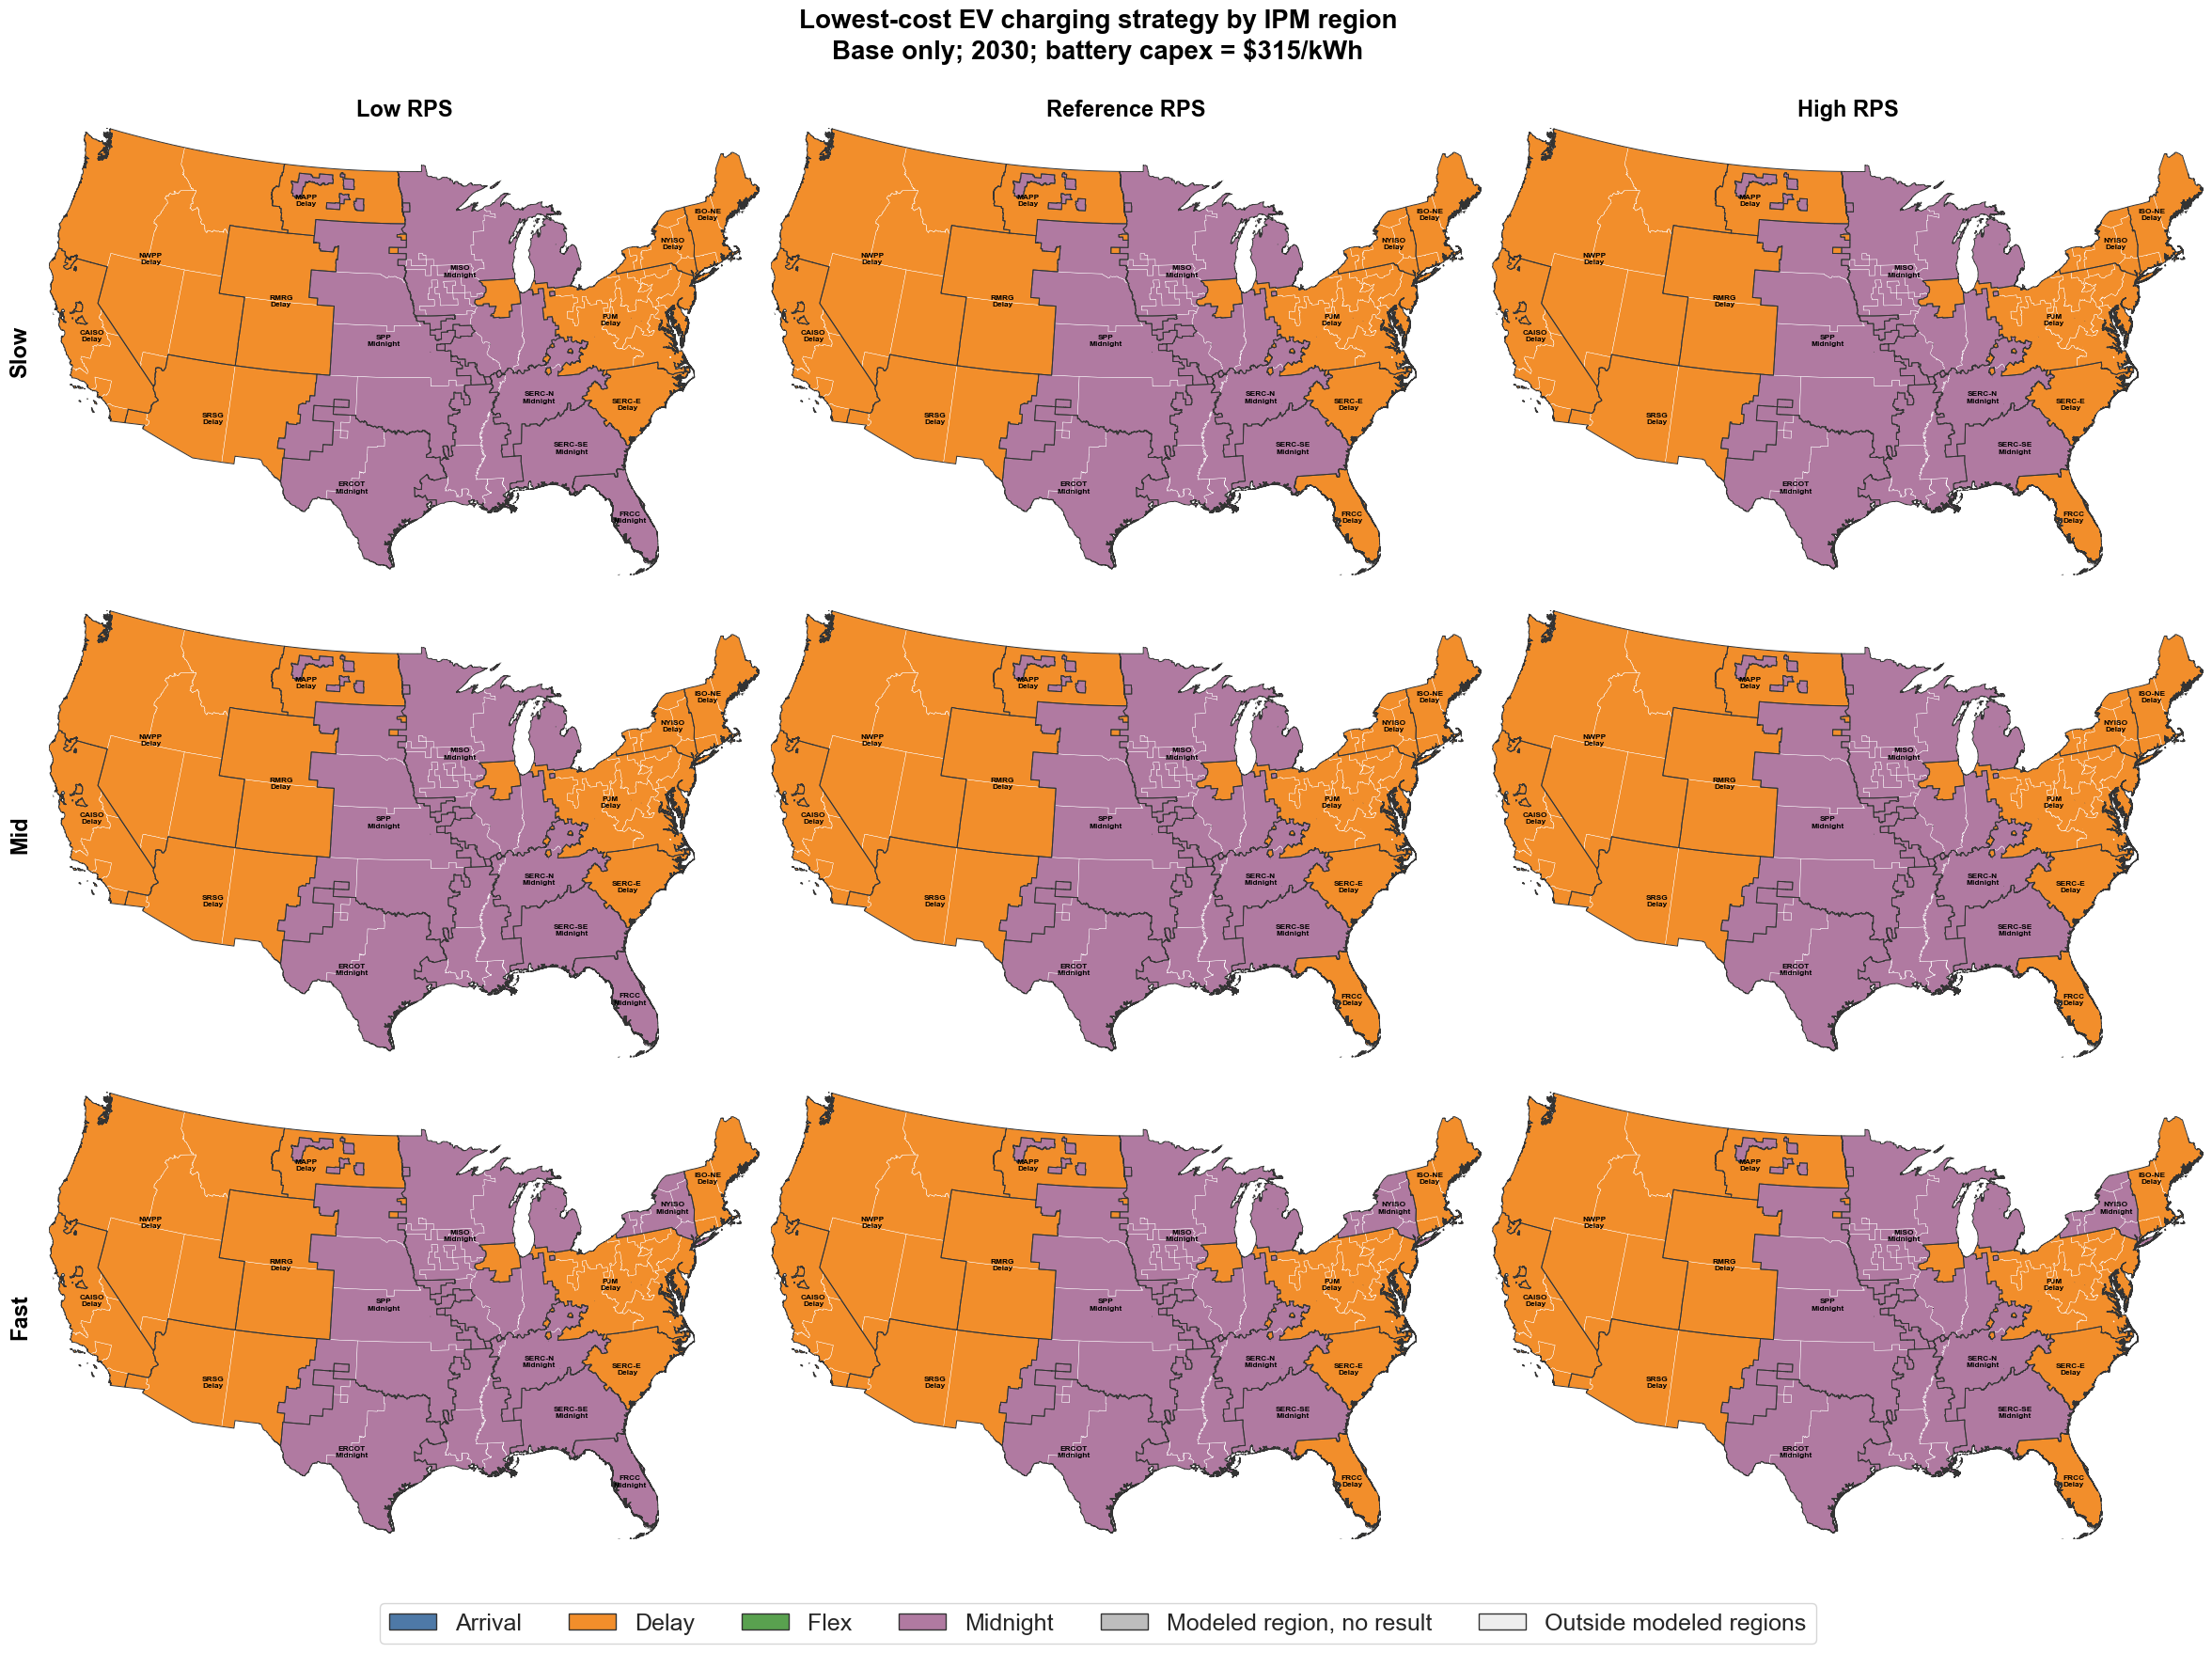

In [23]:
(   df_best,
    df_comparison,
    fig,
    axes,
    ipm_map_gdf,
) = plot_best_charging_scenario_ipm_grid(
    output_root=OUTPUT_ROOT,
    shp_folder=(
        PROJECT_ROOT
        / "plot_cache"
        / "shapefiles"
        / "IPM_Regions_201770405.shp"
    ),
    region_col="IPM_Region",
    regions=(
        "CAISO",
        "ERCOT",
        "FRCC",
        "ISO-NE",
        "MAPP",
        "MISO",
        "NWPP",
        "NYISO",
        "PJM",
        "RMRG",
        "SERC-E",
        "SERC-N",
        "SERC-SE",
        "SPP",
        "SRSG",
    ),
    year=2030,
    adoption_levels=(
        "slow",
        "mid",
        "fast",
    ),
    batt_capex=315,
    # =====================================================
    # Select exactly one case
    # =====================================================
    selected_group="Base only",
    selected_participation=None,
    charging_scenarios=(
        "arrive",
        "delay",
        "flex",
        "midnight",
    ),
    rps_order_by_region=DEFAULT_RPS_ORDER_BY_REGION,
    rps_level_names=(
        "Low RPS",
        "Reference RPS",
        "High RPS",
    ),
    model_days_per_run=360,
    strict_scenario_check=True,
    legend_ncol=6,
    legend_fontsize=18,
    duplicate_strategy="min_scenario_id",
    cache_path=(
        PROJECT_ROOT
        / "plot_cache"
        / "best_charging_grid_2030_bcapex315_V2G25.pkl"
    ),
    # True after changing model results; otherwise False.
    refresh_cache=False,
    summary_read_workers=15,
    figsize=(24, 18),
    label_model_regions=True,
    include_scenario_in_label=True,
    save_path=(
        PROJECT_ROOT
        / "figures"
        / "best_charging_grid_3x3_2030_V2G25.png"
    ),
    show=True,
)

plt.close(fig)

In [24]:
import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch


REGION_ALIASES_CURTAILMENT = {
    "CA": "CAISO", "CAISO": "CAISO",
    "TX": "ERCOT", "ERCOT": "ERCOT",
    "FL": "FRCC", "FRCC": "FRCC",
    "NY": "NYISO", "NYISO": "NYISO",
    "PJM": "PJM", "MAPP": "MAPP", "MISO": "MISO",
    "ISO-NE": "ISO-NE", "ISO_NE": "ISO-NE", "ISONE": "ISO-NE",
    "NWPP": "NWPP", "RMRG": "RMRG",
    "SERC-E": "SERC-E", "SERC_E": "SERC-E",
    "SERC-N": "SERC-N", "SERC_N": "SERC-N",
    "SERC-SE": "SERC-SE", "SERC_SE": "SERC-SE",
    "SPP": "SPP", "SRSG": "SRSG",
}

RELATIVE_RPS_REGIONS_CURTAILMENT = {
    "PJM", "MAPP", "MISO", "ISO-NE", "NWPP", "RMRG",
    "SERC-E", "SERC-N", "SERC-SE", "SPP", "SRSG",
}


def _normalize_curtailment_region(region):
    key = str(region).strip().upper()
    if key not in REGION_ALIASES_CURTAILMENT:
        raise ValueError(
            f"Unknown region {region!r}. Allowed values are "
            f"{sorted(REGION_ALIASES_CURTAILMENT)}"
        )
    return REGION_ALIASES_CURTAILMENT[key]


def _normalize_region_mapping(mapping, regions, name):
    if mapping is None:
        raise ValueError(f"{name} cannot be None.")
    normalized = {
        _normalize_curtailment_region(key): value
        for key, value in mapping.items()
    }
    missing = [region for region in regions if region not in normalized]
    if missing:
        raise ValueError(f"{name} is missing regions: {missing}")
    return {region: normalized[region] for region in regions}


def _get_curtailment_results_dir(
    output_root, region, year, adoption, scenario_label
):
    output_root = Path(output_root)
    region = _normalize_curtailment_region(region)
    adoption = str(adoption).strip().lower()
    scenario_label = str(scenario_label).strip().lower()
    candidates = [
        output_root / region
        / f"scenario_results_{year}_{adoption}_{region}_{scenario_label}",
        output_root
        / f"scenario_results_{year}_{adoption}_{region}_{scenario_label}",
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "Could not find the selected result folder. Tried:\n"
        + "\n".join(str(path) for path in candidates)
    )


def _find_solution_csv(scenario_folder):
    scenario_folder = Path(scenario_folder)
    matches = sorted(scenario_folder.glob("*_solution.csv"))
    if not matches:
        matches = sorted(scenario_folder.rglob("*_solution.csv"))
    bad_words = ("old", "backup", "copy", "warm", "checkpoint", "debug")
    clean = [
        path for path in matches
        if not any(word in str(path).lower() for word in bad_words)
    ]
    matches = clean or matches
    if not matches:
        return None
    return sorted(matches, key=lambda path: (len(str(path)), str(path)))[0]


def _parse_curtailment_case(path_or_folder, region):
    path = Path(path_or_folder)
    text = f"{path.parent.name}_{path.name}".lower()

    scenario_match = re.search(r"(?:^|_)s0*(\d+)_", text)
    scenario_id = int(scenario_match.group(1)) if scenario_match else None

    v1g_match = re.search(r"v1g(\d+)", text)
    v2g_match = re.search(r"v2g(\d+)", text)
    v1g = int(v1g_match.group(1)) if v1g_match else 0
    v2g = int(v2g_match.group(1)) if v2g_match else 0

    if v1g > 0 and v2g > 0:
        group = "V1G+V2G"
        participation = f"{v1g + v2g}%"
    elif v1g > 0:
        group = "V1G"
        participation = f"{v1g}%"
    elif v2g > 0:
        group = "V2G"
        participation = f"{v2g}%"
    else:
        group = "Base only"
        participation = "0%"

    if "rps_minus10" in text or "rpsminus10" in text:
        rps = -10
    elif "rps_base" in text or "rpsbase" in text:
        rps = 0
    elif "rps_plus10" in text or "rpsplus10" in text:
        rps = 10
    else:
        rps_match = re.search(r"rps(-?\d+)", text)
        rps = int(rps_match.group(1)) if rps_match else None

    batt_match = re.search(r"bcapex(\d+)", text)
    batt_capex = int(batt_match.group(1)) if batt_match else None

    days_match = re.search(r"(?:^|_)d(\d+)(?:_|\.|$)", text)
    model_days = int(days_match.group(1)) if days_match else None

    return {
        "region": _normalize_curtailment_region(region),
        "scenario_id": scenario_id,
        "group": group,
        "participation": participation,
        "rps": rps,
        "batt_capex": batt_capex,
        "model_days": model_days,
    }


def read_total_wastage_from_solution_csv(
    solution_csv_path, time_step_h=1.0, chunksize=2048
):
    """Read only NODE::wastage columns and return total and nodal TWh."""
    solution_csv_path = Path(solution_csv_path)
    node_wh = {}
    found_columns = None

    reader = pd.read_csv(
        solution_csv_path,
        usecols=lambda column: str(column).endswith("::wastage"),
        chunksize=chunksize,
    )

    for chunk in reader:
        if found_columns is None:
            found_columns = list(chunk.columns)
        numeric = chunk.apply(pd.to_numeric, errors="coerce").fillna(0.0)
        for column, value in numeric.sum(axis=0).items():
            node = str(column).removesuffix("::wastage")
            node_wh[node] = node_wh.get(node, 0.0) + float(value) * time_step_h

    if not found_columns:
        raise ValueError(
            f"No columns ending with '::wastage' were found in {solution_csv_path}"
        )

    node_twh = {node: value / 1e12 for node, value in node_wh.items()}
    return sum(node_twh.values()), node_twh


def _collect_selected_curtailment_cases(
    output_root,
    regions,
    year,
    adoption,
    batt_capex_target,
    selected_group,
    selected_participation,
    baseline_map,
    program_map,
    rps_map,
    model_days_per_run,
    time_step_h,
):
    records = []

    for region in regions:
        searches = [
            ("baseline", baseline_map[region], "Base only", {"0%"}),
            (
                "program",
                program_map[region],
                selected_group,
                set(selected_participation),
            ),
        ]

        for case_type, scenario_label, wanted_group, wanted_participation in searches:
            results_dir = _get_curtailment_results_dir(
                output_root, region, year, adoption, scenario_label
            )

            for scenario_folder in sorted(results_dir.glob("s*")):
                if not scenario_folder.is_dir():
                    continue
                solution_csv = _find_solution_csv(scenario_folder)
                if solution_csv is None:
                    continue

                meta = _parse_curtailment_case(solution_csv, region)
                if meta["batt_capex"] != int(batt_capex_target):
                    continue
                if meta["model_days"] != int(model_days_per_run):
                    continue
                if meta["rps"] not in set(rps_map[region]):
                    continue
                if meta["group"] != wanted_group:
                    continue
                if meta["participation"] not in wanted_participation:
                    continue

                total_twh, node_twh = read_total_wastage_from_solution_csv(
                    solution_csv, time_step_h=time_step_h
                )
                records.append({
                    **meta,
                    "case_type": case_type,
                    "scenario_label": str(scenario_label).lower(),
                    "wastage_twh": total_twh,
                    "node_wastage_twh": node_twh,
                    "scenario_folder": str(scenario_folder),
                    "solution_csv_path": str(solution_csv),
                })

    if not records:
        raise ValueError("No selected curtailment cases were found.")

    raw = pd.DataFrame(records)
    duplicate_keys = ["case_type", "region", "rps", "group", "participation"]
    raw["_scenario_sort"] = raw["scenario_id"].fillna(10**9)
    raw = (
        raw.sort_values(duplicate_keys + ["_scenario_sort", "solution_csv_path"])
        .drop_duplicates(duplicate_keys, keep="first")
        .drop(columns="_scenario_sort")
        .reset_index(drop=True)
    )

    base = raw[raw["case_type"] == "baseline"].copy()
    program = raw[raw["case_type"] == "program"].copy()

    base = base.rename(columns={
        "wastage_twh": "baseline_wastage_twh",
        "scenario_label": "baseline_scenario_label",
        "scenario_folder": "baseline_scenario_folder",
        "solution_csv_path": "baseline_solution_csv_path",
        "node_wastage_twh": "baseline_node_wastage_twh",
    })

    base_keep = [
        "region", "rps", "baseline_wastage_twh",
        "baseline_scenario_label", "baseline_scenario_folder",
        "baseline_solution_csv_path", "baseline_node_wastage_twh",
    ]
    program_keep = [
        "region", "rps", "group", "participation", "scenario_id",
        "batt_capex", "model_days", "wastage_twh", "scenario_label",
        "scenario_folder", "solution_csv_path", "node_wastage_twh",
    ]

    out = program[program_keep].merge(
        base[base_keep], on=["region", "rps"], how="left", validate="many_to_one"
    )
    out = out.rename(columns={
        "wastage_twh": "program_wastage_twh",
        "scenario_label": "program_scenario_label",
        "scenario_folder": "program_scenario_folder",
        "solution_csv_path": "program_solution_csv_path",
        "node_wastage_twh": "program_node_wastage_twh",
    })

    if out["baseline_wastage_twh"].isna().any():
        missing = out.loc[
            out["baseline_wastage_twh"].isna(),
            ["region", "rps", "group", "participation"],
        ]
        raise ValueError("Program cases are missing matching baselines:\n" + missing.to_string(index=False))

    out["wastage_delta_twh"] = (
        out["program_wastage_twh"] - out["baseline_wastage_twh"]
    )
    out["curtailment_reduction_twh"] = -out["wastage_delta_twh"]
    out["curtailment_reduction_pct"] = np.where(
        out["baseline_wastage_twh"].abs() > 1e-12,
        100.0 * out["curtailment_reduction_twh"] / out["baseline_wastage_twh"],
        np.nan,
    )

    expected = {
        (region, rps, selected_group, participation)
        for region in regions
        for rps in rps_map[region]
        for participation in selected_participation
    }
    actual = set(
        out[["region", "rps", "group", "participation"]]
        .itertuples(index=False, name=None)
    )
    missing = sorted(expected - actual)
    if missing:
        raise ValueError(
            "Selected curtailment coverage is incomplete. Missing:\n"
            + "\n".join(map(str, missing))
        )

    return out.sort_values(["region", "rps", "participation"]).reset_index(drop=True)


def _rps_tick_labels(region, rps_order):
    if region in RELATIVE_RPS_REGIONS_CURTAILMENT:
        labels = []
        for value in rps_order:
            if value == -10:
                labels.append("Base − 10")
            elif value == 0:
                labels.append("Base")
            elif value == 10:
                labels.append("Base + 10")
            else:
                labels.append(f"Base {int(value):+d}")
        return labels
    return [f"{int(value)}%" for value in rps_order]


def plot_curtailment_delta_regions_by_rps_enhanced(
    output_root,
    regions,
    year=2030,
    adoption="mid",
    batt_capex_target=315,
    selected_group="V2G",
    selected_participation=("25%", "50%"),
    baseline_scenario_label_by_region=None,
    program_scenario_label_by_region=None,
    rps_order_by_region=None,
    panel_title_by_region=None,
    model_days_per_run=360,
    time_step_h=1.0,
    participation_colors=None,
    plot_metric="curtailment_reduction_twh",
    label_threshold_twh=0.01,
    y_limits_by_region=None,
    ncols=3,
    panel_width=5.8,
    panel_height=4.8,
    font_size=12,
    panel_title_fontsize=15,
    axis_label_fontsize=12,
    tick_label_fontsize=10,
    bar_label_fontsize=9,
    legend_fontsize=11,
    cache_path=None,
    refresh_cache=False,
    save_path=None,
):
    """Plot Base-minus-program total wastage in TWh for selected cases."""
    regions = tuple(_normalize_curtailment_region(region) for region in regions)
    if not regions:
        raise ValueError("regions cannot be empty.")
    selected_group = str(selected_group).strip().upper()
    if selected_group not in {"V1G", "V2G"}:
        raise ValueError("selected_group must be 'V1G' or 'V2G'.")
    selected_participation = tuple(str(value) for value in selected_participation)

    baseline_map = _normalize_region_mapping(
        baseline_scenario_label_by_region, regions,
        "baseline_scenario_label_by_region",
    )
    program_map = _normalize_region_mapping(
        program_scenario_label_by_region, regions,
        "program_scenario_label_by_region",
    )
    rps_map = _normalize_region_mapping(
        rps_order_by_region, regions, "rps_order_by_region"
    )
    rps_map = {region: list(rps_map[region]) for region in regions}

    if panel_title_by_region is None:
        title_map = {region: region for region in regions}
    else:
        title_map = _normalize_region_mapping(
            panel_title_by_region, regions, "panel_title_by_region"
        )

    if participation_colors is None:
        defaults = ["#4E79A7", "#E15759", "#59A14F", "#F28E2B"]
        participation_colors = {
            participation: defaults[index % len(defaults)]
            for index, participation in enumerate(selected_participation)
        }

    metadata = {
        "cache_version": 1,
        "metric": "node_wastage_from_solution_csv",
        "regions": list(regions),
        "year": int(year),
        "adoption": str(adoption).lower(),
        "batt_capex_target": int(batt_capex_target),
        "selected_group": selected_group,
        "selected_participation": list(selected_participation),
        "baseline_map": baseline_map,
        "program_map": program_map,
        "rps_map": rps_map,
        "model_days_per_run": int(model_days_per_run),
        "time_step_h": float(time_step_h),
    }

    cache_path = Path(cache_path) if cache_path is not None else None
    if cache_path is not None and cache_path.exists() and not refresh_cache:
        with cache_path.open("r", encoding="utf-8") as handle:
            payload = json.load(handle)
        if payload.get("metadata") != metadata:
            raise ValueError(
                "Curtailment cache settings do not match this request. "
                "Run once with refresh_cache=True."
            )
        df = pd.DataFrame(payload.get("records", []))
        print(f"Loaded curtailment cache: {cache_path}")
    else:
        df = _collect_selected_curtailment_cases(
            output_root=output_root,
            regions=regions,
            year=year,
            adoption=adoption,
            batt_capex_target=batt_capex_target,
            selected_group=selected_group,
            selected_participation=selected_participation,
            baseline_map=baseline_map,
            program_map=program_map,
            rps_map=rps_map,
            model_days_per_run=model_days_per_run,
            time_step_h=time_step_h,
        )
        if cache_path is not None:
            cache_path.parent.mkdir(parents=True, exist_ok=True)
            records = json.loads(df.to_json(orient="records"))
            with cache_path.open("w", encoding="utf-8") as handle:
                json.dump({"metadata": metadata, "records": records}, handle, indent=2)
            print(f"Saved curtailment cache: {cache_path}")

    required = {
        "baseline_wastage_twh", "program_wastage_twh",
        "wastage_delta_twh", "curtailment_reduction_twh",
    }
    missing_columns = sorted(required - set(df.columns))
    if missing_columns:
        raise ValueError(f"Curtailment data/cache is missing columns: {missing_columns}")

    if plot_metric not in {"curtailment_reduction_twh", "wastage_delta_twh"}:
        raise ValueError(
            "plot_metric must be 'curtailment_reduction_twh' or 'wastage_delta_twh'."
        )
    if plot_metric == "curtailment_reduction_twh":
        ylabel = "Curtailment reduction\nrelative to Base (TWh)"
        figure_title = "Reduction in electricity curtailment relative to Base"
    else:
        ylabel = "Change in curtailment\nrelative to Base (TWh)"
        figure_title = "Change in electricity curtailment relative to Base"

    nrows = math.ceil((len(regions) + 1) / int(ncols))
    fig, axes_grid = plt.subplots(
        nrows, ncols,
        figsize=(panel_width * ncols, panel_height * nrows),
        squeeze=False,
        facecolor="white",
    )
    axes = axes_grid.flatten()
    legend_index = len(axes) - 1

    for index, region in enumerate(regions):
        ax = axes[index]
        sub = df[df["region"] == region].copy()
        rps_order = list(rps_map[region])
        centers = np.arange(len(rps_order), dtype=float)
        n_part = len(selected_participation)
        width = min(0.34, 0.78 / max(1, n_part))

        ax.axhline(0.0, color="black", linewidth=1.0, zorder=1)
        for part_index, participation in enumerate(selected_participation):
            values = []
            for rps in rps_order:
                match = sub[
                    (sub["rps"] == rps)
                    & (sub["participation"] == participation)
                ]
                values.append(float(match.iloc[0][plot_metric]) if not match.empty else np.nan)
            offset = (part_index - (n_part - 1) / 2.0) * width
            bars = ax.bar(
                centers + offset,
                values,
                width=width * 0.90,
                color=participation_colors[participation],
                edgecolor="black",
                linewidth=0.65,
                label=participation,
                zorder=3,
            )
            for bar, value in zip(bars, values):
                if np.isfinite(value) and abs(value) >= float(label_threshold_twh):
                    ax.annotate(
                        f"{value:+.2f}",
                        (bar.get_x() + bar.get_width() / 2.0, bar.get_height()),
                        xytext=(0, 4 if value >= 0 else -4),
                        textcoords="offset points",
                        ha="center",
                        va="bottom" if value >= 0 else "top",
                        fontsize=bar_label_fontsize,
                    )

        ax.set_title(
            str(title_map[region]), fontsize=panel_title_fontsize,
            fontweight="bold", pad=8,
        )
        ax.set_xticks(centers)
        ax.set_xticklabels(
            _rps_tick_labels(region, rps_order), fontsize=tick_label_fontsize
        )
        ax.set_xlabel("RPS target", fontsize=axis_label_fontsize)
        ax.set_ylabel(ylabel, fontsize=axis_label_fontsize)
        ax.tick_params(axis="y", labelsize=tick_label_fontsize)
        ax.grid(axis="y", linestyle="--", alpha=0.30, zorder=0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if y_limits_by_region is not None:
            normalized_limits = {
                _normalize_curtailment_region(key): value
                for key, value in y_limits_by_region.items()
            }
            if region in normalized_limits:
                ax.set_ylim(*normalized_limits[region])

    for index, ax in enumerate(axes):
        if index >= len(regions) and index != legend_index:
            ax.axis("off")

    legend_ax = axes[legend_index]
    legend_ax.axis("off")
    handles = [
        Patch(
            facecolor=participation_colors[participation],
            edgecolor="black",
            label=f"{selected_group}, {participation}",
        )
        for participation in selected_participation
    ]
    handles.append(
        Patch(facecolor="white", edgecolor="none", label="Positive = less wastage than Base")
    )
    legend_ax.legend(
        handles=handles,
        loc="center",
        frameon=True,
        fontsize=legend_fontsize,
        title="Charging participation",
        title_fontsize=legend_fontsize + 1,
    )

    fig.suptitle(figure_title, fontsize=font_size + 6, fontweight="bold", y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved curtailment figure: {save_path}")

    return df, fig, axes_grid



Saved curtailment cache: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL/plot_cache/curtailment_delta_PJM_2030_mid_bcapex315_V2G.json
Saved curtailment figure: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL/figures/curtailment_reduction_PJM_V2G_mid_bcapex315.png


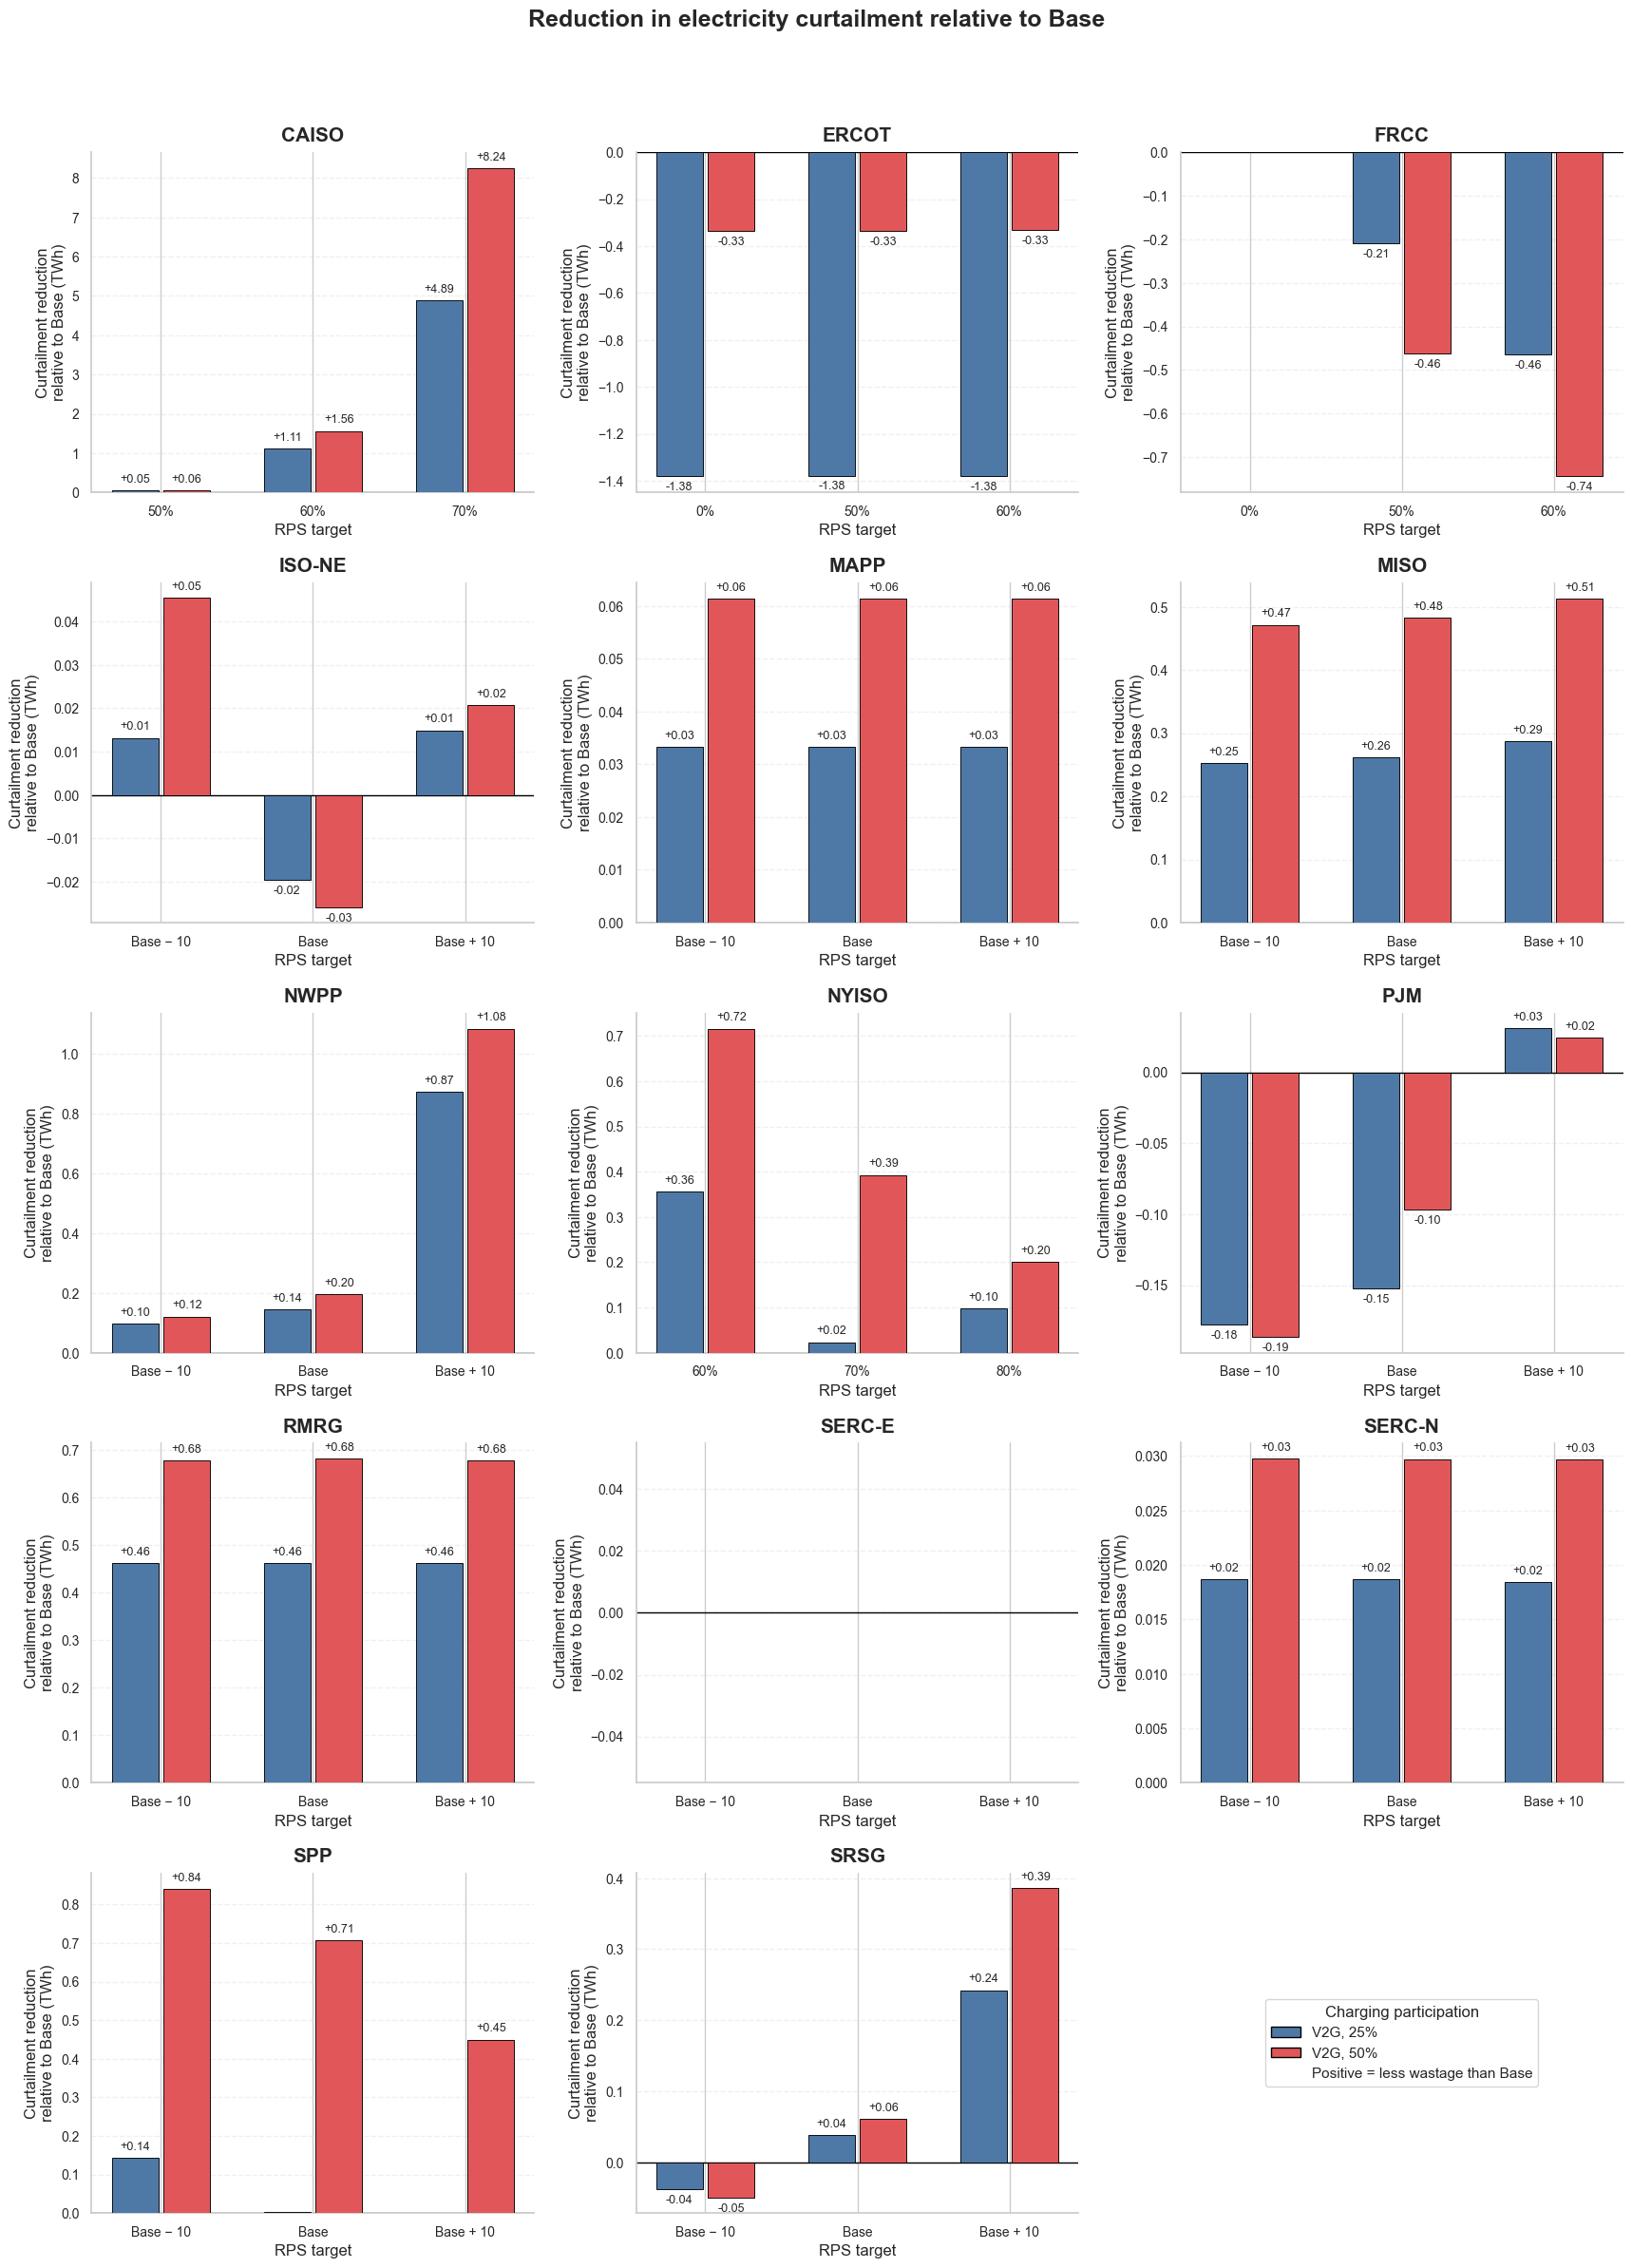

In [25]:
# =========================================================
# Regions
#
# Uncomment additional regions when ready.
# =========================================================

curtailment_regions = (
    "CAISO",
    "ERCOT",
    "FRCC",
    "ISO-NE",
    "MAPP",
    "MISO",
    "NWPP",
    "NYISO",
    "PJM",
    "RMRG",
    "SERC-E",
    "SERC-N",
    # "SERC-SE",
    "SPP",
    "SRSG",
)


# =========================================================
# Baseline charging scenarios
# =========================================================

curtailment_baseline_scenarios = {
    "CAISO": "midnight",
    "ERCOT": "arrive",
    "FRCC": "arrive",
    "ISO-NE": "arrive",
    "MAPP": "arrive",
    "MISO": "arrive",
    "NWPP": "arrive",
    "NYISO": "flex",
    "PJM": "arrive",
    "RMRG": "arrive",
    "SERC-E": "arrive",
    "SERC-N": "arrive",
    "SERC-SE": "arrive",
    "SPP": "arrive",
    "SRSG": "arrive",
}


# =========================================================
# Program charging scenarios
# =========================================================

curtailment_program_scenarios = {
    "CAISO": "delay",
    "ERCOT": "midnight",
    "FRCC": "delay",
    "ISO-NE": "delay",
    "MAPP": "midnight",
    "MISO": "midnight",
    "NWPP": "delay",
    "NYISO": "flex",
    "PJM": "delay",
    "RMRG": "delay",
    "SERC-E": "delay",
    "SERC-N": "midnight",
    "SERC-SE": "midnight",
    "SPP": "midnight",
    "SRSG": "delay",
}


# =========================================================
# RPS cases
# =========================================================

curtailment_rps_order = {
    "CAISO": [50, 60, 70],
    "ERCOT": [0, 50, 60],
    "FRCC": [0, 50, 60],
    "NYISO": [60, 70, 80],

    "ISO-NE": [-10, 0, 10],
    "MAPP": [-10, 0, 10],
    "MISO": [-10, 0, 10],
    "NWPP": [-10, 0, 10],
    "PJM": [-10, 0, 10],
    "RMRG": [-10, 0, 10],
    "SERC-E": [-10, 0, 10],
    "SERC-N": [-10, 0, 10],
    "SERC-SE": [-10, 0, 10],
    "SPP": [-10, 0, 10],
    "SRSG": [-10, 0, 10],
}


# =========================================================
# Panel titles
# =========================================================

curtailment_panel_titles = {
    "CAISO": "CAISO",
    "ERCOT": "ERCOT",
    "FRCC": "FRCC",
    "ISO-NE": "ISO-NE",
    "MAPP": "MAPP",
    "MISO": "MISO",
    "NWPP": "NWPP",
    "NYISO": "NYISO",
    "PJM": "PJM",
    "RMRG": "RMRG",
    "SERC-E": "SERC-E",
    "SERC-N": "SERC-N",
    "SERC-SE": "SERC-SE",
    "SPP": "SPP",
    "SRSG": "SRSG",
}


# =========================================================
# Cache and figure paths
# =========================================================

CURTAILMENT_CACHE_PATH = (
    PROJECT_ROOT
    / "plot_cache"
    / (
        "curtailment_delta_PJM_"
        "2030_mid_bcapex315_V2G.json"
    )
)

CURTAILMENT_FIGURE_PATH = (
    PROJECT_ROOT
    / "figures"
    / (
        "curtailment_reduction_PJM_"
        "V2G_mid_bcapex315.png"
    )
)


# =========================================================
# Plot
# =========================================================

df_curtailment, fig, axes = (
    plot_curtailment_delta_regions_by_rps_enhanced(
        output_root=OUTPUT_ROOT,

        regions=curtailment_regions,

        year=2030,
        adoption="mid",
        batt_capex_target=315,

        selected_group="V2G",

        selected_participation=(
            "25%",
            "50%",
        ),

        baseline_scenario_label_by_region=(
            curtailment_baseline_scenarios
        ),

        program_scenario_label_by_region=(
            curtailment_program_scenarios
        ),

        rps_order_by_region=(
            curtailment_rps_order
        ),

        panel_title_by_region=(
            curtailment_panel_titles
        ),

        model_days_per_run=360,
        time_step_h=1.0,

        participation_colors={
            "25%": "#4E79A7",
            "50%": "#E15759",
        },

        # Positive bars mean the program reduced wastage.
        plot_metric="curtailment_reduction_twh",

        # Do not label extremely small changes.
        label_threshold_twh=0.01,

        # Use None for automatic limits.
        y_limits_by_region=None,

        # Three-column dynamic layout.
        # The bottom-right cell is reserved for the legend.
        ncols=3,
        panel_width=5.8,
        panel_height=4.8,

        font_size=12,
        panel_title_fontsize=15,
        axis_label_fontsize=12,
        tick_label_fontsize=10,
        bar_label_fontsize=9,
        legend_fontsize=11,

        cache_path=CURTAILMENT_CACHE_PATH,

        # First run can use False because the cache does not
        # exist yet. Set True whenever scenario inputs change.
        refresh_cache=False,

        save_path=CURTAILMENT_FIGURE_PATH,
    )
)

plt.show()
plt.close(fig)

In [26]:
"""Stacked battery and transmission-loss plots for GOOD model results.

The module reads only the required columns from each ``*_solution.csv`` file:

* ``::charge`` and ``::discharge`` for storage losses;
* ``::transmission`` for transmission losses.

Battery loss is calculated as charging energy minus discharging energy. This
requires the annual storage boundary condition to be cyclic (final stored
energy equals initial stored energy), as in the user's GOOD runs.

Transmission loss is flow multiplied by ``1 - efficiency``. The efficiency is
read from the graph JSON when present. Otherwise, the caller must provide an
explicit regional fallback efficiency.
"""

from __future__ import annotations

import csv
import json
import math
import re
from pathlib import Path
from typing import Any, Mapping

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch


REGION_ALIASES = {
    "CA": "CAISO", "CAISO": "CAISO",
    "TX": "ERCOT", "ERCOT": "ERCOT",
    "FL": "FRCC", "FRCC": "FRCC",
    "NY": "NYISO", "NYISO": "NYISO",
    "PJM": "PJM", "MAPP": "MAPP", "MISO": "MISO",
    "ISO-NE": "ISO-NE", "ISO_NE": "ISO-NE", "ISONE": "ISO-NE",
    "NWPP": "NWPP", "RMRG": "RMRG",
    "SERC-E": "SERC-E", "SERC_E": "SERC-E",
    "SERC-N": "SERC-N", "SERC_N": "SERC-N",
    "SERC-SE": "SERC-SE", "SERC_SE": "SERC-SE",
    "SPP": "SPP", "SRSG": "SRSG",
}

RELATIVE_RPS_REGIONS = {
    "PJM", "MAPP", "MISO", "ISO-NE", "NWPP", "RMRG",
    "SERC-E", "SERC-N", "SERC-SE", "SPP", "SRSG",
}


def _normalize_region(region: str) -> str:
    key = str(region).strip().upper()
    if key not in REGION_ALIASES:
        raise ValueError(
            f"Unknown region {region!r}. Allowed values are "
            f"{sorted(REGION_ALIASES)}"
        )
    return REGION_ALIASES[key]


def _normalize_required_mapping(
    mapping: Mapping[str, Any] | None,
    regions: tuple[str, ...],
    name: str,
) -> dict[str, Any]:
    if mapping is None:
        raise ValueError(f"{name} cannot be None.")
    normalized = {_normalize_region(key): value for key, value in mapping.items()}
    missing = [region for region in regions if region not in normalized]
    if missing:
        raise ValueError(f"{name} is missing regions: {missing}")
    return {region: normalized[region] for region in regions}


def _get_results_dir(
    output_root: str | Path,
    region: str,
    year: int,
    adoption: str,
    scenario_label: str,
) -> Path:
    output_root = Path(output_root)
    region = _normalize_region(region)
    adoption = str(adoption).strip().lower()
    scenario_label = str(scenario_label).strip().lower()
    candidates = [
        output_root / region
        / f"scenario_results_{year}_{adoption}_{region}_{scenario_label}",
        output_root
        / f"scenario_results_{year}_{adoption}_{region}_{scenario_label}",
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "Could not find the selected result folder. Tried:\n"
        + "\n".join(str(path) for path in candidates)
    )


def _find_solution_csv(scenario_folder: str | Path) -> Path | None:
    scenario_folder = Path(scenario_folder)
    matches = sorted(scenario_folder.glob("*_solution.csv"))
    if not matches:
        matches = sorted(scenario_folder.rglob("*_solution.csv"))
    bad_words = ("old", "backup", "copy", "warm", "checkpoint", "debug")
    clean = [
        path for path in matches
        if not any(word in str(path).lower() for word in bad_words)
    ]
    matches = clean or matches
    if not matches:
        return None
    return sorted(matches, key=lambda path: (len(str(path)), str(path)))[0]


def _parse_case(path_or_folder: str | Path, region: str) -> dict[str, Any]:
    path = Path(path_or_folder)
    text = f"{path.parent.name}_{path.name}".lower()

    scenario_match = re.search(r"(?:^|_)s0*(\d+)_", text)
    scenario_id = int(scenario_match.group(1)) if scenario_match else None

    v1g_match = re.search(r"v1g(\d+)", text)
    v2g_match = re.search(r"v2g(\d+)", text)
    v1g = int(v1g_match.group(1)) if v1g_match else 0
    v2g = int(v2g_match.group(1)) if v2g_match else 0

    if v1g > 0 and v2g > 0:
        group = "V1G+V2G"
        participation = f"{v1g + v2g}%"
    elif v1g > 0:
        group = "V1G"
        participation = f"{v1g}%"
    elif v2g > 0:
        group = "V2G"
        participation = f"{v2g}%"
    else:
        group = "Base only"
        participation = "0%"

    if "rps_minus10" in text or "rpsminus10" in text:
        rps = -10
    elif "rps_base" in text or "rpsbase" in text:
        rps = 0
    elif "rps_plus10" in text or "rpsplus10" in text:
        rps = 10
    else:
        rps_match = re.search(r"rps(-?\d+)", text)
        rps = int(rps_match.group(1)) if rps_match else None

    batt_match = re.search(r"bcapex(\d+)", text)
    days_match = re.search(r"(?:^|_)d(\d+)(?:_|\.|$)", text)

    return {
        "region": _normalize_region(region),
        "scenario_id": scenario_id,
        "group": group,
        "participation": participation,
        "rps": rps,
        "batt_capex": int(batt_match.group(1)) if batt_match else None,
        "model_days": int(days_match.group(1)) if days_match else None,
    }


def _asset_prefix(column: str) -> str:
    return str(column).rsplit("::", 1)[0]


def _asset_handle(prefix: str) -> str:
    return str(prefix).split(":", 1)[1] if ":" in str(prefix) else str(prefix)


def _read_graph_metadata(graph_json_path: str | Path) -> dict[str, dict[str, Any]]:
    graph_json_path = Path(graph_json_path)
    with graph_json_path.open("r", encoding="utf-8") as handle:
        graph = json.load(handle)

    metadata: dict[str, dict[str, Any]] = {}
    for node in graph.get("nodes", []):
        node_id = str(node.get("id", ""))
        for asset_handle, asset in node.get("assets", {}).items():
            metadata[f"{node_id}:{asset_handle}"] = dict(asset)
    return metadata


def _read_graph_line_efficiencies(
    graph_json_path: str | Path,
) -> dict[str, float]:
    graph_json_path = Path(graph_json_path)
    with graph_json_path.open("r", encoding="utf-8") as handle:
        graph = json.load(handle)

    efficiencies: dict[str, float] = {}
    for edge in graph.get("edges", []):
        source = str(edge.get("source", ""))
        target = str(edge.get("target", ""))
        for line_handle, line in edge.get("lines", {}).items():
            efficiency = line.get("efficiency")
            if efficiency is None:
                efficiency = line.get("transmission_efficiency")
            if efficiency is None:
                continue
            efficiency = float(efficiency)
            efficiencies[str(line_handle)] = efficiency
            efficiencies[f"{source}:{target}:{line_handle}"] = efficiency
    return efficiencies


def _classify_storage(prefix: str, metadata: Mapping[str, Any] | None) -> str:
    metadata = metadata or {}
    text = " ".join([
        str(prefix),
        str(metadata.get("_class", "")),
        str(metadata.get("type", "")),
        str(metadata.get("fuel", "")),
        str(metadata.get("utility", "")),
    ]).lower()

    if "v2g" in text or "ev_v2g" in text:
        return "v2g"
    if "pump" in text and "hydro" in text:
        return "pumped_hydro"
    if "hydro" in text and "battery" not in text:
        return "pumped_hydro"
    if (
        "battery" in text
        or str(metadata.get("_class", "")).lower() == "store"
        or str(metadata.get("type", "")).lower() == "storage"
    ):
        return "stationary_battery"
    return "other_storage"


def _resolve_line_efficiency(
    transmission_prefix: str,
    graph_efficiencies: Mapping[str, float],
    explicit_line_efficiencies: Mapping[str, float] | None,
    fallback_efficiency: float | None,
) -> tuple[float, str]:
    line_handle = str(transmission_prefix).rsplit(":", 1)[-1]
    explicit_line_efficiencies = explicit_line_efficiencies or {}

    for key in (transmission_prefix, line_handle):
        if key in explicit_line_efficiencies:
            return float(explicit_line_efficiencies[key]), "explicit_line_map"
    for key in (transmission_prefix, line_handle):
        if key in graph_efficiencies:
            return float(graph_efficiencies[key]), "graph_json"
    if fallback_efficiency is not None:
        return float(fallback_efficiency), "regional_fallback"
    raise ValueError(
        "No efficiency was found for transmission column "
        f"{transmission_prefix!r}. Provide line_efficiency_by_region or "
        "transmission_efficiency_by_region, or use a graph JSON that contains "
        "the policy-enhanced line efficiencies."
    )


def read_energy_losses_from_solution_csv(
    solution_csv_path: str | Path,
    graph_json_path: str | Path,
    time_step_h: float = 1.0,
    transmission_efficiency: float | None = None,
    line_efficiency: Mapping[str, float] | None = None,
    include_v2g_in_battery: bool = True,
    include_pumped_hydro_in_battery: bool = False,
    chunksize: int = 2048,
) -> dict[str, Any]:
    """Read one solution CSV and calculate battery/transmission losses in TWh."""
    solution_csv_path = Path(solution_csv_path)
    asset_metadata = _read_graph_metadata(graph_json_path)
    graph_efficiencies = _read_graph_line_efficiencies(graph_json_path)

    with solution_csv_path.open("r", newline="", encoding="utf-8-sig") as handle:
        header = next(csv.reader(handle))

    charge_columns = [column for column in header if column.endswith("::charge")]
    discharge_columns = [
        column for column in header if column.endswith("::discharge")
    ]
    transmission_columns = [
        column for column in header if column.endswith("::transmission")
    ]

    charge_by_prefix = {_asset_prefix(column): column for column in charge_columns}
    discharge_by_prefix = {
        _asset_prefix(column): column for column in discharge_columns
    }
    storage_prefixes = sorted(set(charge_by_prefix) & set(discharge_by_prefix))

    if not storage_prefixes:
        raise ValueError(
            f"No paired ::charge and ::discharge columns were found in "
            f"{solution_csv_path}"
        )

    selected_columns = sorted(
        set(charge_columns + discharge_columns + transmission_columns)
    )
    column_sums = {column: 0.0 for column in selected_columns}

    reader = pd.read_csv(
        solution_csv_path,
        usecols=selected_columns,
        chunksize=int(chunksize),
    )
    for chunk in reader:
        numeric = chunk.apply(pd.to_numeric, errors="coerce").fillna(0.0)
        for column, value in numeric.sum(axis=0).items():
            column_sums[str(column)] += float(value) * float(time_step_h)

    storage_detail: dict[str, dict[str, Any]] = {}
    category_loss_wh = {
        "stationary_battery": 0.0,
        "v2g": 0.0,
        "pumped_hydro": 0.0,
        "other_storage": 0.0,
    }
    category_charge_wh = {key: 0.0 for key in category_loss_wh}
    category_discharge_wh = {key: 0.0 for key in category_loss_wh}

    for prefix in storage_prefixes:
        charge_wh = max(0.0, column_sums[charge_by_prefix[prefix]])
        discharge_wh = max(0.0, column_sums[discharge_by_prefix[prefix]])
        loss_wh = charge_wh - discharge_wh
        category = _classify_storage(prefix, asset_metadata.get(prefix))

        # Small negative values can arise from numerical tolerance. Large
        # negative values indicate a non-cyclic boundary or a classification/
        # output-definition problem and are retained for diagnosis.
        if abs(loss_wh) <= 1e-6 * max(charge_wh, discharge_wh, 1.0):
            loss_wh = 0.0

        category_charge_wh[category] += charge_wh
        category_discharge_wh[category] += discharge_wh
        category_loss_wh[category] += loss_wh
        storage_detail[prefix] = {
            "handle": _asset_handle(prefix),
            "category": category,
            "charge_twh": charge_wh / 1e12,
            "discharge_twh": discharge_wh / 1e12,
            "loss_twh": loss_wh / 1e12,
        }

    battery_categories = ["stationary_battery"]
    if include_v2g_in_battery:
        battery_categories.append("v2g")
    if include_pumped_hydro_in_battery:
        battery_categories.append("pumped_hydro")

    battery_charge_wh = sum(category_charge_wh[key] for key in battery_categories)
    battery_discharge_wh = sum(
        category_discharge_wh[key] for key in battery_categories
    )
    battery_loss_wh = sum(category_loss_wh[key] for key in battery_categories)
    battery_tolerance_wh = 1e-6 * max(
        battery_charge_wh, battery_discharge_wh, 1.0
    )
    if battery_loss_wh < -battery_tolerance_wh:
        raise ValueError(
            "Calculated battery loss is negative. This normally means that "
            "the final stored energy differs from the initial stored energy, "
            "or that the solution uses a different charge/discharge sign "
            f"definition. File: {solution_csv_path}"
        )

    transmission_loss_wh = 0.0
    transmission_throughput_wh = 0.0
    transmission_detail: dict[str, dict[str, Any]] = {}
    efficiency_sources: set[str] = set()

    for column in transmission_columns:
        prefix = _asset_prefix(column)
        flow_wh = max(0.0, column_sums[column])
        efficiency, efficiency_source = _resolve_line_efficiency(
            transmission_prefix=prefix,
            graph_efficiencies=graph_efficiencies,
            explicit_line_efficiencies=line_efficiency,
            fallback_efficiency=transmission_efficiency,
        )
        if not 0.0 < efficiency <= 1.0:
            raise ValueError(
                f"Transmission efficiency for {prefix} must be in (0, 1], "
                f"not {efficiency}."
            )
        loss_wh = flow_wh * (1.0 - efficiency)
        transmission_throughput_wh += flow_wh
        transmission_loss_wh += loss_wh
        efficiency_sources.add(efficiency_source)
        transmission_detail[prefix] = {
            "throughput_twh": flow_wh / 1e12,
            "efficiency": efficiency,
            "loss_twh": loss_wh / 1e12,
            "efficiency_source": efficiency_source,
        }

    if not transmission_columns:
        print(f"WARNING: no ::transmission columns found in {solution_csv_path}")

    return {
        "battery_charge_twh": battery_charge_wh / 1e12,
        "battery_discharge_twh": battery_discharge_wh / 1e12,
        "battery_loss_twh": battery_loss_wh / 1e12,
        "stationary_battery_loss_twh": (
            category_loss_wh["stationary_battery"] / 1e12
        ),
        "v2g_loss_twh": category_loss_wh["v2g"] / 1e12,
        "pumped_hydro_loss_twh": category_loss_wh["pumped_hydro"] / 1e12,
        "other_storage_loss_twh": category_loss_wh["other_storage"] / 1e12,
        "transmission_throughput_twh": transmission_throughput_wh / 1e12,
        "transmission_loss_twh": transmission_loss_wh / 1e12,
        "total_loss_twh": (battery_loss_wh + transmission_loss_wh) / 1e12,
        "storage_detail": storage_detail,
        "transmission_detail": transmission_detail,
        "transmission_efficiency_sources": sorted(efficiency_sources),
    }


def _collect_selected_loss_cases(
    output_root: str | Path,
    regions: tuple[str, ...],
    year: int,
    adoption: str,
    batt_capex_target: int,
    selected_group: str,
    selected_participation: tuple[str, ...],
    baseline_map: Mapping[str, str],
    program_map: Mapping[str, str],
    rps_map: Mapping[str, list[int]],
    graph_path_map: Mapping[str, str | Path],
    transmission_efficiency_map: Mapping[str, float | None],
    line_efficiency_map: Mapping[str, Mapping[str, float]],
    model_days_per_run: int,
    time_step_h: float,
    include_v2g_in_battery: bool,
    include_pumped_hydro_in_battery: bool,
) -> pd.DataFrame:
    records: list[dict[str, Any]] = []

    for region in regions:
        searches = [
            ("baseline", baseline_map[region], "Base only", {"0%"}),
            (
                "program", program_map[region], selected_group,
                set(selected_participation),
            ),
        ]

        for case_type, scenario_label, wanted_group, wanted_participation in searches:
            results_dir = _get_results_dir(
                output_root, region, year, adoption, scenario_label
            )
            for scenario_folder in sorted(results_dir.glob("s*")):
                if not scenario_folder.is_dir():
                    continue
                solution_csv = _find_solution_csv(scenario_folder)
                if solution_csv is None:
                    continue
                meta = _parse_case(solution_csv, region)
                if meta["batt_capex"] != int(batt_capex_target):
                    continue
                if meta["model_days"] != int(model_days_per_run):
                    continue
                if meta["rps"] not in set(rps_map[region]):
                    continue
                if meta["group"] != wanted_group:
                    continue
                if meta["participation"] not in wanted_participation:
                    continue

                losses = read_energy_losses_from_solution_csv(
                    solution_csv_path=solution_csv,
                    graph_json_path=graph_path_map[region],
                    time_step_h=time_step_h,
                    transmission_efficiency=transmission_efficiency_map[region],
                    line_efficiency=line_efficiency_map.get(region, {}),
                    include_v2g_in_battery=include_v2g_in_battery,
                    include_pumped_hydro_in_battery=include_pumped_hydro_in_battery,
                )
                records.append({
                    **meta,
                    **losses,
                    "case_type": case_type,
                    "scenario_label": str(scenario_label).lower(),
                    "scenario_folder": str(scenario_folder),
                    "solution_csv_path": str(solution_csv),
                })

    if not records:
        raise ValueError("No selected battery/transmission-loss cases were found.")

    raw = pd.DataFrame(records)
    duplicate_keys = ["case_type", "region", "rps", "group", "participation"]
    raw["_scenario_sort"] = raw["scenario_id"].fillna(10**9)
    raw = (
        raw.sort_values(duplicate_keys + ["_scenario_sort", "solution_csv_path"])
        .drop_duplicates(duplicate_keys, keep="first")
        .drop(columns="_scenario_sort")
        .reset_index(drop=True)
    )

    metrics = [
        "battery_charge_twh", "battery_discharge_twh", "battery_loss_twh",
        "stationary_battery_loss_twh", "v2g_loss_twh",
        "pumped_hydro_loss_twh", "other_storage_loss_twh",
        "transmission_throughput_twh", "transmission_loss_twh",
        "total_loss_twh",
    ]
    base = raw[raw["case_type"] == "baseline"].copy()
    program = raw[raw["case_type"] == "program"].copy()

    base_keep = ["region", "rps"] + metrics
    base = base[base_keep].rename(
        columns={metric: f"baseline_{metric}" for metric in metrics}
    )
    program_keep = [
        "region", "rps", "group", "participation", "scenario_id",
        "batt_capex", "model_days", "scenario_label", "scenario_folder",
        "solution_csv_path",
    ] + metrics
    out = program[program_keep].merge(
        base, on=["region", "rps"], how="left", validate="many_to_one"
    )
    out = out.rename(
        columns={metric: f"program_{metric}" for metric in metrics}
    )

    if out["baseline_total_loss_twh"].isna().any():
        missing = out.loc[
            out["baseline_total_loss_twh"].isna(),
            ["region", "rps", "group", "participation"],
        ]
        raise ValueError(
            "Program loss cases are missing matching baselines:\n"
            + missing.to_string(index=False)
        )

    for component in ("battery_loss_twh", "transmission_loss_twh", "total_loss_twh"):
        out[f"{component.removesuffix('_twh')}_change_twh"] = (
            out[f"program_{component}"] - out[f"baseline_{component}"]
        )
        out[f"{component.removesuffix('_twh')}_reduction_twh"] = (
            out[f"baseline_{component}"] - out[f"program_{component}"]
        )

    expected = {
        (region, rps, selected_group, participation)
        for region in regions
        for rps in rps_map[region]
        for participation in selected_participation
    }
    actual = set(
        out[["region", "rps", "group", "participation"]]
        .itertuples(index=False, name=None)
    )
    missing = sorted(expected - actual)
    if missing:
        raise ValueError(
            "Selected loss coverage is incomplete. Missing:\n"
            + "\n".join(map(str, missing))
        )

    return out.sort_values(["region", "rps", "participation"]).reset_index(
        drop=True
    )


def _rps_tick_labels(region: str, rps_order: list[int]) -> list[str]:
    if region in RELATIVE_RPS_REGIONS:
        labels = []
        for value in rps_order:
            if value == -10:
                labels.append("Base − 10")
            elif value == 0:
                labels.append("Base")
            elif value == 10:
                labels.append("Base + 10")
            else:
                labels.append(f"Base {int(value):+d}")
        return labels
    return [f"{int(value)}%" for value in rps_order]


def _plot_signed_stack(
    ax,
    x: float,
    width: float,
    values: list[float],
    colors: list[str],
    edgecolor: str,
    linewidth: float,
) -> None:
    positive_bottom = 0.0
    negative_bottom = 0.0
    for value, color in zip(values, colors):
        if value >= 0:
            bottom = positive_bottom
            positive_bottom += value
        else:
            bottom = negative_bottom
            negative_bottom += value
        ax.bar(
            x, value, width=width, bottom=bottom,
            color=color, edgecolor=edgecolor, linewidth=linewidth, zorder=3,
        )


def plot_stacked_energy_losses_regions_by_rps(
    output_root: str | Path,
    regions: tuple[str, ...],
    graph_json_path_by_region: Mapping[str, str | Path],
    year: int = 2030,
    adoption: str = "mid",
    batt_capex_target: int = 315,
    selected_group: str = "V2G",
    selected_participation: tuple[str, ...] = ("25%", "50%"),
    baseline_scenario_label_by_region: Mapping[str, str] | None = None,
    program_scenario_label_by_region: Mapping[str, str] | None = None,
    rps_order_by_region: Mapping[str, list[int]] | None = None,
    panel_title_by_region: Mapping[str, str] | None = None,
    transmission_efficiency_by_region: Mapping[str, float | None] | None = None,
    line_efficiency_by_region: Mapping[str, Mapping[str, float]] | None = None,
    model_days_per_run: int = 360,
    time_step_h: float = 1.0,
    include_v2g_in_battery: bool = True,
    include_pumped_hydro_in_battery: bool = False,
    plot_mode: str = "total",
    component_colors: Mapping[str, str] | None = None,
    label_threshold_twh: float = 0.01,
    y_limits_by_region: Mapping[str, tuple[float, float]] | None = None,
    ncols: int = 3,
    panel_width: float = 5.8,
    panel_height: float = 4.8,
    font_size: int = 12,
    panel_title_fontsize: int = 15,
    axis_label_fontsize: int = 12,
    tick_label_fontsize: int = 10,
    bar_label_fontsize: int = 9,
    legend_fontsize: int = 11,
    cache_path: str | Path | None = None,
    refresh_cache: bool = False,
    save_path: str | Path | None = None,
):
    """Plot stacked battery and transmission losses for selected GOOD cases.

    ``plot_mode='total'`` plots program-case absolute losses.
    ``plot_mode='reduction'`` plots Base minus program losses.
    ``plot_mode='change'`` plots program minus Base losses.
    """
    regions = tuple(_normalize_region(region) for region in regions)
    if not regions:
        raise ValueError("regions cannot be empty.")
    if len(regions) != len(set(regions)):
        raise ValueError(f"Duplicate regions after normalization: {regions}")

    selected_group = str(selected_group).strip().upper()
    if selected_group not in {"V1G", "V2G"}:
        raise ValueError("selected_group must be 'V1G' or 'V2G'.")
    selected_participation = tuple(str(value) for value in selected_participation)

    plot_mode = str(plot_mode).strip().lower()
    if plot_mode not in {"total", "reduction", "change"}:
        raise ValueError("plot_mode must be 'total', 'reduction', or 'change'.")

    baseline_map = _normalize_required_mapping(
        baseline_scenario_label_by_region, regions,
        "baseline_scenario_label_by_region",
    )
    program_map = _normalize_required_mapping(
        program_scenario_label_by_region, regions,
        "program_scenario_label_by_region",
    )
    rps_map = _normalize_required_mapping(
        rps_order_by_region, regions, "rps_order_by_region"
    )
    rps_map = {region: list(rps_map[region]) for region in regions}
    graph_path_map = _normalize_required_mapping(
        graph_json_path_by_region, regions, "graph_json_path_by_region"
    )
    graph_path_map = {region: Path(graph_path_map[region]) for region in regions}
    missing_graphs = [
        str(path) for path in graph_path_map.values() if not Path(path).exists()
    ]
    if missing_graphs:
        raise FileNotFoundError("Missing graph JSON files:\n" + "\n".join(missing_graphs))

    if panel_title_by_region is None:
        title_map = {region: region for region in regions}
    else:
        title_map = _normalize_required_mapping(
            panel_title_by_region, regions, "panel_title_by_region"
        )

    if transmission_efficiency_by_region is None:
        transmission_efficiency_map = {region: None for region in regions}
    else:
        normalized_efficiency = {
            _normalize_region(key): value
            for key, value in transmission_efficiency_by_region.items()
        }
        transmission_efficiency_map = {
            region: (
                None if normalized_efficiency.get(region) is None
                else float(normalized_efficiency[region])
            )
            for region in regions
        }

    line_efficiency_by_region = line_efficiency_by_region or {}
    normalized_line_efficiency = {
        _normalize_region(key): value
        for key, value in line_efficiency_by_region.items()
    }
    line_efficiency_map = {
        region: dict(normalized_line_efficiency.get(region, {}))
        for region in regions
    }

    if component_colors is None:
        component_colors = {
            "Battery loss": "#E15759",
            "Transmission loss": "#4E79A7",
        }
    component_names = ["Battery loss", "Transmission loss"]
    missing_colors = [name for name in component_names if name not in component_colors]
    if missing_colors:
        raise ValueError(f"component_colors is missing: {missing_colors}")

    metadata = {
        "cache_version": 1,
        "cache_type": "battery_and_transmission_loss",
        "regions": list(regions),
        "year": int(year),
        "adoption": str(adoption).lower(),
        "batt_capex_target": int(batt_capex_target),
        "selected_group": selected_group,
        "selected_participation": list(selected_participation),
        "baseline_map": baseline_map,
        "program_map": program_map,
        "rps_map": rps_map,
        "graph_path_map": {key: str(value.resolve()) for key, value in graph_path_map.items()},
        "transmission_efficiency_map": transmission_efficiency_map,
        "line_efficiency_map": line_efficiency_map,
        "model_days_per_run": int(model_days_per_run),
        "time_step_h": float(time_step_h),
        "include_v2g_in_battery": bool(include_v2g_in_battery),
        "include_pumped_hydro_in_battery": bool(include_pumped_hydro_in_battery),
    }

    cache_path = Path(cache_path) if cache_path is not None else None
    if cache_path is not None and cache_path.exists() and not refresh_cache:
        with cache_path.open("r", encoding="utf-8") as handle:
            payload = json.load(handle)
        if payload.get("metadata") != metadata:
            raise ValueError(
                "Energy-loss cache settings do not match this request. "
                "Run once with refresh_cache=True."
            )
        df = pd.DataFrame(payload.get("records", []))
        print(f"Loaded energy-loss cache: {cache_path}")
    else:
        df = _collect_selected_loss_cases(
            output_root=output_root,
            regions=regions,
            year=year,
            adoption=adoption,
            batt_capex_target=batt_capex_target,
            selected_group=selected_group,
            selected_participation=selected_participation,
            baseline_map=baseline_map,
            program_map=program_map,
            rps_map=rps_map,
            graph_path_map=graph_path_map,
            transmission_efficiency_map=transmission_efficiency_map,
            line_efficiency_map=line_efficiency_map,
            model_days_per_run=model_days_per_run,
            time_step_h=time_step_h,
            include_v2g_in_battery=include_v2g_in_battery,
            include_pumped_hydro_in_battery=include_pumped_hydro_in_battery,
        )
        if cache_path is not None:
            cache_path.parent.mkdir(parents=True, exist_ok=True)
            records = json.loads(df.to_json(orient="records"))
            with cache_path.open("w", encoding="utf-8") as handle:
                json.dump({"metadata": metadata, "records": records}, handle, indent=2)
            print(f"Saved energy-loss cache: {cache_path}")

    if plot_mode == "total":
        component_columns = [
            "program_battery_loss_twh", "program_transmission_loss_twh"
        ]
        ylabel = "Annual energy loss (TWh)"
        figure_title = "Battery and transmission energy losses"
        interpretation = "Stack height = total program-case energy loss"
    elif plot_mode == "reduction":
        component_columns = [
            "battery_loss_reduction_twh", "transmission_loss_reduction_twh"
        ]
        ylabel = "Loss reduction relative to Base (TWh)"
        figure_title = "Reduction in energy losses relative to Base"
        interpretation = "Positive = lower loss than Base"
    else:
        component_columns = [
            "battery_loss_change_twh", "transmission_loss_change_twh"
        ]
        ylabel = "Change in loss relative to Base (TWh)"
        figure_title = "Change in energy losses relative to Base"
        interpretation = "Positive = higher loss than Base"

    required = set(component_columns) | {"region", "rps", "participation"}
    missing_columns = sorted(required - set(df.columns))
    if missing_columns:
        raise ValueError(f"Energy-loss data/cache is missing columns: {missing_columns}")

    ncols = int(ncols)
    if ncols < 1:
        raise ValueError("ncols must be at least 1.")
    nrows = math.ceil((len(regions) + 1) / ncols)
    fig, axes_grid = plt.subplots(
        nrows, ncols,
        figsize=(panel_width * ncols, panel_height * nrows),
        squeeze=False, facecolor="white",
    )
    axes = axes_grid.flatten()
    legend_index = len(axes) - 1
    normalized_limits = (
        {_normalize_region(key): value for key, value in y_limits_by_region.items()}
        if y_limits_by_region is not None else {}
    )

    for panel_index, region in enumerate(regions):
        ax = axes[panel_index]
        sub = df[df["region"] == region].copy()
        rps_order = list(rps_map[region])
        centers = np.arange(len(rps_order), dtype=float)
        n_part = len(selected_participation)
        width = min(0.34, 0.78 / max(1, n_part))

        ax.axhline(0.0, color="black", linewidth=1.0, zorder=1)
        for part_index, participation in enumerate(selected_participation):
            offset = (part_index - (n_part - 1) / 2.0) * width
            for rps_index, rps in enumerate(rps_order):
                match = sub[
                    (sub["rps"] == rps)
                    & (sub["participation"] == participation)
                ]
                if match.empty:
                    continue
                values = [float(match.iloc[0][column]) for column in component_columns]
                x = centers[rps_index] + offset
                _plot_signed_stack(
                    ax=ax,
                    x=x,
                    width=width * 0.90,
                    values=values,
                    colors=[component_colors[name] for name in component_names],
                    edgecolor="black",
                    linewidth=0.65,
                )
                total = sum(values)
                if abs(total) >= float(label_threshold_twh):
                    positive_total = sum(value for value in values if value > 0)
                    negative_total = sum(value for value in values if value < 0)
                    y = positive_total if total >= 0 else negative_total
                    ax.annotate(
                        f"{total:+.2f}" if plot_mode != "total" else f"{total:.2f}",
                        (x, y),
                        xytext=(0, 4 if total >= 0 else -4),
                        textcoords="offset points",
                        ha="center",
                        va="bottom" if total >= 0 else "top",
                        fontsize=bar_label_fontsize,
                        fontweight="bold",
                    )

        ax.set_title(
            str(title_map[region]), fontsize=panel_title_fontsize,
            fontweight="bold", pad=8,
        )
        ax.set_xticks(centers)
        ax.set_xticklabels(
            _rps_tick_labels(region, rps_order), fontsize=tick_label_fontsize
        )
        participation_positions = []
        participation_labels = []
        for rps_index, _ in enumerate(rps_order):
            for part_index, participation in enumerate(selected_participation):
                offset = (part_index - (n_part - 1) / 2.0) * width
                participation_positions.append(centers[rps_index] + offset)
                participation_labels.append(participation)
        ax.set_xticks(participation_positions, minor=True)
        ax.set_xticklabels(
            participation_labels,
            minor=True,
            fontsize=max(7, tick_label_fontsize - 1),
            fontweight="bold",
        )
        ax.tick_params(axis="x", which="minor", length=0, pad=2)
        ax.tick_params(axis="x", which="major", length=0, pad=22)
        ax.set_xlabel("RPS target", fontsize=axis_label_fontsize)
        ax.set_ylabel(ylabel, fontsize=axis_label_fontsize)
        ax.tick_params(axis="y", labelsize=tick_label_fontsize)
        ax.grid(axis="y", linestyle="--", alpha=0.30, zorder=0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        if region in normalized_limits:
            ax.set_ylim(*normalized_limits[region])

    for index, ax in enumerate(axes):
        if index >= len(regions) and index != legend_index:
            ax.axis("off")

    legend_ax = axes[legend_index]
    legend_ax.axis("off")
    handles = [
        Patch(
            facecolor=component_colors[name], edgecolor="black", label=name
        )
        for name in component_names
    ]
    participation_text = ", ".join(
        f"{selected_group} {participation}"
        for participation in selected_participation
    )
    handles.extend([
        Patch(facecolor="white", edgecolor="none", label=participation_text),
        Patch(facecolor="white", edgecolor="none", label=interpretation),
    ])
    legend_ax.legend(
        handles=handles,
        loc="center",
        frameon=True,
        fontsize=legend_fontsize,
        title="Loss components",
        title_fontsize=legend_fontsize + 1,
    )

    fig.suptitle(figure_title, fontsize=font_size + 6, fontweight="bold", y=0.995)
    # Extra bottom margin is required for the two-level x-axis labels
    # (participation percentages above the RPS labels).
    fig.tight_layout(rect=[0, 0.06, 1, 0.97])

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved energy-loss figure: {save_path}")

    return df, fig, axes_grid


Saved energy-loss cache: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL/plot_cache/energy_losses_PJM_2030_mid_bcapex315_V2G.json
Saved energy-loss figure: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL/figures/stacked_energy_losses_PJM_V2G_mid_bcapex315.png


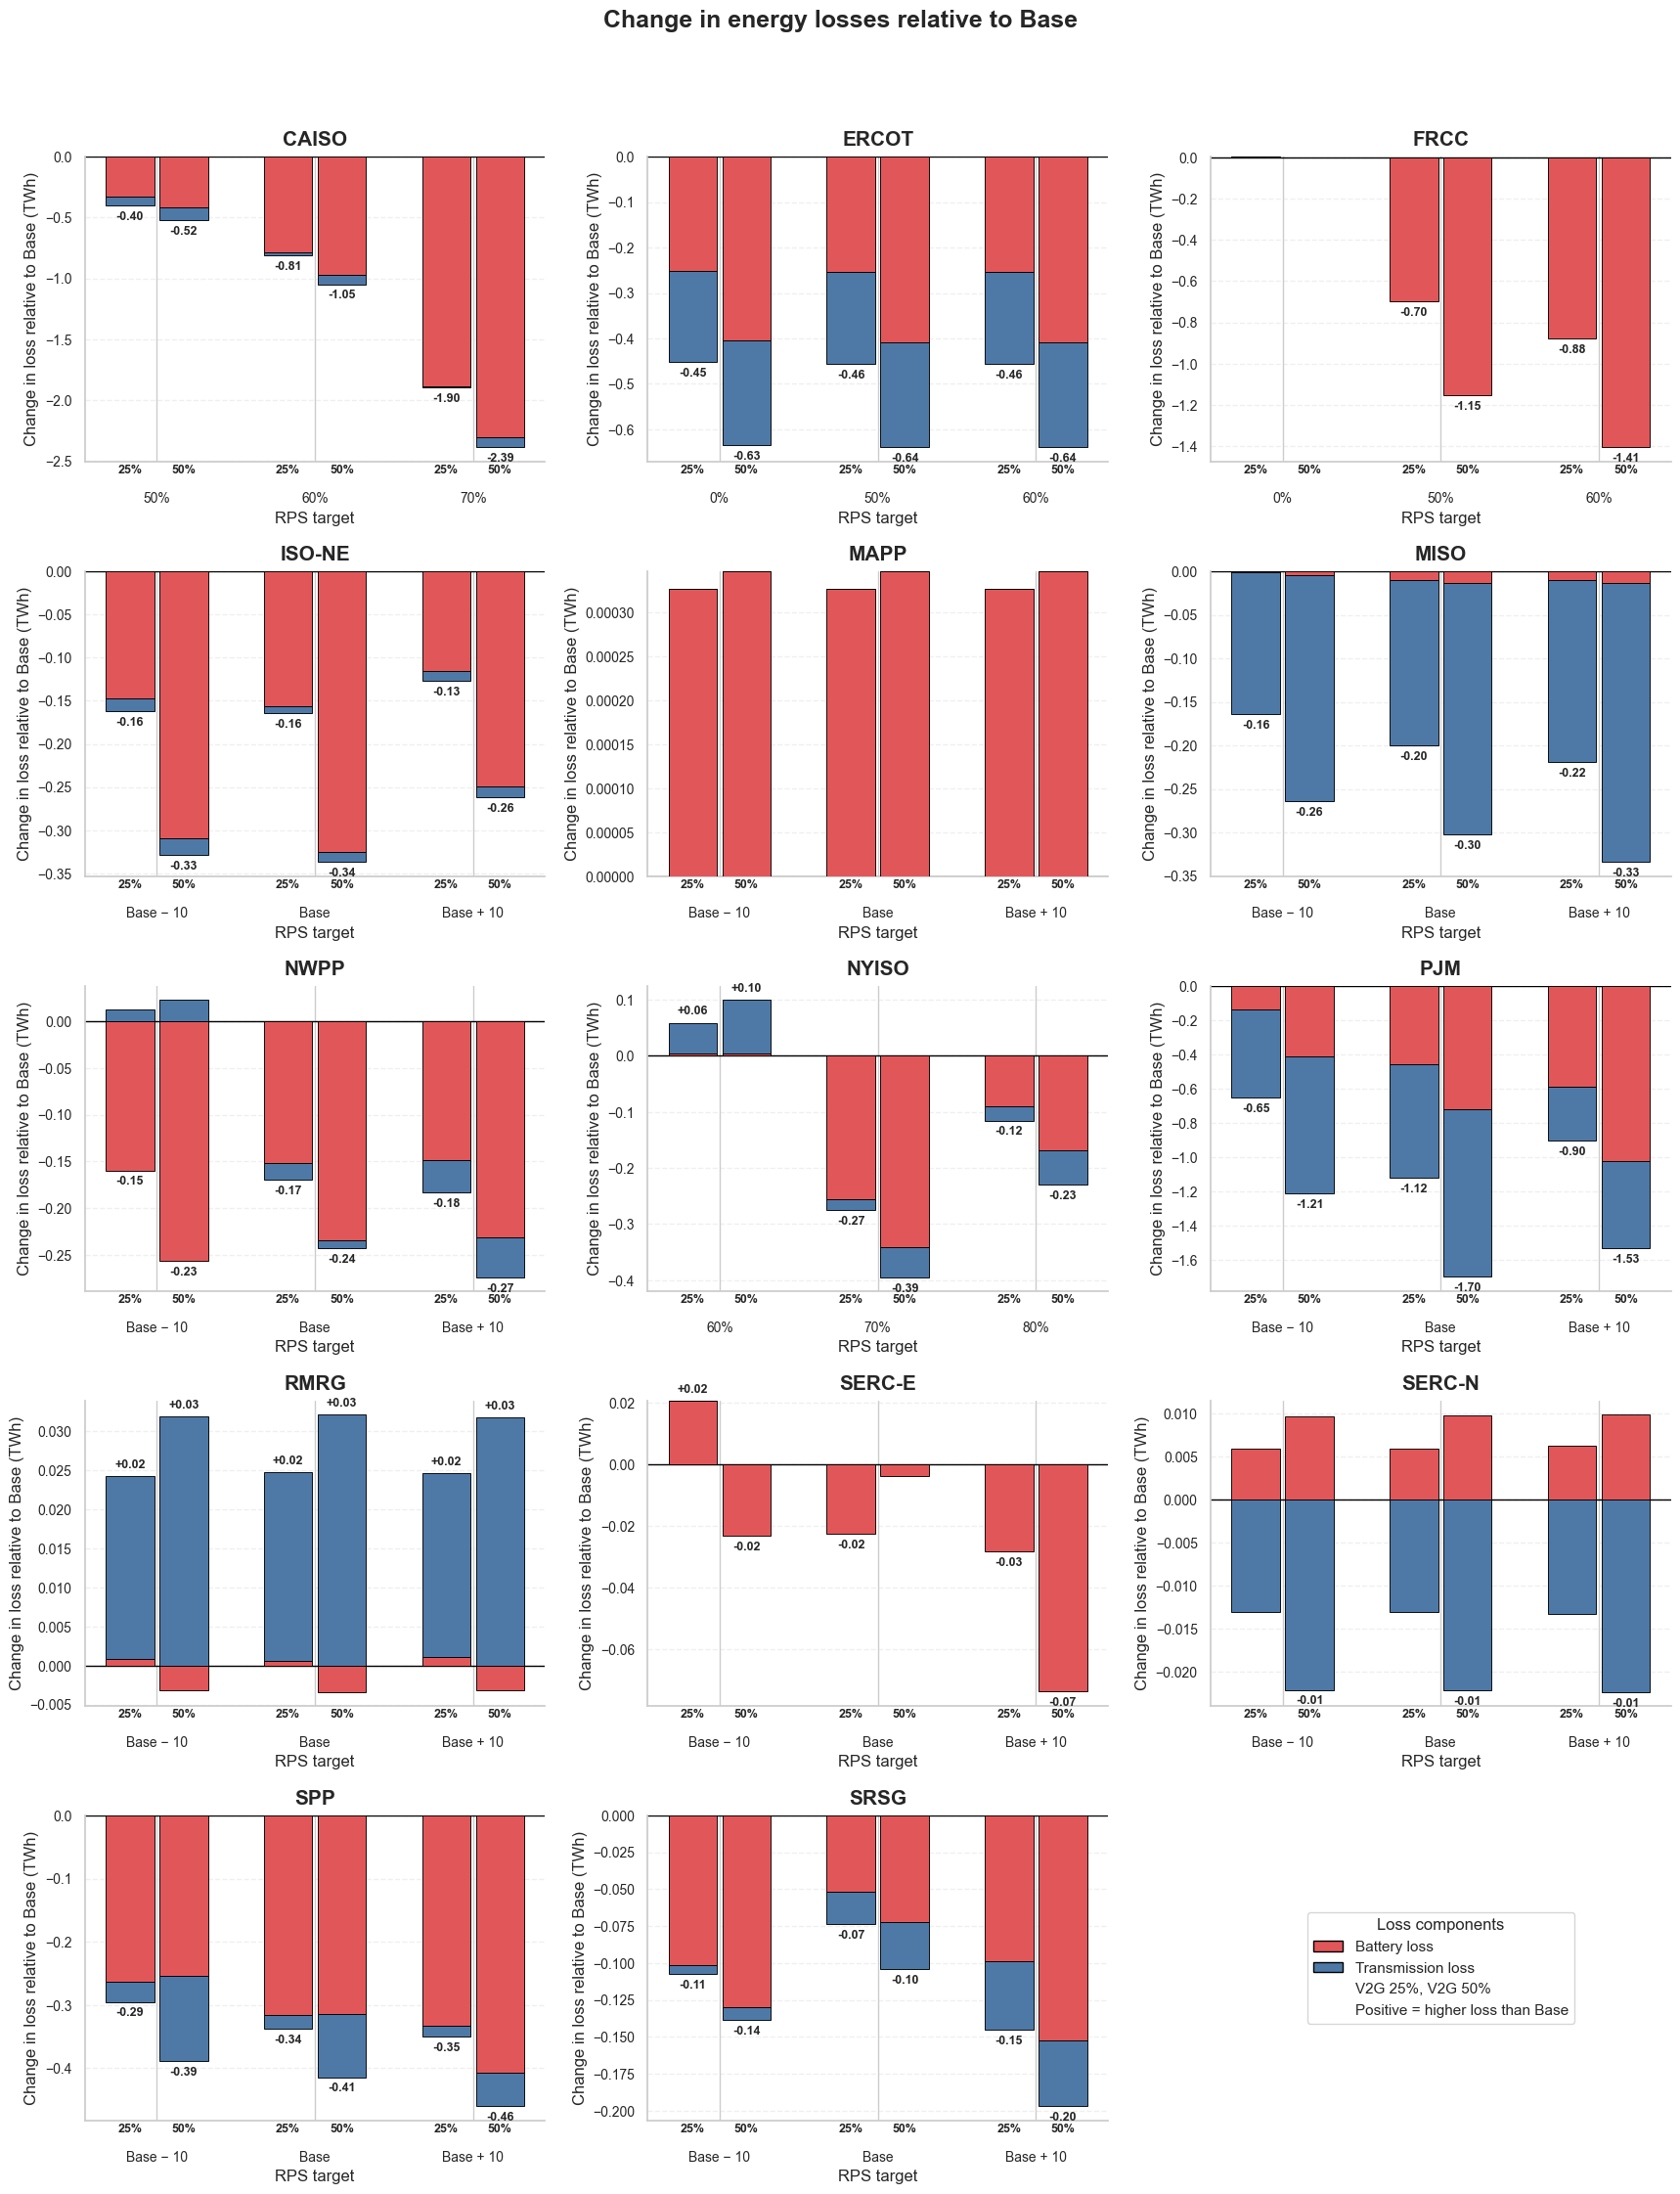

In [27]:

# =========================================================
# Regions
# =========================================================

loss_regions = (
    "CAISO",
    "ERCOT",
    "FRCC",
    "ISO-NE",
    "MAPP",
    "MISO",
    "NWPP",
    "NYISO",
    "PJM",
    "RMRG",
    "SERC-E",
    "SERC-N",
    # "SERC-SE",
    "SPP",
    "SRSG",
)


# =========================================================
# Graph paths
# =========================================================

loss_graph_paths = {
    "PJM": (
        PROJECT_ROOT
        / "Examples"
        / "Nodes"
        / "PJM_IPM.json"
    ),
}


# =========================================================
# Scenario settings
# =========================================================
loss_baseline_scenarios = {
    "CAISO": "midnight",
    "ERCOT": "arrive",
    "FRCC": "arrive",
    "ISO-NE": "arrive",
    "MAPP": "arrive",
    "MISO": "arrive",
    "NWPP": "arrive",
    "NYISO": "flex",
    "PJM": "arrive",
    "RMRG": "arrive",
    "SERC-E": "arrive",
    "SERC-N": "arrive",
    # "SERC-SE": "arrive",
    "SPP": "arrive",
    "SRSG": "arrive",
}

loss_graph_paths = {
    "CAISO": PROJECT_ROOT / "Examples" / "Nodes" / "California_IPM.json",
    "ERCOT": PROJECT_ROOT / "Examples" / "Nodes" / "Texas_IPM.json",
    "FRCC": PROJECT_ROOT / "Examples" / "Nodes" / "Florida_IPM.json",
    "ISO-NE": PROJECT_ROOT / "Examples" / "Nodes" / "ISO-NE_IPM.json",
    "MAPP": PROJECT_ROOT / "Examples" / "Nodes" / "MAPP_IPM.json",
    "MISO": PROJECT_ROOT / "Examples" / "Nodes" / "MISO_IPM.json",
    "NWPP": PROJECT_ROOT / "Examples" / "Nodes" / "NWPP_IPM.json",
    "NYISO": PROJECT_ROOT / "Examples" / "Nodes" / "New_York_IPM.json",
    "PJM": PROJECT_ROOT / "Examples" / "Nodes" / "PJM_IPM.json",
    "RMRG": PROJECT_ROOT / "Examples" / "Nodes" / "RMRG_IPM.json",
    "SERC-E": PROJECT_ROOT / "Examples" / "Nodes" / "SERC-E_IPM.json",
    "SERC-N": PROJECT_ROOT / "Examples" / "Nodes" / "SERC-N_IPM.json",
    "SPP": PROJECT_ROOT / "Examples" / "Nodes" / "SPP_IPM.json",
    "SRSG": PROJECT_ROOT / "Examples" / "Nodes" / "SRSG_IPM.json",
}
# =========================================================
# Program charging scenarios
# =========================================================

loss_program_scenarios = {
    "CAISO": "delay",
    "ERCOT": "midnight",
    "FRCC": "delay",
    "ISO-NE": "delay",
    "MAPP": "midnight",
    "MISO": "midnight",
    "NWPP": "delay",
    "NYISO": "flex",
    "PJM": "delay",
    "RMRG": "delay",
    "SERC-E": "delay",
    "SERC-N": "midnight",
    # "SERC-SE": "midnight",
    "SPP": "midnight",
    "SRSG": "delay",
}
loss_rps_order = {
    "CAISO": [50, 60, 70],
    "ERCOT": [0, 50, 60],
    "FRCC": [0, 50, 60],
    "NYISO": [60, 70, 80],
    "ISO-NE": [-10, 0, 10],
    "MAPP": [-10, 0, 10],
    "MISO": [-10, 0, 10],
    "NWPP": [-10, 0, 10],
    "PJM": [-10, 0, 10],
    "RMRG": [-10, 0, 10],
    "SERC-E": [-10, 0, 10],
    "SERC-N": [-10, 0, 10],
    # "SERC-SE": [-10, 0, 10],
    "SPP": [-10, 0, 10],
    "SRSG": [-10, 0, 10],
}


# =========================================================
# Panel titles
# =========================================================

loss_panel_titles = {
    "CAISO": "CAISO",
    "ERCOT": "ERCOT",
    "FRCC": "FRCC",
    "ISO-NE": "ISO-NE",
    "MAPP": "MAPP",
    "MISO": "MISO",
    "NWPP": "NWPP",
    "NYISO": "NYISO",
    "PJM": "PJM",
    "RMRG": "RMRG",
    "SERC-E": "SERC-E",
    "SERC-N": "SERC-N",
    # "SERC-SE": "SERC-SE",
    "SPP": "SPP",
    "SRSG": "SRSG",
}


# =========================================================
# Transmission efficiency
#
# Graph-specific efficiencies are used first when available.
# The 0.90 value is the fallback from your transmission policy.
# =========================================================

loss_transmission_efficiency = {
     "CAISO": 0.90,
    "ERCOT": 0.90,
    "FRCC": 0.90,
    "ISO-NE": 0.90,
    "MAPP": 0.90,
    "MISO": 0.90,
    "NWPP": 0.90,
    "NYISO": 0.90,
    "PJM": 0.90,
    "RMRG": 0.90,
    "SERC-E": 0.90,
    "SERC-N": 0.90,
    "SERC-SE": 0.90,
    "SPP": 0.90,
    "SRSG": 0.90,
}


# =========================================================
# Cache and figure paths
# =========================================================

ENERGY_LOSS_CACHE_PATH = (
    PROJECT_ROOT
    / "plot_cache"
    / "energy_losses_PJM_2030_mid_bcapex315_V2G.json"
)

ENERGY_LOSS_FIGURE_PATH = (
    PROJECT_ROOT
    / "figures"
    / "stacked_energy_losses_PJM_"
      "V2G_mid_bcapex315.png"
)


# =========================================================
# Draw stacked loss figure
# =========================================================

df_energy_loss, fig, axes = (
    plot_stacked_energy_losses_regions_by_rps(
        output_root=OUTPUT_ROOT,

        regions=loss_regions,

        graph_json_path_by_region=(
            loss_graph_paths
        ),

        year=2030,
        adoption="mid",
        batt_capex_target=315,

        selected_group="V2G",

        selected_participation=(
            "25%",
            "50%",
        ),

        baseline_scenario_label_by_region=(
            loss_baseline_scenarios
        ),

        program_scenario_label_by_region=(
            loss_program_scenarios
        ),

        rps_order_by_region=(
            loss_rps_order
        ),

        panel_title_by_region=(
            loss_panel_titles
        ),

        transmission_efficiency_by_region=(
            loss_transmission_efficiency
        ),

        # V2G and stationary battery losses are combined
        # into the battery portion of each stacked bar.
        include_v2g_in_battery=True,

        # Pumped-hydro losses remain separate and are not
        # included in the displayed battery component.
        include_pumped_hydro_in_battery=False,

        model_days_per_run=360,
        time_step_h=1.0,

        # "total":
        #   absolute program battery + transmission losses
        #
        # "reduction":
        #   Base loss minus program loss
        #
        # "change":
        #   program loss minus Base loss
        plot_mode="change",

        component_colors={
            "Battery loss": "#E15759",
            "Transmission loss": "#4E79A7",
        },

        label_threshold_twh=0.01,

        ncols=3,
        panel_width=5.8,
        panel_height=4.8,

        font_size=12,
        panel_title_fontsize=15,
        axis_label_fontsize=12,
        tick_label_fontsize=10,
        bar_label_fontsize=9,
        legend_fontsize=11,

        cache_path=(
            ENERGY_LOSS_CACHE_PATH
        ),

        # Use True for the first run.
        # Change to False after creating the cache.
        refresh_cache=True,

        save_path=(
            ENERGY_LOSS_FIGURE_PATH
        ),
    )
)

plt.show()
plt.close(fig)

In [6]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd


# =========================================================
# Basic helpers
# =========================================================

def classify_dynamic_asset(prefix):
    """
    Classify assets that were added after the original source graph
    was created.
    """

    node_id, asset_handle = prefix.split(":", 1)
    handle = asset_handle.lower()

    # External imports added after graph aggregation.
    if handle.startswith("installed_import_"):
        return {
            "_node_id": node_id,
            "_asset_handle": asset_handle,
            "_class": "Producer",
            "type": "generator",
            "fuel": "import",
            "renewable": False,
            "rps_eligible": False,
            "dispatchable": True,
            "extensible": False,
        }

    # EV and base-load assets added dynamically.
    if (
        handle.startswith("ev_load_")
        or handle.startswith("base_load_")
    ):
        return {
            "_node_id": node_id,
            "_asset_handle": asset_handle,
            "_class": "Load",
            "type": "load",
            "fuel": None,
            "renewable": False,
            "rps_eligible": False,
        }

    # Battery and V2G assets added dynamically.
    if (
        handle.startswith("battery_")
        or "v2g" in handle
        or handle.startswith("ev_storage_")
    ):
        return {
            "_node_id": node_id,
            "_asset_handle": asset_handle,
            "_class": "Store",
            "type": "storage",
            "fuel": "battery",
            "renewable": False,
            "rps_eligible": False,
        }

    return None

def parse_rps_from_tag(tag):
    tag = str(tag).lower()

    if re.search(r"rps[_-]?minus[_-]?10", tag):
        return -10

    if re.search(r"rps[_-]?base", tag):
        return 0

    if re.search(r"rps[_-]?plus[_-]?10", tag):
        return 10

    match = re.search(r"rps(-?\d+)(?=_|$)", tag)

    if match:
        return int(match.group(1))

    return None


def parse_scenario_metadata(tag):
    tag = str(tag)

    scenario_match = re.search(
        r"^s0*(\d+)_",
        tag,
        flags=re.IGNORECASE,
    )

    v1g_match = re.search(
        r"v1g(\d+)",
        tag,
        flags=re.IGNORECASE,
    )

    v2g_match = re.search(
        r"v2g(\d+)",
        tag,
        flags=re.IGNORECASE,
    )

    capex_match = re.search(
        r"bcapex(\d+)",
        tag,
        flags=re.IGNORECASE,
    )

    days_match = re.search(
        r"(?:^|_)d(\d+)(?:_|$)",
        tag,
        flags=re.IGNORECASE,
    )

    v1g = int(v1g_match.group(1)) if v1g_match else 0
    v2g = int(v2g_match.group(1)) if v2g_match else 0

    if v1g > 0 and v2g > 0:
        group = "V1G+V2G"
        participation = f"{v1g + v2g}%"
    elif v1g > 0:
        group = "V1G"
        participation = f"{v1g}%"
    elif v2g > 0:
        group = "V2G"
        participation = f"{v2g}%"
    else:
        group = "Base only"
        participation = "0%"

    return {
        "scenario_id": (
            int(scenario_match.group(1))
            if scenario_match
            else None
        ),
        "group": group,
        "participation": participation,
        "rps": parse_rps_from_tag(tag),
        "batt_capex": (
            int(capex_match.group(1))
            if capex_match
            else None
        ),
        "model_days": (
            int(days_match.group(1))
            if days_match
            else None
        ),
    }


def load_graph_asset_metadata(graph_json_path):
    """
    Build an exact lookup:

        'NY_Z_A:installed_8768_combined'
        -> graph asset metadata
    """

    graph_json_path = Path(graph_json_path)

    with graph_json_path.open(
        "r",
        encoding="utf-8",
    ) as file:
        graph = json.load(file)

    metadata = {}

    for node in graph.get("nodes", []):
        node_id = str(node["id"])

        for asset_handle, asset in node.get(
            "assets",
            {},
        ).items():

            prefix = f"{node_id}:{asset_handle}"

            metadata[prefix] = {
                **asset,
                "_node_id": node_id,
                "_asset_handle": asset_handle,
            }

    return metadata


def split_solution_column(column):
    """
    Convert:

        NY_Z_A:installed_8768_combined::net

    into:

        prefix       = NY_Z_A:installed_8768_combined
        node_id      = NY_Z_A
        asset_handle = installed_8768_combined
        variable     = net
    """

    prefix, variable = str(column).rsplit(
        "::",
        1,
    )

    node_id, asset_handle = prefix.split(
        ":",
        1,
    )

    return (
        prefix,
        node_id,
        asset_handle,
        variable,
    )


def canonical_resource(
    fuel=None,
    asset_type=None,
    asset_class=None,
    handle=None,
):
    text = " ".join([
        str(fuel or ""),
        str(asset_type or ""),
        str(asset_class or ""),
        str(handle or ""),
    ]).lower()

    text = (
        text
        .replace("_", " ")
        .replace("-", " ")
    )

    if "import" in text:
        return "Imports"

    if "solar" in text:
        return "Solar"

    if "wind" in text:
        return "Wind"

    if "nuclear" in text:
        return "Nuclear"

    if "coal" in text:
        return "Coal"

    if (
        "combined cycle" in text
        or "ccng" in text
    ):
        return "CCNG"

    if (
        "gas turbine" in text
        or "combustion turbine" in text
        or "natural gas turbine" in text
    ):
        return "Gas Turbine"

    if "hydro" in text:
        return "Hydro"

    if "geothermal" in text:
        return "Geothermal"

    if "biomass" in text:
        return "Biomass"

    if "waste" in text:
        return "Waste"

    if "steam" in text or "oil" in text:
        return "Steam"

    if "non fossil" in text:
        return "Non-fossil"

    return "Other"


def is_real_demand(asset, asset_handle):
    """
    Exclude actual demand but retain renewable assets
    that are represented internally as Load objects.
    """

    asset_class = str(
        asset.get("_class", "")
    ).lower()

    asset_type = str(
        asset.get("type", "")
    ).lower()

    handle = str(
        asset_handle
    ).lower()

    if "base_load" in handle:
        return True

    if "ev_load" in handle:
        return True

    if (
        asset_class == "load"
        and asset_type == "load"
        and not bool(asset.get("renewable", False))
    ):
        return True

    return False


def is_storage_asset(asset):
    asset_class = str(
        asset.get("_class", "")
    ).lower()

    asset_type = str(
        asset.get("type", "")
    ).lower()

    return (
        asset_class == "store"
        or asset_type in {
            "store",
            "storage",
        }
    )


# =========================================================
# Locate summary and solution files
# =========================================================

def find_master_summary(
    output_root,
    region,
    year,
    adoption,
    charging_scenario,
):
    output_root = Path(output_root)

    region_dir = (
        output_root
        / region
    )

    expected_dir = region_dir / (
        f"scenario_results_{year}_"
        f"{adoption}_{region}_"
        f"{charging_scenario}"
    )

    expected_summary = (
        expected_dir
        / "all_scenarios_summary.csv"
    )

    if expected_summary.exists():
        return expected_summary

    candidates = sorted(
        region_dir.glob(
            f"scenario_results_{year}_"
            f"{adoption}_*_{charging_scenario}/"
            "all_scenarios_summary.csv"
        )
    )

    if not candidates:
        raise FileNotFoundError(
            f"Could not find summary file for "
            f"{region}, {adoption}, "
            f"{charging_scenario}"
        )

    return candidates[0]


def find_solution_csv_for_summary_row(
    summary_path,
    tag,
):
    """
    The summary contains the scenario tag.
    Use that tag to locate the exact solution CSV.
    """

    summary_path = Path(summary_path)

    scenario_folder = (
        summary_path.parent
        / str(tag)
    )

    matches = sorted(
        scenario_folder.glob(
            "*_solution.csv"
        )
    )

    if not matches:
        matches = sorted(
            scenario_folder.rglob(
                "*_solution.csv"
            )
        )

    if not matches:
        raise FileNotFoundError(
            f"No solution CSV found in "
            f"{scenario_folder}"
        )

    return matches[0]


# =========================================================
# Read one solution and create one table
# =========================================================
def build_component_asset_aliases(graph_json_path):
    """
    Resolve solution names such as:

        ERC_PHDL:installed_16418_combined

    to source-graph assets such as:

        ERC_PHDL:installed_16418
    """

    import json
    from pathlib import Path

    graph_json_path = Path(graph_json_path)

    with graph_json_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        graph = json.load(handle)

    aliases = {}

    for node in graph.get("nodes", []):
        node_id = str(node.get("id", ""))

        for asset_handle, asset in node.get(
            "assets",
            {},
        ).items():

            asset_handle = str(asset_handle)
            prefix = f"{node_id}:{asset_handle}"

            # Always include the helper fields expected later.
            asset_metadata = {
                **asset,
                "_node_id": node_id,
                "_asset_handle": asset_handle,
            }

            aliases[prefix] = asset_metadata

            # Also map the CSV-style combined name.
            aliases[
                f"{node_id}:{asset_handle}_combined"
            ] = asset_metadata

            # Map each component if this is an aggregate.
            for component in asset.get(
                "components",
                [],
            ):
                component = str(component)

                aliases[
                    f"{node_id}:{component}"
                ] = asset_metadata

                aliases[
                    f"{node_id}:{component}_combined"
                ] = asset_metadata

    return aliases

def read_generation_case_from_csv(
    solution_csv_path,
    graph_json_path,
    region,
    case_type,
    charging_scenario,
    group,
    participation,
    rps,
    objective_value,
    time_step_h=1.0,
):
    """
    Read only net, charge, discharge, wastage,
    and shortfall columns.
    """

    solution_csv_path = Path(
        solution_csv_path
    )

    metadata = load_graph_asset_metadata(
        graph_json_path
    )

    header = list(
        pd.read_csv(
            solution_csv_path,
            nrows=0,
        ).columns
    )

    net_columns = [
        column
        for column in header
        if column.endswith("::net")
    ]

    charge_columns = [
        column
        for column in header
        if column.endswith("::charge")
    ]

    discharge_columns = [
        column
        for column in header
        if column.endswith("::discharge")
    ]

    wastage_columns = [
        column
        for column in header
        if column.endswith("::wastage")
    ]

    shortfall_columns = [
        column
        for column in header
        if column.endswith("::shortfall")
    ]

    selected_columns = sorted(set(
        net_columns
        + charge_columns
        + discharge_columns
        + wastage_columns
        + shortfall_columns
    ))

    if not net_columns:
        raise ValueError(
            f"No ::net columns found in "
            f"{solution_csv_path}"
        )

    # -----------------------------------------------------
    # Cross-check every CSV asset against graph JSON
    # -----------------------------------------------------
    
    prefixes = sorted({
    column.rsplit("::", 1)[0]
    for column in net_columns
    })
    
    component_aliases = build_component_asset_aliases(
        graph_json_path
    )
    
    resolved_assets = []
    
    for prefix in prefixes:
    
        if prefix in metadata:
            continue
    
        # Candidate 1:
        # installed_16418_combined -> installed_16418
        graph_prefix = prefix
    
        if ":" in prefix:
            node_id, asset_handle = prefix.split(":", 1)
    
            if asset_handle.endswith("_combined"):
                asset_handle_without_combined = (
                    asset_handle.removesuffix("_combined")
                )
    
                graph_prefix = (
                    f"{node_id}:{asset_handle_without_combined}"
                )
    
        # Direct graph lookup after removing "_combined".
        if graph_prefix in metadata:
            metadata[prefix] = metadata[graph_prefix]
            resolved_assets.append(prefix)
            continue
    
        # Component-based lookup.
        if prefix in component_aliases:
            metadata[prefix] = component_aliases[prefix]
            resolved_assets.append(prefix)
            continue
    
        # Component lookup using the name without "_combined".
        if graph_prefix in component_aliases:
            metadata[prefix] = component_aliases[graph_prefix]
            resolved_assets.append(prefix)
            continue
    
    # Dynamic GOOD assets.
    for prefix in prefixes:
    
        if prefix in metadata:
            continue
    
        dynamic_metadata = classify_dynamic_asset(prefix)
    
        if dynamic_metadata is not None:
            metadata[prefix] = dynamic_metadata
            resolved_assets.append(prefix)
    
    if resolved_assets:
        print(
            f"{region}: resolved "
            f"{len(resolved_assets)} assets by removing "
            f"'_combined' or using graph components."
        )
    
    missing_assets = [
        prefix
        for prefix in prefixes
        if prefix not in metadata
    ]
    
    if missing_assets:
        raise ValueError(
            "The following physical assets could not be matched "
            "to the graph JSON:\n"
            + "\n".join(missing_assets[:100])
        )
    # -----------------------------------------------------
    # Classify each asset prefix
    # -----------------------------------------------------

    demand_columns = []
    storage_columns = []
    generation_columns = []
    resource_by_column = {}

    for column in net_columns:
        prefix = column.rsplit("::", 1)[0]

        asset = metadata[prefix]
        asset_handle = asset["_asset_handle"]

        if is_real_demand(
            asset,
            asset_handle,
        ):
            demand_columns.append(column)
            continue

        if is_storage_asset(asset):
            storage_columns.append(column)
            continue

        generation_columns.append(column)

        resource_by_column[column] = (
            canonical_resource(
                fuel=asset.get("fuel"),
                asset_type=asset.get("type"),
                asset_class=asset.get("_class"),
                handle=asset_handle,
            )
        )

    # -----------------------------------------------------
    # Stream the CSV
    # -----------------------------------------------------

    sums = {
        column: 0.0
        for column in selected_columns
    }

    for chunk in pd.read_csv(
        solution_csv_path,
        usecols=selected_columns,
        chunksize=2048,
    ):
        chunk = (
            chunk
            .apply(
                pd.to_numeric,
                errors="coerce",
            )
            .fillna(0.0)
        )

        chunk_sums = chunk.sum()

        for column, value in chunk_sums.items():
            sums[column] += (
                float(value)
                * float(time_step_h)
            )

    # -----------------------------------------------------
    # Convert Wh to TWh
    # -----------------------------------------------------

    def to_twh(value):
        return float(value) / 1e12

    generation_by_resource = {}

    for column in generation_columns:
        # Positive net injection is generation.
        # Negative values are not counted as generation.
        energy_wh = max(
            0.0,
            sums[column],
        )

        resource = resource_by_column[column]

        generation_by_resource[resource] = (
            generation_by_resource.get(
                resource,
                0.0,
            )
            + to_twh(energy_wh)
        )

    demand_twh = to_twh(
        -sum(
            sums[column]
            for column in demand_columns
        )
    )

    charge_twh = to_twh(
        sum(
            max(0.0, sums[column])
            for column in charge_columns
        )
    )

    discharge_twh = to_twh(
        sum(
            max(0.0, sums[column])
            for column in discharge_columns
        )
    )

    storage_absorption_twh = (
        charge_twh
        - discharge_twh
    )

    wastage_twh = to_twh(
        sum(
            sums[column]
            for column in wastage_columns
        )
    )

    shortfall_twh = to_twh(
        sum(
            sums[column]
            for column in shortfall_columns
        )
    )

    total_net_twh = to_twh(
        sum(
            sums[column]
            for column in net_columns
        )
    )

    # This is the transmission loss implied by
    # the native GOOD balance. It should be near zero
    # for the current lossless runs.
    inferred_transmission_loss_twh = (
        total_net_twh
        + shortfall_twh
        - wastage_twh
    )

    generation_twh = sum(
        generation_by_resource.values()
    )

    balance_residual_twh = (
        generation_twh
        + shortfall_twh
        - demand_twh
        - storage_absorption_twh
        - wastage_twh
        - inferred_transmission_loss_twh
    )

    records = []

    for resource, energy_twh in (
        generation_by_resource.items()
    ):
        records.append({
            "region": region,
            "case_type": case_type,
            "charging_scenario": charging_scenario,
            "group": group,
            "participation": participation,
            "rps": rps,
            "objective_value": objective_value,
            "resource": resource,
            "generation_twh": energy_twh,
            "demand_twh": demand_twh,
            "storage_absorption_twh": (
                storage_absorption_twh
            ),
            "wastage_twh": wastage_twh,
            "shortfall_twh": shortfall_twh,
            "inferred_transmission_loss_twh": (
                inferred_transmission_loss_twh
            ),
            "balance_residual_twh": (
                balance_residual_twh
            ),
            "solution_csv_path": str(
                solution_csv_path
            ),
        })

    diagnostics = {
        "region": region,
        "case_type": case_type,
        "charging_scenario": charging_scenario,
        "group": group,
        "participation": participation,
        "rps": rps,
        "objective_value": objective_value,
        "generation_twh": generation_twh,
        "demand_twh": demand_twh,
        "storage_charge_twh": charge_twh,
        "storage_discharge_twh": discharge_twh,
        "storage_absorption_twh": (
            storage_absorption_twh
        ),
        "wastage_twh": wastage_twh,
        "shortfall_twh": shortfall_twh,
        "inferred_transmission_loss_twh": (
            inferred_transmission_loss_twh
        ),
        "balance_residual_twh": (
            balance_residual_twh
        ),
        "solution_csv_path": str(
            solution_csv_path
        ),
    }

    return (
        pd.DataFrame(records),
        pd.DataFrame([diagnostics]),
    )


# =========================================================
# Read summaries and select cases
# =========================================================

def read_summary_candidates(
    output_root,
    region,
    year,
    adoption,
    charging_scenario,
    batt_capex,
    model_days,
):
    summary_path = find_master_summary(
        output_root=output_root,
        region=region,
        year=year,
        adoption=adoption,
        charging_scenario=charging_scenario,
    )

    summary = pd.read_csv(
        summary_path
    )

    required = {
        "tag",
        "v1g_share",
        "v2g_share",
        "objective_value",
    }

    missing = sorted(
        required
        - set(summary.columns)
    )

    if missing:
        raise ValueError(
            f"Missing columns in {summary_path}: "
            f"{missing}"
        )

    rows = []

    for row in summary.itertuples(
        index=False
    ):
        tag = str(row.tag)

        meta = parse_scenario_metadata(tag)

        if meta["batt_capex"] != int(
            batt_capex
        ):
            continue

        if model_days is not None:
            if meta["model_days"] != int(
                model_days
            ):
                continue

        objective = pd.to_numeric(
            row.objective_value,
            errors="coerce",
        )

        if pd.isna(objective):
            continue

        rows.append({
            "summary_path": str(
                summary_path
            ),
            "tag": tag,
            "scenario_id": meta["scenario_id"],
            "group": meta["group"],
            "participation": meta[
                "participation"
            ],
            "rps": meta["rps"],
            "objective_value": float(
                objective
            ),
            "charging_scenario": (
                str(charging_scenario)
                .lower()
            ),
            "solution_csv_path": str(
                find_solution_csv_for_summary_row(
                    summary_path,
                    tag,
                )
            ),
        })

    return pd.DataFrame(rows)


# =========================================================
# Main table builder
# =========================================================

def build_generation_comparison_table(
    output_root,
    graph_json_path_by_region,
    regions,
    year=2030,
    adoption="mid",
    batt_capex=315,
    model_days=360,
    baseline_scenario_by_region=None,
    program_scenarios=(
        "arrive",
        "delay",
        "flex",
        "midnight",
    ),
    rps_by_region=None,
    selected_group="V2G",
    selected_participation=(
        "25%",
        "50%",
    ),
    select_lowest_cost=True,
    explicit_program_scenario_by_region=None,
    time_step_h=1.0,
):
    """
    Return:

        resource_table
        diagnostics_table
        selected_case_table
    """

    regions = tuple(regions)

    if baseline_scenario_by_region is None:
        raise ValueError(
            "baseline_scenario_by_region is required."
        )

    if rps_by_region is None:
        raise ValueError(
            "rps_by_region is required."
        )

    if select_lowest_cost is False:
        if explicit_program_scenario_by_region is None:
            raise ValueError(
                "Provide explicit_program_scenario_by_region "
                "when select_lowest_cost=False."
            )

    resource_frames = []
    diagnostic_frames = []
    selected_frames = []

    for region in regions:
        graph_path = (
            graph_json_path_by_region[region]
        )

        baseline_label = (
            baseline_scenario_by_region[region]
        )

        for rps in rps_by_region[region]:

            # -------------------------------------------------
            # Base-only case
            # -------------------------------------------------

            base_candidates = (
                read_summary_candidates(
                    output_root=output_root,
                    region=region,
                    year=year,
                    adoption=adoption,
                    charging_scenario=baseline_label,
                    batt_capex=batt_capex,
                    model_days=model_days,
                )
            )

            base_candidates = base_candidates[
                (base_candidates["group"] == "Base only")
                & (base_candidates["rps"] == rps)
            ].copy()

            if base_candidates.empty:
                raise ValueError(
                    f"Missing Base-only case for "
                    f"{region}, RPS={rps}, "
                    f"scenario={baseline_label}"
                )

            base_candidates = (
                base_candidates
                .sort_values(
                    [
                        "scenario_id",
                        "tag",
                    ],
                    kind="stable",
                )
                .drop_duplicates(
                    subset=["rps"],
                    keep="first",
                )
            )

            base_case = base_candidates.iloc[0]

            base_resources, base_diag = (
                read_generation_case_from_csv(
                    solution_csv_path=(
                        base_case[
                            "solution_csv_path"
                        ]
                    ),
                    graph_json_path=graph_path,
                    region=region,
                    case_type="baseline",
                    charging_scenario=(
                        baseline_label
                    ),
                    group="Base only",
                    participation="0%",
                    rps=rps,
                    objective_value=(
                        base_case[
                            "objective_value"
                        ]
                    ),
                    time_step_h=time_step_h,
                )
            )

            # -------------------------------------------------
            # Program candidates
            # -------------------------------------------------

            program_candidates = []

            for program_label in (
                program_scenarios
            ):
                candidates = (
                    read_summary_candidates(
                        output_root=output_root,
                        region=region,
                        year=year,
                        adoption=adoption,
                        charging_scenario=(
                            program_label
                        ),
                        batt_capex=batt_capex,
                        model_days=model_days,
                    )
                )

                candidates = candidates[
                    (candidates["group"] == selected_group)
                    & (
                        candidates[
                            "participation"
                        ].isin(
                            selected_participation
                        )
                    )
                    & (candidates["rps"] == rps)
                ].copy()

                program_candidates.append(
                    candidates
                )

            program_candidates = pd.concat(
                program_candidates,
                ignore_index=True,
            )

            if program_candidates.empty:
                raise ValueError(
                    f"Missing program case for "
                    f"{region}, RPS={rps}, "
                    f"group={selected_group}"
                )

            if select_lowest_cost:
                program_candidates = (
                    program_candidates
                    .sort_values(
                        [
                            "participation",
                            "objective_value",
                            "scenario_id",
                            "charging_scenario",
                        ],
                        kind="stable",
                    )
                    .drop_duplicates(
                        subset=[
                            "participation",
                        ],
                        keep="first",
                    )
                )
            else:
                requested_label = (
                    explicit_program_scenario_by_region[
                        region
                    ]
                )

                program_candidates = (
                    program_candidates[
                        program_candidates[
                            "charging_scenario"
                        ]
                        == requested_label
                    ]
                    .sort_values(
                        [
                            "participation",
                            "objective_value",
                            "scenario_id",
                        ],
                        kind="stable",
                    )
                    .drop_duplicates(
                        subset=[
                            "participation",
                        ],
                        keep="first",
                    )
                )

            if set(program_candidates["participation"]) != set(
                selected_participation
            ):
                raise ValueError(
                    f"Program coverage is incomplete for "
                    f"{region}, RPS={rps}. "
                    f"Found "
                    f"{sorted(program_candidates['participation'].unique())}, "
                    f"expected "
                    f"{sorted(selected_participation)}"
                )

            base_resources = base_resources.assign(
                comparison_case="Base",
            )

            base_diag = base_diag.assign(
                comparison_case="Base",
            )

            resource_frames.append(
                base_resources
            )

            diagnostic_frames.append(
                base_diag
            )

            selected_frames.append(
                base_candidates.assign(
                    comparison_case="Base",
                    region=region,
                    rps=rps,
                )
            )

            # -------------------------------------------------
            # Read selected program cases
            # -------------------------------------------------

            for row in program_candidates.itertuples(
                index=False
            ):
                program_resources, program_diag = (
                    read_generation_case_from_csv(
                        solution_csv_path=(
                            row.solution_csv_path
                        ),
                        graph_json_path=graph_path,
                        region=region,
                        case_type="program",
                        charging_scenario=(
                            row.charging_scenario
                        ),
                        group=selected_group,
                        participation=(
                            row.participation
                        ),
                        rps=rps,
                        objective_value=(
                            row.objective_value
                        ),
                        time_step_h=time_step_h,
                    )
                )

                program_resources = (
                    program_resources.assign(
                        comparison_case=(
                            f"{selected_group} "
                            f"{row.participation}"
                        )
                    )
                )

                program_diag = program_diag.assign(
                    comparison_case=(
                        f"{selected_group} "
                        f"{row.participation}"
                    )
                )

                resource_frames.append(
                    program_resources
                )

                diagnostic_frames.append(
                    program_diag
                )

                selected_frames.append(
                    pd.DataFrame([{
                        **row._asdict(),
                        "region": region,
                        "rps": rps,
                        "comparison_case": (
                            f"{selected_group} "
                            f"{row.participation}"
                        ),
                    }])
                )

    resource_table = pd.concat(
        resource_frames,
        ignore_index=True,
    )

    diagnostics_table = pd.concat(
        diagnostic_frames,
        ignore_index=True,
    )

    selected_case_table = pd.concat(
        selected_frames,
        ignore_index=True,
    )

    # -----------------------------------------------------
    # Create Base-to-program generation differences
    # -----------------------------------------------------

    base_table = (
        resource_table[
            resource_table["case_type"]
            == "baseline"
        ]
        [
            [
                "region",
                "rps",
                "resource",
                "generation_twh",
            ]
        ]
        .rename(
            columns={
                "generation_twh": (
                    "base_generation_twh"
                )
            }
        )
    )

    program_table = (
        resource_table[
            resource_table["case_type"]
            == "program"
        ]
        [
            [
                "region",
                "rps",
                "participation",
                "charging_scenario",
                "resource",
                "generation_twh",
            ]
        ]
        .rename(
            columns={
                "generation_twh": (
                    "program_generation_twh"
                )
            }
        )
    )

    delta_table = program_table.merge(
        base_table,
        on=[
            "region",
            "rps",
            "resource",
        ],
        how="outer",
    )

    delta_table[
        "base_generation_twh"
    ] = delta_table[
        "base_generation_twh"
    ].fillna(0.0)

    delta_table[
        "program_generation_twh"
    ] = delta_table[
        "program_generation_twh"
    ].fillna(0.0)

    delta_table["delta_generation_twh"] = (
        delta_table["program_generation_twh"]
        - delta_table["base_generation_twh"]
    )

    # -----------------------------------------------------
    # Print checks
    # -----------------------------------------------------

    print("\nSelected cases:")
    print(
        selected_case_table[
            [
                "region",
                "rps",
                "group",
                "participation",
                "charging_scenario",
                "objective_value",
            ]
        ]
        .sort_values(
            [
                "region",
                "rps",
                "group",
                "participation",
            ]
        )
        .to_string(index=False)
    )

    print("\nEnergy-balance diagnostics:")
    print(
        diagnostics_table[
            [
                "region",
                "rps",
                "comparison_case",
                "demand_twh",
                "storage_absorption_twh",
                "wastage_twh",
                "shortfall_twh",
                "inferred_transmission_loss_twh",
                "balance_residual_twh",
            ]
        ]
        .sort_values(
            [
                "region",
                "rps",
                "comparison_case",
            ]
        )
        .to_string(index=False)
    )

    return (
        delta_table.reset_index(drop=True),
        diagnostics_table.reset_index(drop=True),
        selected_case_table.reset_index(drop=True),
    )

In [16]:
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import matplotlib.pyplot as plt

def build_generation_comparison_table_parallel(
    output_root,
    graph_json_path_by_region,
    regions,
    year,
    adoption,
    batt_capex,
    model_days,
    baseline_scenario_by_region,
    rps_by_region,
    selected_group,
    selected_participation,
    program_scenarios,
    select_lowest_cost=True,
    max_workers=6,
):
    regions = tuple(regions)

    def process_one_region(region):
        try:
            return build_generation_comparison_table(
                output_root=output_root,

                graph_json_path_by_region={
                    region: graph_json_path_by_region[region]
                },

                regions=(region,),

                year=year,
                adoption=adoption,
                batt_capex=batt_capex,
                model_days=model_days,

                baseline_scenario_by_region={
                    region: baseline_scenario_by_region[region]
                },

                rps_by_region={
                    region: rps_by_region[region]
                },

                selected_group=selected_group,
                selected_participation=selected_participation,
                program_scenarios=program_scenarios,
                select_lowest_cost=select_lowest_cost,
            )

        except Exception as exc:
            raise RuntimeError(
                f"Failed while processing region {region}: {exc}"
            ) from exc

    workers = min(int(max_workers), len(regions))

    with ThreadPoolExecutor(max_workers=workers) as executor:
        results = list(
            executor.map(process_one_region, regions)
        )

    generation_delta_table = pd.concat(
        [result[0] for result in results],
        ignore_index=True,
    )

    generation_diagnostics = pd.concat(
        [result[1] for result in results],
        ignore_index=True,
    )

    selected_cases = pd.concat(
        [result[2] for result in results],
        ignore_index=True,
    )

    return (
        generation_delta_table,
        generation_diagnostics,
        selected_cases,
    )

def plot_generation_delta_stacked(
    generation_delta_table,
    generation_diagnostics,
    regions=("CAISO",),
    participations=("25%", "50%"),
    rps_order_by_region=None,
    panel_title_by_region=None,
    selected_group="V2G",
    resource_colors=None,
    balance_component_colors=None,
    resource_bar_labels=None,
    resource_legend_labels=None,
    bar_label_min_fraction_of_region_max=0.12,
    bar_label_min_abs_twh_by_region=None,
    bar_label_fontsize=6.5,
    ncols=3,
    figsize_per_panel=(5.5, 4.8),
    title="Change in electricity generation and energy balance relative to Base",
    legend_ncol=4,
    legend_fontsize=10,
    legend_bottom=0.02,
    save_path=None,
):
    """
    Plot program-minus-Base generation changes.

    Solid segments:
        Generation-resource changes.

    Hatched segments:
        Curtailment change.
        Storage-absorption change.

    Positive values stack upward.
    Negative values stack downward.
    """

    required_generation_columns = {
        "region",
        "rps",
        "participation",
        "resource",
        "delta_generation_twh",
    }

    missing_generation = sorted(
        required_generation_columns
        - set(generation_delta_table.columns)
    )

    if missing_generation:
        raise ValueError(
            "generation_delta_table is missing: "
            f"{missing_generation}"
        )

    required_diagnostic_columns = {
        "region",
        "rps",
        "comparison_case",
        "storage_absorption_twh",
        "wastage_twh",
    }

    missing_diagnostics = sorted(
        required_diagnostic_columns
        - set(generation_diagnostics.columns)
    )

    if missing_diagnostics:
        raise ValueError(
            "generation_diagnostics is missing: "
            f"{missing_diagnostics}"
        )

    df = generation_delta_table.copy()
    diagnostics = generation_diagnostics.copy()

    df["delta_generation_twh"] = pd.to_numeric(
        df["delta_generation_twh"],
        errors="coerce",
    ).fillna(0.0)

    diagnostics["comparison_case"] = (
        diagnostics["comparison_case"]
        .astype(str)
    )

    regions = tuple(regions)
    participations = tuple(
        str(value)
        for value in participations
    )

    if rps_order_by_region is None:
        rps_order_by_region = {
            region: sorted(
                df.loc[
                    df["region"] == region,
                    "rps",
                ]
                .dropna()
                .unique()
                .tolist()
            )
            for region in regions
        }

    if panel_title_by_region is None:
        panel_title_by_region = {
            region: region
            for region in regions
        }

    if resource_colors is None:
        resource_colors = {
            "Solar": "#F4C542",
            "Wind": "#4E79A7",
            "Nuclear": "#8E6BBE",
            "Coal": "#30343B",
            "CCNG": "#F28E2B",
            "Gas Turbine": "#D95F02",
            "Steam": "#8C6D31",
            "Hydro": "#17A2C4",
            "Biomass": "#59A14F",
            "Waste": "#86BC86",
            "Geothermal": "#D66BA0",
            "Imports": "#777777",
            "Non-fossil": "#2C7FB8",
            "Other": "#AAAAAA",
        }

    if balance_component_colors is None:
        balance_component_colors = {
            "Wastage change": "#C44E52",
            "Storage absorption change": "#8172B2",
        }

    # Short horizontal labels are used inside bars. Full names are retained in
    # the legend, preceded by the same code where an abbreviation is used.
    # Balance segments remain unlabelled inside the bars.
    default_resource_bar_labels = {
        "Solar": "Solar",
        "Wind": "Wind",
        "Nuclear": "Nuc",
        "Coal": "Coal",
        "CCNG": "CCNG",
        "Gas Turbine": "N-Gas",
        "Steam": "Steam",
        "Hydro": "Hydro",
        "Biomass": "Bio",
        "Waste": "Waste",
        "Geothermal": "Geo",
        "Imports": "Imp",
        "Non-fossil": "NonF",
        "Other": "Other",
    }
    resource_bar_labels = {
        **default_resource_bar_labels,
        **(resource_bar_labels or {}),
    }
    default_resource_legend_labels = {
        resource: (
            f"{resource_bar_labels[resource]} – {resource}"
            if resource_bar_labels.get(resource, resource) != resource
            else resource
        )
        for resource in default_resource_bar_labels
    }
    default_resource_legend_labels.update({
        "CCNG": "CCNG – Combined-cycle natural gas",
        "Gas Turbine": "N-Gas – Natural gas turbine",
    })
    resource_legend_labels = {
        **default_resource_legend_labels,
        **(resource_legend_labels or {}),
    }

    balance_component_display_names = {
        "Wastage change": "Curtailment",
        "Storage absorption change": "Storage absorption",
    }

    if bar_label_min_fraction_of_region_max < 0:
        raise ValueError(
            "bar_label_min_fraction_of_region_max must be non-negative."
        )
    if bar_label_min_abs_twh_by_region is not None:
        invalid_thresholds = {
            region: value
            for region, value in bar_label_min_abs_twh_by_region.items()
            if float(value) < 0
        }
        if invalid_thresholds:
            raise ValueError(
                "bar_label_min_abs_twh_by_region cannot contain negative "
                f"values: {invalid_thresholds}"
            )

    from matplotlib.colors import to_rgb

    def contrast_text_color(fill_color):
        """Return black on light fills and white on dark fills."""
        red, green, blue = to_rgb(fill_color)
        luminance = 0.2126 * red + 0.7152 * green + 0.0722 * blue
        return "black" if luminance >= 0.55 else "white"

    preferred_resource_order = [
        "Solar",
        "Wind",
        "Nuclear",
        "Coal",
        "CCNG",
        "Gas Turbine",
        "Steam",
        "Hydro",
        "Biomass",
        "Waste",
        "Geothermal",
        "Imports",
        "Non-fossil",
        "Other",
    ]

    resources_in_data = set(
        df["resource"]
        .dropna()
        .astype(str)
    )

    resource_order = [
        resource
        for resource in preferred_resource_order
        if resource in resources_in_data
    ]

    resource_order.extend(
        sorted(
            resources_in_data
            - set(resource_order)
        )
    )

    ncols = max(1, int(ncols))
    nrows = math.ceil(
        len(regions) / ncols
    )

    fig, axes_grid = plt.subplots(
        nrows,
        ncols,
        figsize=(
            figsize_per_panel[0] * ncols,
            figsize_per_panel[1] * nrows,
        ),
        squeeze=False,
        facecolor="white",
    )

    axes = axes_grid.flatten()

    for panel_index, region in enumerate(regions):
        ax = axes[panel_index]

        region_df = df[
            (df["region"] == region)
            & df["participation"].isin(
                participations
            )
        ].copy()

        # Each panel has its own scale. The automatic threshold is a fraction
        # of the largest positive or negative generation stack in that region,
        # so small systems such as MAPP are not treated like MISO or CAISO.
        generation_stacks = (
            region_df.assign(
                positive_stack=region_df["delta_generation_twh"].clip(lower=0),
                negative_stack=region_df["delta_generation_twh"].clip(upper=0),
            )
            .groupby(["rps", "participation"], as_index=False)[
                ["positive_stack", "negative_stack"]
            ]
            .sum()
        )
        region_stack_scale = max(
            generation_stacks["positive_stack"].max(),
            abs(generation_stacks["negative_stack"].min()),
        ) if not generation_stacks.empty else 0.0
        automatic_label_threshold = (
            float(bar_label_min_fraction_of_region_max)
            * float(region_stack_scale)
        )
        if bar_label_min_abs_twh_by_region is None:
            bar_label_threshold = automatic_label_threshold
        else:
            bar_label_threshold = float(
                bar_label_min_abs_twh_by_region.get(
                    region,
                    automatic_label_threshold,
                )
            )

        rps_values = list(
            rps_order_by_region[region]
        )

        centers = np.arange(
            len(rps_values),
            dtype=float,
        )

        n_participations = len(
            participations
        )

        width = min(
            0.36,
            0.78 / max(
                n_participations,
                1,
            ),
        )

        ax.axhline(
            0.0,
            color="black",
            linewidth=1.0,
            zorder=1,
        )

        for participation_index, participation in enumerate(
            participations
        ):
            offset = (
                participation_index
                - (n_participations - 1) / 2.0
            ) * width

            for rps_index, rps in enumerate(
                rps_values
            ):
                x = (
                    centers[rps_index]
                    + offset
                )

                case = region_df[
                    (region_df["rps"] == rps)
                    & (
                        region_df[
                            "participation"
                        ]
                        == participation
                    )
                ]

                values_by_resource = (
                    case.groupby(
                        "resource"
                    )[
                        "delta_generation_twh"
                    ]
                    .sum()
                    .to_dict()
                )

                positive_bottom = 0.0
                negative_bottom = 0.0

                # -----------------------------------------
                # Generation-resource segments
                # -----------------------------------------

                for resource in resource_order:
                    value = float(
                        values_by_resource.get(
                            resource,
                            0.0,
                        )
                    )

                    if abs(value) < 1e-12:
                        continue

                    if value >= 0:
                        bottom = positive_bottom
                        positive_bottom += value
                    else:
                        bottom = negative_bottom
                        negative_bottom += value

                    fill_color = resource_colors.get(
                        resource,
                        "#AAAAAA",
                    )

                    ax.bar(
                        x,
                        value,
                        width=width * 0.90,
                        bottom=bottom,
                        color=fill_color,
                        edgecolor="black",
                        linewidth=0.45,
                        zorder=3,
                    )

                    # Label only sufficiently large generation segments.
                    # Codes stay horizontal and are limited to five characters.
                    if abs(value) >= bar_label_threshold:
                        ax.text(
                            x,
                            bottom + value / 2.0,
                            resource_bar_labels.get(resource, resource),
                            ha="center",
                            va="center",
                            rotation=0,
                            fontsize=bar_label_fontsize,
                            fontweight="bold",
                            color=contrast_text_color(fill_color),
                            clip_on=True,
                            zorder=5,
                        )

                # -----------------------------------------
                # Match Base and program diagnostics
                # -----------------------------------------

                base_match = diagnostics[
                    (diagnostics["region"] == region)
                    & (diagnostics["rps"] == rps)
                    & (
                        diagnostics[
                            "comparison_case"
                        ]
                        == "Base"
                    )
                ]

                program_match = diagnostics[
                    (diagnostics["region"] == region)
                    & (diagnostics["rps"] == rps)
                    & (
                        diagnostics[
                            "comparison_case"
                        ]
                        == (
                            f"{selected_group} "
                            f"{participation}"
                        )
                    )
                ]

                # -----------------------------------------
                # Wastage and storage segments
                # -----------------------------------------

                if (
                    not base_match.empty
                    and not program_match.empty
                ):
                    base_row = base_match.iloc[0]
                    program_row = program_match.iloc[0]

                    delta_wastage = (
                            float(base_row["wastage_twh"])
                            - float(program_row["wastage_twh"])
                        )

                    delta_storage = (
                            float(base_row["storage_absorption_twh"])
                            - float(program_row["storage_absorption_twh"])
                        )

                    balance_segments = [
                        (
                            "Wastage change",
                            delta_wastage,
                            "///",
                        ),
                        (
                            "Storage absorption change",
                            delta_storage,
                            "...",
                        ),
                    ]

                    for (
                        component,
                        value,
                        hatch,
                    ) in balance_segments:

                        if abs(value) < 1e-12:
                            continue

                        if value >= 0:
                            bottom = positive_bottom
                            positive_bottom += value
                        else:
                            bottom = negative_bottom
                            negative_bottom += value

                        ax.bar(
                            x,
                            value,
                            width=width * 0.90,
                            bottom=bottom,
                            color=(
                                balance_component_colors[
                                    component
                                ]
                            ),
                            edgecolor="black",
                            linewidth=0.60,
                            hatch=hatch,
                            zorder=4,
                        )

        # ---------------------------------------------
        # Axis labels
        # ---------------------------------------------

        if region in {
            "PJM",
            "MAPP",
            "MISO",
            "ISO-NE",
            "NWPP",
            "RMRG",
            "SERC-E",
            "SERC-N",
            "SERC-SE",
            "SPP",
            "SRSG",
        }:
            rps_labels = [
                "Base − 10"
                if value == -10
                else "Base"
                if value == 0
                else "Base + 10"
                if value == 10
                else str(value)
                for value in rps_values
            ]
        else:
            rps_labels = [
                f"{value:g}%"
                for value in rps_values
            ]

        participation_positions = []
        participation_labels = []

        for rps_index in range(
            len(rps_values)
        ):
            for participation_index, participation in enumerate(
                participations
            ):
                offset = (
                    participation_index
                    - (n_participations - 1) / 2.0
                ) * width

                participation_positions.append(
                    centers[rps_index]
                    + offset
                )

                participation_labels.append(
                    participation
                )

        ax.set_title(
            panel_title_by_region.get(
                region,
                region,
            ),
            fontsize=15,
            fontweight="bold",
        )

        ax.set_xlabel(
            "RPS target",
            fontsize=16,
        )

        ax.set_ylabel(
            "Change in generation\n(TWh)",
            fontsize=16,
        )

        ax.set_xticks(centers)
        ax.set_xticklabels(
            rps_labels,
            fontsize=14,
        )

        ax.set_xticks(
            participation_positions,
            minor=True,
        )

        ax.set_xticklabels(
            participation_labels,
            minor=True,
            fontsize=12,
            fontweight="bold",
        )

        ax.tick_params(
            axis="x",
            which="major",
            pad=24,
            length=0,
        )

        ax.tick_params(
            axis="x",
            which="minor",
            pad=2,
            length=0,
        )

        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.30,
            zorder=0,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Hide unused panels
    for index in range(
        len(regions),
        len(axes),
    ):
        axes[index].axis("off")

    # ---------------------------------------------
    # Legend
    # ---------------------------------------------

    legend_handles = [
        Patch(
            facecolor=resource_colors.get(
                resource,
                "#AAAAAA",
            ),
            edgecolor="black",
                label=resource_legend_labels.get(resource, resource),
        )
        for resource in resource_order
    ]

    legend_handles.extend([
        Patch(
            facecolor=balance_component_colors[
                "Wastage change"
            ],
            edgecolor="black",
            hatch="///",
            label=balance_component_display_names["Wastage change"],
        ),
        Patch(
            facecolor=balance_component_colors[
                "Storage absorption change"
            ],
            edgecolor="black",
            hatch="...",
            label=balance_component_display_names[
                "Storage absorption change"
            ],
        ),
    ])

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, legend_bottom),
        ncol=int(legend_ncol),
        frameon=True,
        fontsize=legend_fontsize,
        title="Generation and balance components",
        title_fontsize=legend_fontsize,
    )

    fig.suptitle(
        title,
        fontsize=18,
        fontweight="bold",
        y=0.995,
    )

    fig.subplots_adjust(
        left=0.07,
        right=0.98,
        top=0.90,
        bottom=0.35,
        wspace=0.25,
        hspace=0.55,
    )

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )

        print(
            f"Saved figure to: {save_path}"
        )

    return fig, axes

In [8]:
all_regions = (
    "CAISO",
    "ERCOT",
    "FRCC",
    "ISO-NE",
    "MAPP",
    "MISO",
    "NWPP",
    "NYISO",
    "PJM",
    "RMRG",
    "SERC-E",
    "SERC-N",
    "SERC-SE",
    "SPP",
    "SRSG",
)
source_graph_by_region = {
    "CAISO": PROJECT_ROOT / "Examples" / "WEC.json",
    "ERCOT": PROJECT_ROOT / "Examples" / "ERC.json",
    "FRCC": PROJECT_ROOT / "Examples" / "FRCC.json",
    "ISO-NE": PROJECT_ROOT / "Examples" / "NENG.json",
    "MAPP": PROJECT_ROOT / "Examples" / "MIS.json",
    "MISO": PROJECT_ROOT / "Examples" / "MIS.json",
    "NWPP": PROJECT_ROOT / "Examples" / "WEC.json",
    "NYISO": PROJECT_ROOT / "Examples" / "NY.json",
    "PJM": PROJECT_ROOT / "Examples" / "PJM.json",
    "RMRG": PROJECT_ROOT / "Examples" / "WEC.json",
    "SERC-E": PROJECT_ROOT / "Examples" / "S.json",
    "SERC-N": PROJECT_ROOT / "Examples" / "S.json",
    "SERC-SE": PROJECT_ROOT / "Examples" / "S.json",
    "SPP": PROJECT_ROOT / "Examples" / "SPP.json",
    "SRSG": PROJECT_ROOT / "Examples" / "WEC.json",
}
all_baseline_scenarios = {
    "CAISO": "midnight",
    "ERCOT": "arrive",
    "FRCC": "arrive",
    "ISO-NE": "arrive",
    "MAPP": "arrive",
    "MISO": "arrive",
    "NWPP": "arrive",
    "NYISO": "flex",
    "PJM": "arrive",
    "RMRG": "arrive",
    "SERC-E": "arrive",
    "SERC-N": "arrive",
    "SERC-SE": "arrive",
    "SPP": "arrive",
    "SRSG": "arrive",
}
all_rps_by_region = {
    "CAISO": [50, 60, 70],
    "ERCOT": [0, 50, 60],
    "FRCC": [0, 50, 60],
    "NYISO": [60, 70, 80],

    "ISO-NE": [-10, 0, 10],
    "MAPP": [-10, 0, 10],
    "MISO": [-10, 0, 10],
    "NWPP": [-10, 0, 10],
    "PJM": [-10, 0, 10],
    "RMRG": [-10, 0, 10],
    "SERC-E": [-10, 0, 10],
    "SERC-N": [-10, 0, 10],
    "SERC-SE": [-10, 0, 10],
    "SPP": [-10, 0, 10],
    "SRSG": [-10, 0, 10],
}
generation_delta_table, generation_diagnostics, selected_cases = (
    build_generation_comparison_table_parallel(
        output_root=OUTPUT_ROOT,
        graph_json_path_by_region=source_graph_by_region,
        regions=all_regions,
        year=2030,
        adoption="fast",
        batt_capex=315,
        model_days=360,
        baseline_scenario_by_region=all_baseline_scenarios,
        rps_by_region=all_rps_by_region,
        selected_group="V2G",
        selected_participation=(
            "25%",
            "50%",
        ),
        program_scenarios=(
            "arrive",
            "delay",
            "flex",
            "midnight",
        ),
        select_lowest_cost=True,
        # Use 4–6 workers on the shared filesystem.
        max_workers=12,
    )
)

CAISO: resolved 55 assets by removing '_combined' or using graph components.
ERCOT: resolved 25 assets by removing '_combined' or using graph components.
RMRG: resolved 28 assets by removing '_combined' or using graph components.
FRCC: resolved 14 assets by removing '_combined' or using graph components.
NWPP: resolved 91 assets by removing '_combined' or using graph components.
NYISO: resolved 77 assets by removing '_combined' or using graph components.
PJM: resolved 210 assets by removing '_combined' or using graph components.
SERC-N: resolved 60 assets by removing '_combined' or using graph components.
ISO-NE: resolved 62 assets by removing '_combined' or using graph components.
SERC-E: resolved 29 assets by removing '_combined' or using graph components.
MISO: resolved 202 assets by removing '_combined' or using graph components.MAPP: resolved 11 assets by removing '_combined' or using graph components.

ERCOT: resolved 31 assets by removing '_combined' or using graph components.
E

Saved figure to: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL/figures/generation_delta_all_regions_V2G_fast_bcapex315_balance_components.png


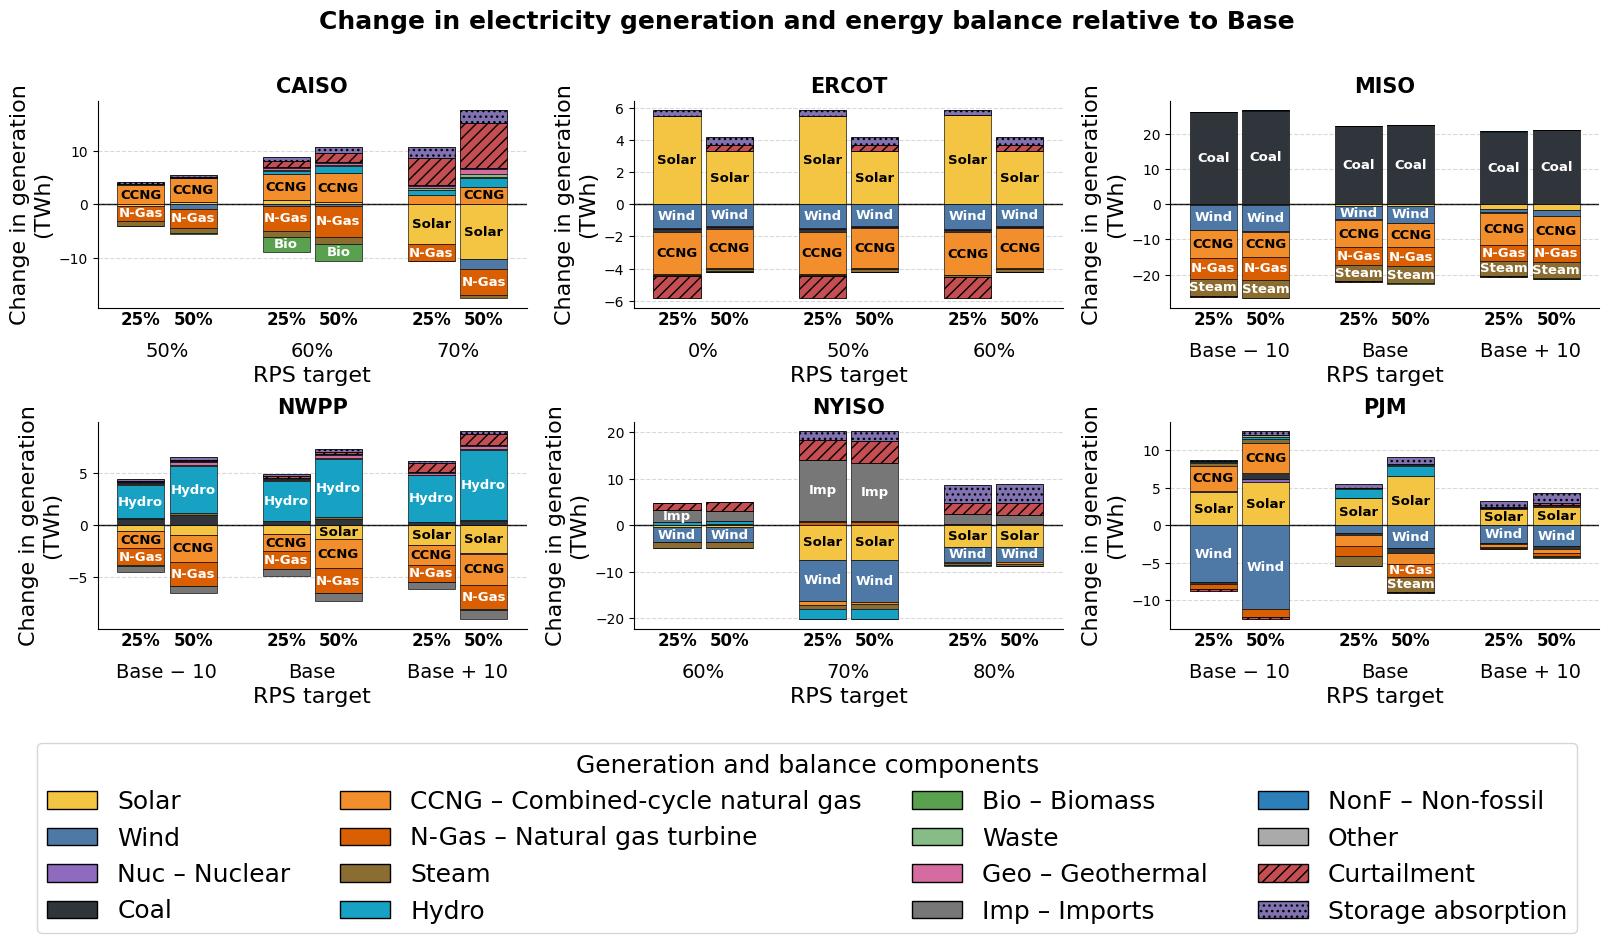

In [17]:
all_regions = (
    "CAISO",
    "ERCOT",
    # "FRCC",
    # "ISO-NE",
    # "MAPP",
    "MISO",
    "NWPP",
    "NYISO",
    "PJM",
    # "RMRG",
    # "SERC-E",
    # "SERC-N",
    # "SERC-SE",
    # "SPP",
    # "SRSG",
)

fig, axes = plot_generation_delta_stacked(
    generation_delta_table=generation_delta_table,
    generation_diagnostics=generation_diagnostics,
    regions=all_regions,
    participations=(
        "25%",
        "50%",
    ),
    rps_order_by_region=all_rps_by_region,
    panel_title_by_region={
        region: region
        for region in all_regions
    },
    selected_group="V2G",
    # Five rows × three columns for 15 regions.
    ncols=3,
    legend_ncol=4,
    bar_label_fontsize=9.5,
    legend_fontsize=18,
    bar_label_min_abs_twh_by_region={
        "CAISO": 2.0,
        "ERCOT": 0.8,
        "MISO": 3.0,
        "MAPP": 0.02,
    },
    save_path=(
        PROJECT_ROOT
        / "figures"
        / "generation_delta_all_regions_"
          "V2G_fast_bcapex315_balance_components.png"
    ),
)

plt.show()
plt.close(fig)

In [40]:

def plot_capacity_delta_stacked(
    capacity_delta_table,
    regions,
    participations=("25%", "50%"),
    rps_order_by_region=None,
    panel_title_by_region=None,
    selected_group="V2G",
    resource_colors=None,
    resource_order=("Solar", "Wind", "Battery"),
    resource_bar_labels=None,
    resource_legend_labels=None,
    bar_label_min_fraction_of_region_max=0.12,
    bar_label_min_abs_mw_by_region=None,
    bar_label_fontsize=12.5,
    ncols=3,
    figsize_per_panel=(5.5, 4.8),
    hspace=0.15,
    wspace=0.45,
    title="Change in installed capacity relative to Base",
    axis_label_fontsize=18,
    rps_tick_fontsize=18,
    participation_tick_fontsize=14,
    y_tick_fontsize=18,
    legend_ncol=3,
    legend_fontsize=18,
    legend_bottom=0.015,
    save_path=None,
):
    """
    Plot program-minus-Base capacity changes.

    Positive capacity changes are plotted above zero.
    Negative capacity changes are plotted below zero.
    Units are MW.
    """

    required_columns = {
        "region",
        "rps",
        "participation",
        "resource",
        "delta_capacity_mw",
    }

    missing = sorted(
        required_columns
        - set(capacity_delta_table.columns)
    )

    if missing:
        raise ValueError(
            f"Missing capacity columns: {missing}"
        )

    df = capacity_delta_table.copy()

    df["region"] = (
        df["region"]
        .astype(str)
        .str.strip()
    )

    df["participation"] = (
        df["participation"]
        .astype(str)
        .str.strip()
    )

    df["resource"] = (
        df["resource"]
        .astype(str)
        .str.strip()
    )

    df["rps"] = pd.to_numeric(
        df["rps"],
        errors="coerce",
    )

    df["delta_capacity_mw"] = pd.to_numeric(
        df["delta_capacity_mw"],
        errors="coerce",
    ).fillna(0.0)

    regions = tuple(regions)
    participations = tuple(
        str(value)
        for value in participations
    )

    if rps_order_by_region is None:
        rps_order_by_region = {
            region: sorted(
                df.loc[
                    df["region"] == region,
                    "rps",
                ]
                .dropna()
                .unique()
                .tolist()
            )
            for region in regions
        }

    if panel_title_by_region is None:
        panel_title_by_region = {
            region: region
            for region in regions
        }

    if resource_colors is None:
        resource_colors = {
            "Solar": "#F4C542",
            "Wind": "#4E79A7",
            "Battery": "#E15759",
        }

    missing_resources = [
        resource
        for resource in resource_order
        if resource not in resource_colors
    ]

    if missing_resources:
        raise ValueError(
            "Missing colors for resources: "
            f"{missing_resources}"
        )

    # Keep in-bar codes short so that they remain horizontal and readable.
    # The legend expands the abbreviated names.
    default_resource_bar_labels = {
        "Solar": "Solar",
        "Wind": "Wind",
        "Battery": "Batt",
    }
    resource_bar_labels = {
        **default_resource_bar_labels,
        **(resource_bar_labels or {}),
    }
    default_resource_legend_labels = {
        resource: (
            f"{resource_bar_labels[resource]} – {resource}"
            if resource_bar_labels.get(resource, resource) != resource
            else resource
        )
        for resource in default_resource_bar_labels
    }
    resource_legend_labels = {
        **default_resource_legend_labels,
        **(resource_legend_labels or {}),
    }

    if bar_label_min_fraction_of_region_max < 0:
        raise ValueError(
            "bar_label_min_fraction_of_region_max must be non-negative."
        )
    if bar_label_min_abs_mw_by_region is not None:
        invalid_thresholds = {
            region: value
            for region, value in bar_label_min_abs_mw_by_region.items()
            if float(value) < 0
        }
        if invalid_thresholds:
            raise ValueError(
                "bar_label_min_abs_mw_by_region cannot contain negative "
                f"values: {invalid_thresholds}"
            )

    from matplotlib.colors import to_rgb

    def contrast_text_color(fill_color):
        """Return black on light fills and white on dark fills."""
        red, green, blue = to_rgb(fill_color)
        luminance = 0.2126 * red + 0.7152 * green + 0.0722 * blue
        return "black" if luminance >= 0.55 else "white"

    ncols = max(1, int(ncols))
    nrows = math.ceil(
        len(regions) / ncols
    )

    fig, axes_grid = plt.subplots(
        nrows,
        ncols,
        figsize=(
            figsize_per_panel[0] * ncols,
            figsize_per_panel[1] * nrows,
        ),
        squeeze=False,
        facecolor="white",
    )

    axes = axes_grid.flatten()

    for panel_index, region in enumerate(regions):

        ax = axes[panel_index]

        region_df = df[
            (df["region"] == region)
            & df["participation"].isin(
                participations
            )
        ].copy()

        # Calculate the label threshold separately for every region. This
        # prevents a small region from using the same MW cutoff as a large one.
        capacity_stacks = (
            region_df.assign(
                positive_stack=region_df["delta_capacity_mw"].clip(lower=0),
                negative_stack=region_df["delta_capacity_mw"].clip(upper=0),
            )
            .groupby(["rps", "participation"], as_index=False)[
                ["positive_stack", "negative_stack"]
            ]
            .sum()
        )
        region_stack_scale = max(
            capacity_stacks["positive_stack"].max(),
            abs(capacity_stacks["negative_stack"].min()),
        ) if not capacity_stacks.empty else 0.0
        automatic_label_threshold = (
            float(bar_label_min_fraction_of_region_max)
            * float(region_stack_scale)
        )
        if bar_label_min_abs_mw_by_region is None:
            bar_label_threshold = automatic_label_threshold
        else:
            bar_label_threshold = float(
                bar_label_min_abs_mw_by_region.get(
                    region,
                    automatic_label_threshold,
                )
            )

        rps_values = list(
            rps_order_by_region[region]
        )

        centers = np.arange(
            len(rps_values),
            dtype=float,
        )

        number_participations = len(
            participations
        )

        width = min(
            0.36,
            0.78 / max(
                1,
                number_participations,
            ),
        )

        ax.axhline(
            0.0,
            color="black",
            linewidth=1.0,
            zorder=1,
        )

        for participation_index, participation in enumerate(
            participations
        ):

            offset = (
                participation_index
                - (number_participations - 1) / 2.0
            ) * width

            for rps_index, rps in enumerate(
                rps_values
            ):

                case = region_df[
                    (region_df["rps"] == rps)
                    & (
                        region_df["participation"]
                        == participation
                    )
                ]

                values_by_resource = (
                    case
                    .groupby("resource")[
                        "delta_capacity_mw"
                    ]
                    .sum()
                    .to_dict()
                )

                x = centers[rps_index] + offset

                positive_bottom = 0.0
                negative_bottom = 0.0

                for resource in resource_order:

                    value = float(
                        values_by_resource.get(
                            resource,
                            0.0,
                        )
                    )

                    if abs(value) < 1e-12:
                        continue

                    if value >= 0:
                        bottom = positive_bottom
                        positive_bottom += value
                    else:
                        bottom = negative_bottom
                        negative_bottom += value

                    fill_color = resource_colors[resource]

                    ax.bar(
                        x,
                        value,
                        width=width * 0.90,
                        bottom=bottom,
                        color=fill_color,
                        edgecolor="black",
                        linewidth=0.55,
                        zorder=3,
                    )

                    if abs(value) >= bar_label_threshold:
                        ax.text(
                            x,
                            bottom + value / 2.0,
                            resource_bar_labels.get(resource, resource),
                            ha="center",
                            va="center",
                            rotation=0,
                            fontsize=bar_label_fontsize,
                            fontweight="bold",
                            color=contrast_text_color(fill_color),
                            clip_on=True,
                            zorder=5,
                        )

                total_change = (
                    positive_bottom
                    + negative_bottom
                )

                # if abs(total_change) >= 1.0:
                #
                #     label_y = (
                #         positive_bottom + 100.0
                #         if total_change >= 0
                #         else negative_bottom - 100.0
                #     )
                #
                #     ax.annotate(
                #         f"{total_change:+.0f}",
                #         (x, label_y),
                #         ha="center",
                #         va=(
                #             "bottom"
                #             if total_change >= 0
                #             else "top"
                #         ),
                #         fontsize=8,
                #         fontweight="bold",
                #     )

        relative_regions = {
            "ISO-NE",
            "MAPP",
            "MISO",
            "NWPP",
            "PJM",
            "RMRG",
            "SERC-E",
            "SERC-N",
            "SERC-SE",
            "SPP",
            "SRSG",
        }

        if region in relative_regions:
            rps_labels = []

            for value in rps_values:
                if value == -10:
                    rps_labels.append("Base − 10")
                elif value == 0:
                    rps_labels.append("Base")
                elif value == 10:
                    rps_labels.append("Base + 10")
                else:
                    rps_labels.append(str(value))
        else:
            rps_labels = [
                f"{value:g}%"
                for value in rps_values
            ]

        participation_positions = []
        participation_labels = []

        for rps_index in range(len(rps_values)):
            for participation_index, participation in enumerate(
                participations
            ):

                offset = (
                    participation_index
                    - (number_participations - 1) / 2.0
                ) * width

                participation_positions.append(
                    centers[rps_index] + offset
                )

                participation_labels.append(
                    participation
                )

        ax.set_title(
            panel_title_by_region.get(
                region,
                region,
            ),
            fontsize=15,
            fontweight="bold",
        )

        ax.set_xlabel(
            "RPS target",
            fontsize=axis_label_fontsize,
        )

        ax.set_ylabel(
            "Change in capacity (MW)",
            fontsize=axis_label_fontsize,
        )

        ax.set_xticks(centers)
        ax.set_xticklabels(
            rps_labels,
            fontsize=rps_tick_fontsize,
        )

        ax.set_xticks(
            participation_positions,
            minor=True,
        )

        ax.set_xticklabels(
            participation_labels,
            minor=True,
            fontsize=participation_tick_fontsize,
            fontweight="bold",
        )

        ax.tick_params(
            axis="x",
            which="major",
            pad=24,
            length=0,
        )

        ax.tick_params(
            axis="x",
            which="minor",
            pad=2,
            length=0,
        )

        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.30,
            zorder=0,
        )

        ax.tick_params(
            axis="y",
            labelsize=y_tick_fontsize,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for index in range(
        len(regions),
        len(axes),
    ):
        axes[index].axis("off")

    legend_handles = [
        Patch(
            facecolor=resource_colors[resource],
            edgecolor="black",
            label=resource_legend_labels.get(resource, resource),
        )
        for resource in resource_order
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, legend_bottom),
        ncol=int(legend_ncol),
        frameon=True,
        fontsize=legend_fontsize,
        title="Capacity resources",
        title_fontsize=legend_fontsize,
    )

    fig.suptitle(
        title,
        fontsize=18,
        fontweight="bold",
        y=0.995,
    )

    fig.subplots_adjust(
        left=0.07,
        right=0.98,
        top=0.90,
        bottom=0.20,
        wspace=wspace,
        hspace=hspace,
    )

    if save_path is not None:

        save_path = Path(save_path)
        save_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )

        print(
            f"Saved capacity figure to: "
            f"{save_path}"
        )

    return fig, axes

Saved capacity figure to: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL/figures/capacity_delta_all_regions_V2G_fast_bcapex315.png


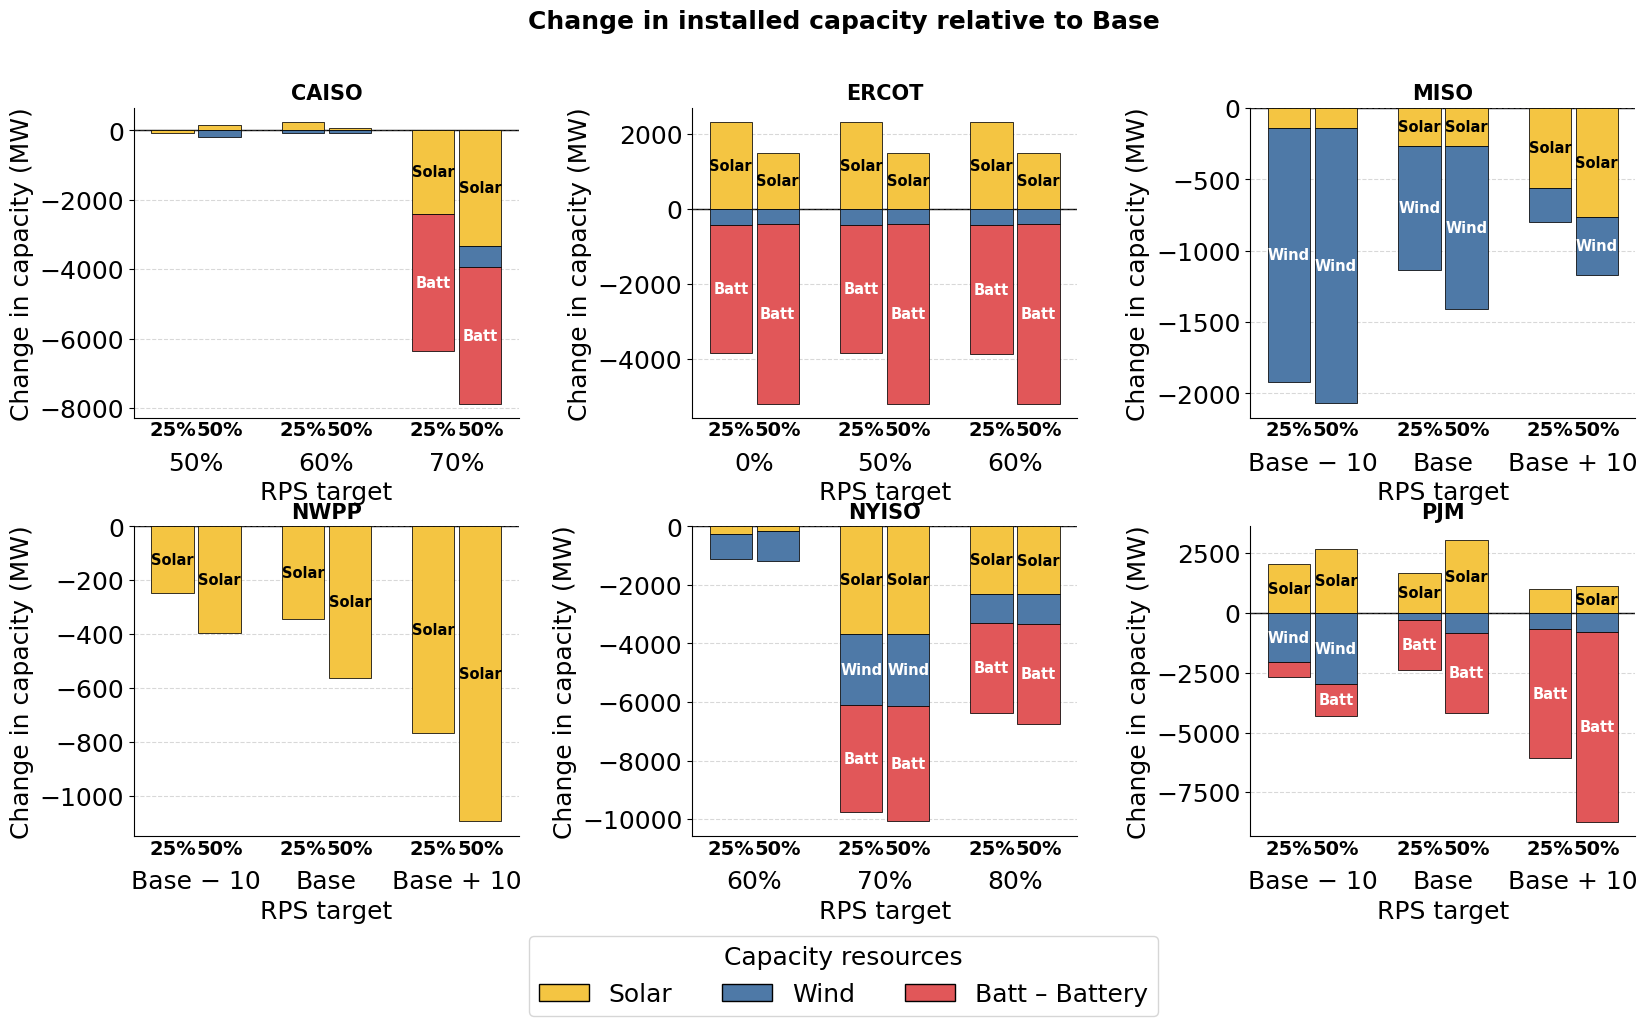

In [43]:

def build_capacity_delta_table_from_capex_summaries(
    selected_cases,
    max_workers=6,
):
    """
    Build Solar/Wind/Battery capacity changes from
    *_capex_summary.csv files.

    Capacity change is based directly on capex_added_MW.
    """

    required = {
        "region",
        "rps",
        "group",
        "participation",
        "solution_csv_path",
    }

    missing = sorted(
        required - set(selected_cases.columns)
    )

    if missing:
        raise ValueError(
            f"selected_cases is missing columns: {missing}"
        )

    import re
    from pathlib import Path
    import pandas as pd


    def read_one_case(row):
        solution_path = Path(
            row.solution_csv_path
        )

        solution_folder = solution_path.parent
        results_folder = solution_folder.parent

        # Extract scenario ID, for example s01.
        match = re.match(
            r"(s\d+)",
            solution_folder.name,
            flags=re.IGNORECASE,
        )

        if match is None:
            raise ValueError(
                f"Could not identify scenario ID from: "
                f"{solution_folder.name}"
            )

        scenario_id = match.group(1)

        # Capex files are stored in a sibling directory such as:
        #
        # s01_s01_fast_m0_d360/
        #     s01_s01_capex_detail.csv
        #
        capex_directories = sorted(
            results_folder.glob(
                f"{scenario_id}_*/"
            )
        )

        capex_files = []

        for directory in capex_directories:
            capex_files.extend(
                directory.glob(
                    "*_capex_detail.csv"
                )
            )

        if not capex_files:
            raise FileNotFoundError(
                f"No capex_detail.csv found for "
                f"{scenario_id} in:\n"
                f"{results_folder}\n\n"
                f"Solution folder:\n"
                f"{solution_folder}"
            )

        # Prefer the file whose name begins with the same scenario ID.
        matching_files = [
            path
            for path in capex_files
            if path.name.lower().startswith(
                scenario_id.lower()
            )
        ]

        capex_path = (
            matching_files[0]
            if matching_files
            else capex_files[0]
        )

        available_columns = pd.read_csv(
            capex_path,
            nrows=0,
        ).columns

        requested_columns = [
            column
            for column in (
                "fuel",
                "installed_MW",
                "capex_added_MW",
            )
            if column in available_columns
        ]

        required_columns = {
            "fuel",
            "capex_added_MW",
        }

        if not required_columns.issubset(
            requested_columns
        ):
            raise ValueError(
                f"Required columns are missing from:\n"
                f"{capex_path}\n"
                f"Available columns: "
                f"{list(available_columns)}"
            )

        summary = pd.read_csv(
            capex_path,
            usecols=requested_columns,
        )

        summary["fuel"] = (
            summary["fuel"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        summary["capex_added_MW"] = pd.to_numeric(
            summary["capex_added_MW"],
            errors="coerce",
        ).fillna(0.0)

        summary["resource"] = summary["fuel"].map({
            "solar": "Solar",
            "wind": "Wind",
            "battery": "Battery",
        })

        summary = summary[
            summary["resource"].notna()
        ].copy()

        summary = (
            summary
            .groupby(
                "resource",
                as_index=False,
            )["capex_added_MW"]
            .sum()
        )

        summary["region"] = row.region
        summary["rps"] = int(row.rps)
        summary["participation"] = (
            row.participation
        )
        summary["case_type"] = (
            "baseline"
            if row.group == "Base only"
            else "program"
        )
        summary["charging_scenario"] = (
            row.charging_scenario
        )
        summary["capex_summary_path"] = str(
            capex_path
        )

        return summary

    rows = list(
        selected_cases.itertuples(
            index=False
        )
    )

    workers = min(
        int(max_workers),
        max(1, len(rows)),
    )

    print(
        f"Reading {len(rows)} capex-summary files "
        f"with {workers} workers..."
    )

    with ThreadPoolExecutor(
        max_workers=workers
    ) as executor:
        frames = list(
            executor.map(
                read_one_case,
                rows,
            )
        )

    raw = pd.concat(
        frames,
        ignore_index=True,
    )

    # Base-only capacity for each region and RPS.
    baseline = raw[
        raw["case_type"] == "baseline"
    ][
        [
            "region",
            "rps",
            "resource",
            "capex_added_MW",
        ]
    ].rename(
        columns={
            "capex_added_MW": (
                "base_capacity_mw"
            )
        }
    )

    # Program capacity for each participation level.
    program = raw[
        raw["case_type"] == "program"
    ][
        [
            "region",
            "rps",
            "participation",
            "resource",
            "capex_added_MW",
        ]
    ].rename(
        columns={
            "capex_added_MW": (
                "program_capacity_mw"
            )
        }
    )

    capacity_delta_table = program.merge(
        baseline,
        on=[
            "region",
            "rps",
            "resource",
        ],
        how="left",
    )

    capacity_delta_table[
        "base_capacity_mw"
    ] = capacity_delta_table[
        "base_capacity_mw"
    ].fillna(0.0)

    capacity_delta_table[
        "program_capacity_mw"
    ] = capacity_delta_table[
        "program_capacity_mw"
    ].fillna(0.0)

    capacity_delta_table[
        "delta_capacity_mw"
    ] = (
        capacity_delta_table[
            "program_capacity_mw"
        ]
        - capacity_delta_table[
            "base_capacity_mw"
        ]
    )

    print(
        f"Created capacity table with "
        f"{len(capacity_delta_table)} rows."
    )

    return capacity_delta_table.sort_values(
        [
            "region",
            "rps",
            "participation",
            "resource",
        ]
    ).reset_index(drop=True)

capacity_delta_table = (
    build_capacity_delta_table_from_capex_summaries(
        selected_cases=selected_cases,
        max_workers=14,
    )
)

fig, axes = plot_capacity_delta_stacked(
    capacity_delta_table=capacity_delta_table,
    regions=all_regions,
    participations=(
        "25%",
        "50%",
    ),
    rps_order_by_region=all_rps_by_region,
    panel_title_by_region={
        region: region
        for region in all_regions
    },
    bar_label_fontsize=10.5,
    selected_group="V2G",
    ncols=3,
    figsize_per_panel=(5.5, 5.2),
    hspace=0.35,
    wspace=0.45,
    save_path=(
        PROJECT_ROOT
        / "figures"
        / "capacity_delta_all_regions_"
          "V2G_fast_bcapex315.png"
    ),
)

plt.show()
plt.close(fig)

In [64]:
"""Professional one-row EV-adoption maps for the 2030 fleet scenarios."""

from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd


def build_ev_adoption_by_state_from_fleet_files(
    fleet_files_by_adoption,
    year=2030,
):
    """Build the existing EV_ADOPTION_BY_STATE dictionary from fleet CSVs.

    Each CSV must contain ``destination_id`` (two-letter state code) and
    ``n_vehicles``. For example, pass ``{"slow": path1, "mid": path2,
    "fast": path3}``.
    """
    required_adoptions = {"slow", "mid", "fast"}
    received_adoptions = {
        str(adoption).strip().lower()
        for adoption in fleet_files_by_adoption
    }
    missing_adoptions = required_adoptions - received_adoptions
    if missing_adoptions:
        raise ValueError(
            "fleet_files_by_adoption is missing: "
            f"{sorted(missing_adoptions)}"
        )

    adoption_by_state = {}
    for adoption, file_path in fleet_files_by_adoption.items():
        adoption = str(adoption).strip().lower()
        fleet_df = pd.read_csv(file_path)
        required_columns = {"destination_id", "n_vehicles"}
        missing_columns = required_columns - set(fleet_df.columns)
        if missing_columns:
            raise ValueError(
                f"{file_path} is missing columns: {sorted(missing_columns)}"
            )

        fleet_df = fleet_df[["destination_id", "n_vehicles"]].copy()
        fleet_df["destination_id"] = (
            fleet_df["destination_id"].astype(str).str.strip().str.upper()
        )
        fleet_df["n_vehicles"] = pd.to_numeric(
            fleet_df["n_vehicles"], errors="coerce"
        ).fillna(0.0)

        for state, vehicles in fleet_df.groupby("destination_id")["n_vehicles"].sum().items():
            adoption_by_state.setdefault(state, {})[(int(year), adoption)] = int(vehicles)

    return adoption_by_state


def _find_shapefile(shp_folder):
    """Accept either a .shp file or the folder containing it."""
    shape_path = Path(shp_folder)
    if shape_path.is_file() and shape_path.suffix.lower() == ".shp":
        return shape_path
    available = sorted(shape_path.glob("*.shp"))
    if len(available) != 1:
        raise FileNotFoundError(
            "Provide a .shp file path or a folder containing exactly one .shp "
            f"file. Received: {shape_path}"
        )
    return available[0]


def _ev_adoption_to_dataframe(ev_adoption_by_state, year, adoptions):
    records = []
    for state, values in ev_adoption_by_state.items():
        for adoption in adoptions:
            vehicles = values.get((int(year), adoption))
            if vehicles is not None:
                records.append({
                    "STUSPS": str(state).strip().upper(),
                    "adoption": adoption,
                    "ev_adoption_million": float(vehicles) / 1_000_000,
                })
    return pd.DataFrame(records)


def plot_ev_adoption_maps(
    ev_adoption_by_state,
    shp_folder,
    year=2030,
    adoptions=("slow", "mid", "fast"),
    contiguous_only=True,
    cmap="YlOrRd",
    figsize=(18, 6.2),
    state_edgecolor="white",
    state_linewidth=0.35,
    missing_color="#E6E6E6",
    background_color="white",
    font_color="black",
    panel_title_fontsize=16,
    suptitle_fontsize=20,
    cbar_label_fontsize=14,
    cbar_tick_fontsize=12,
    save_path=None,
    show=True,
):
    """Draw a one-row map for the slow, mid, and fast adoption cases.

    The color scale is shared across all three panels so that colors are
    directly comparable. No state labels are added, keeping the figure clean.
    """
    adoptions = tuple(str(value).strip().lower() for value in adoptions)
    if len(adoptions) != 3:
        raise ValueError("adoptions must contain exactly: slow, mid, and fast.")
    if len(set(adoptions)) != len(adoptions):
        raise ValueError("adoptions contains duplicate values.")

    shape_path = _find_shapefile(shp_folder)
    states_gdf = gpd.read_file(shape_path)
    if "STUSPS" not in states_gdf.columns:
        raise ValueError("The state shapefile must contain an STUSPS column.")
    states_gdf["STUSPS"] = states_gdf["STUSPS"].astype(str).str.strip().str.upper()

    if contiguous_only:
        excluded_areas = {"AK", "HI", "PR", "AS", "GU", "MP", "VI"}
        states_gdf = states_gdf.loc[
            ~states_gdf["STUSPS"].isin(excluded_areas)
        ].copy()

    ev_df = _ev_adoption_to_dataframe(
        ev_adoption_by_state=ev_adoption_by_state,
        year=year,
        adoptions=adoptions,
    )
    if ev_df.empty:
        raise ValueError(f"No adoption values found for {year}.")

    vmax = float(ev_df["ev_adoption_million"].max())

    norm = Normalize(
        vmin=0.08 * vmax,
        vmax=vmax,
        clip=True,
    )
    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=figsize,
        facecolor=background_color,
    )
    axes = np.atleast_1d(axes)

    for ax, adoption in zip(axes, adoptions):
        ax.set_facecolor(background_color)
        panel_df = ev_df.loc[
            ev_df["adoption"] == adoption,
            ["STUSPS", "ev_adoption_million"],
        ]
        panel_gdf = states_gdf.merge(panel_df, on="STUSPS", how="left")
        panel_gdf.plot(
            column="ev_adoption_million",
            ax=ax,
            cmap=cmap,
            norm=norm,
            edgecolor=state_edgecolor,
            linewidth=state_linewidth,
            missing_kwds={
                "color": missing_color,
                "edgecolor": state_edgecolor,
                "linewidth": state_linewidth,
            },
        )
        ax.set_title(
            adoption.capitalize(),
            fontsize=panel_title_fontsize,
            fontweight="bold",
            color=font_color,
            pad=16,
        )
        ax.axis("off")

    colorbar = fig.colorbar(
        ScalarMappable(norm=norm, cmap=cmap),
        ax=axes.tolist(),
        orientation="horizontal",
        fraction=0.055,
        pad=0.065,
        aspect=45,
    )
    colorbar.set_label(
        "Registered PEVs (million vehicles)",
        fontsize=cbar_label_fontsize,
        fontweight="bold",
        color=font_color,
        labelpad=16,
    )
    colorbar.ax.tick_params(
        labelsize=cbar_tick_fontsize,
        colors=font_color,
    )

    fig.suptitle(
        f"EV Adoption Scenarios by State, {year}",
        fontsize=suptitle_fontsize,
        fontweight="bold",
        color=font_color,
        y=0.98,
    )
    fig.subplots_adjust(
        left=0.015,
        right=0.985,
        top=0.99,
        bottom=0.17,
        wspace=0.015,
    )

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            facecolor=background_color,
        )
        print(f"Saved EV adoption figure to: {save_path}")

    if show:
        plt.show()

    return fig, axes


Saved EV adoption figure to: /Volumes/Hanif P2/GOOD_MODEL_Backup/GOOD_MODEL/figures/ev_adoption_state_heatmap_2030.png


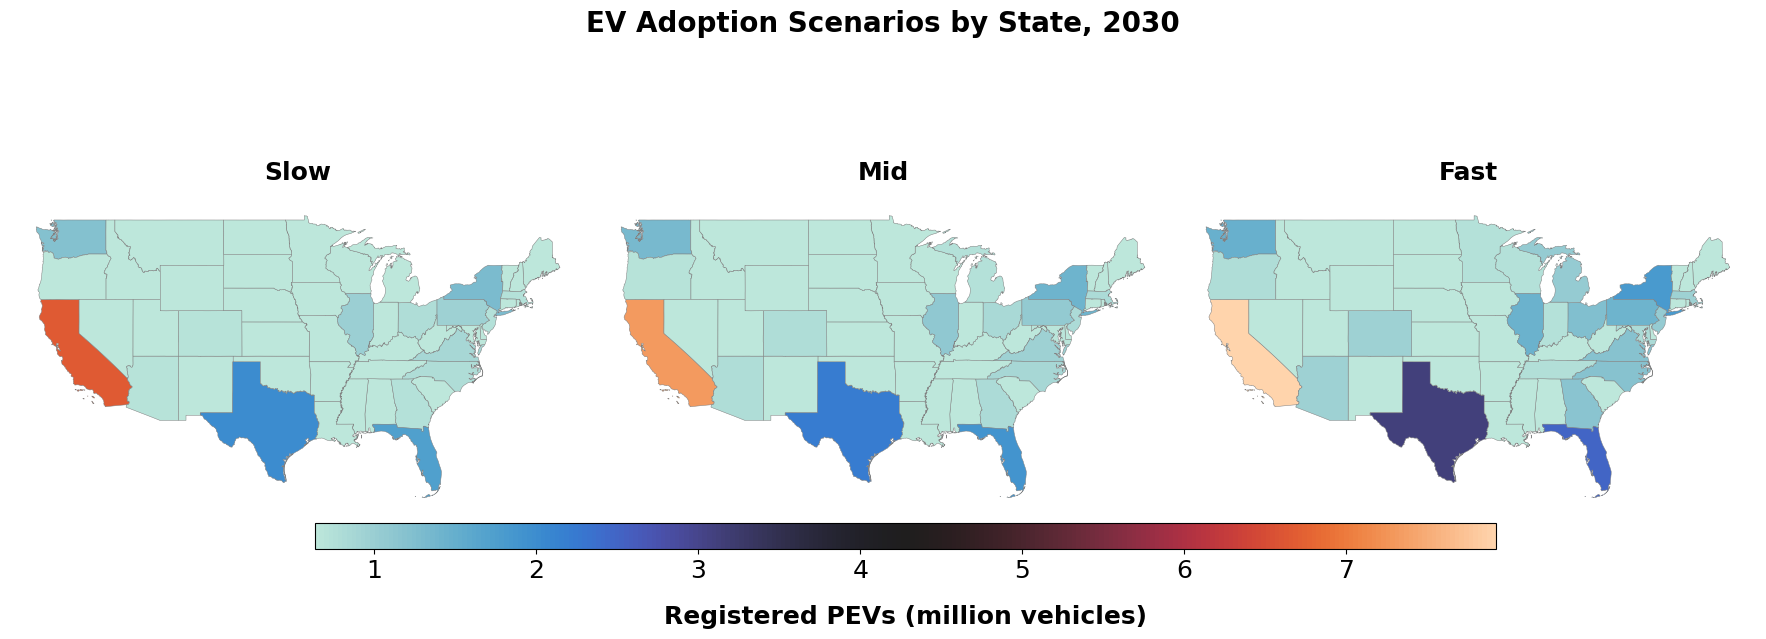

In [66]:
from pathlib import Path

FLEET_FILES_BY_ADOPTION = {
    "slow": (PROJECT_ROOT/ "Examples"/ "adoption"/ "fleet_2030_slow_selected_state_totals.csv"),
    "mid": (PROJECT_ROOT/ "Examples"/ "adoption"/ "fleet_2030_mid_selected_state_totals.csv"),
    "fast": (PROJECT_ROOT/ "Examples"/ "adoption"/ "fleet_2030_fast_selected_state_totals.csv"),
}

EV_ADOPTION_BY_STATE = build_ev_adoption_by_state_from_fleet_files(
    FLEET_FILES_BY_ADOPTION,
    year=2030,
)

fig, axes = plot_ev_adoption_maps(
    ev_adoption_by_state=EV_ADOPTION_BY_STATE,
    shp_folder=(
        PROJECT_ROOT
        / "plot_cache"
        / "shapefiles"
        / "cb_2018_us_state_5m.shp"
    ),
    state_linewidth=0.35,
    missing_color="#E6E6E6",
    background_color="white",
    font_color="black",
    panel_title_fontsize=18,
    suptitle_fontsize=20,
    cbar_label_fontsize=18,
    cbar_tick_fontsize=18,
    cmap="icefire",
    state_edgecolor="gray",
    year=2030,
    adoptions=("slow", "mid", "fast"),
    save_path=PROJECT_ROOT / "figures" / "ev_adoption_state_heatmap_2030.png",
)